**Keşifsel Veri Analizi (EDA)**
DUBLICATE YAPMADAN OLUŞTURULAN EDA
---



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Veri Kaynağı: /content/drive/MyDrive/Colab Notebooks/Brain_Cancer
💾 Kayıt Hedefi: /content/drive/MyDrive/Colab Notebooks/EDA_Kesfi (Veri setinden ayrı oluşturuldu)
✅ Tespit Edilen Sınıflar: ['brain_glioma', 'brain_menin', 'brain_tumor']
📊 Tablo kaydedildi: /content/drive/MyDrive/Colab Notebooks/EDA_Kesfi/sinif_dagilimi_tablosu.csv


/tmp/ipython-input-1872892792.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")


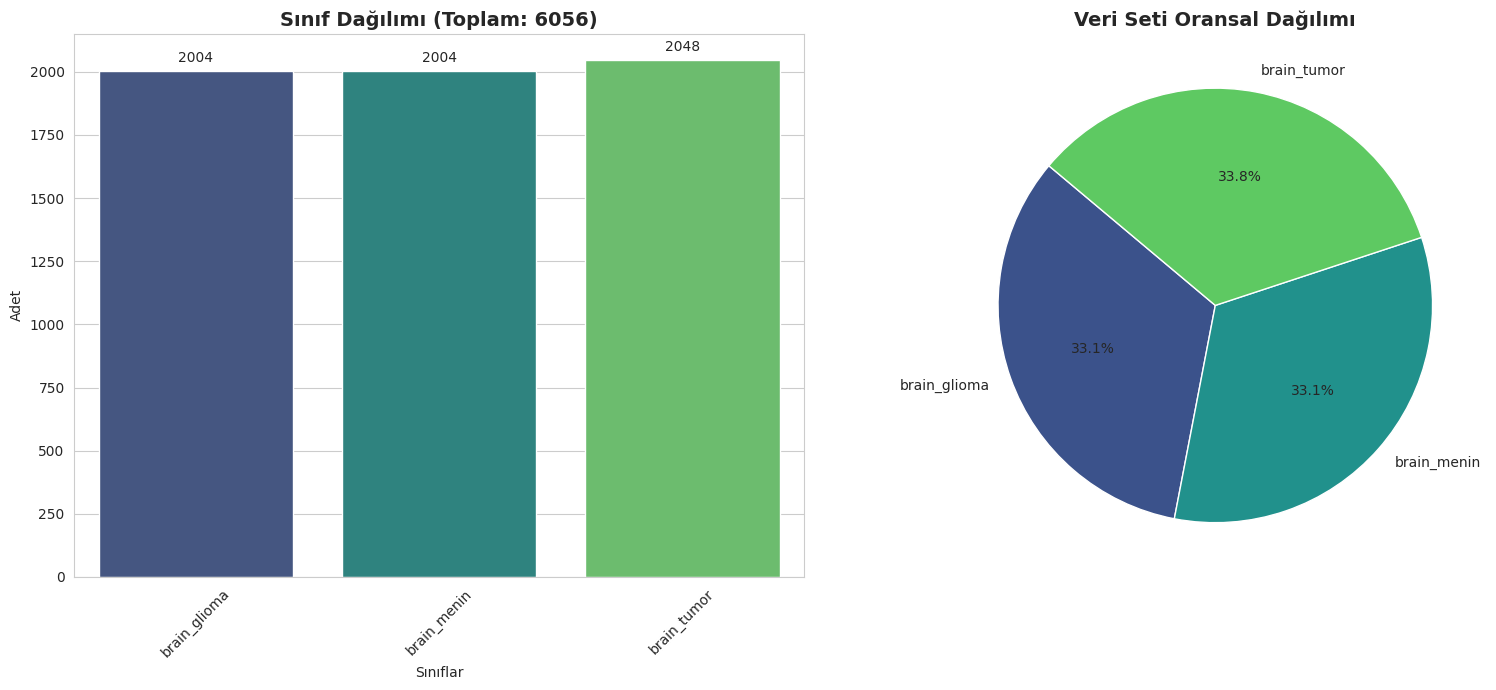


🖼️ Örnek görüntüler hazırlanıyor...


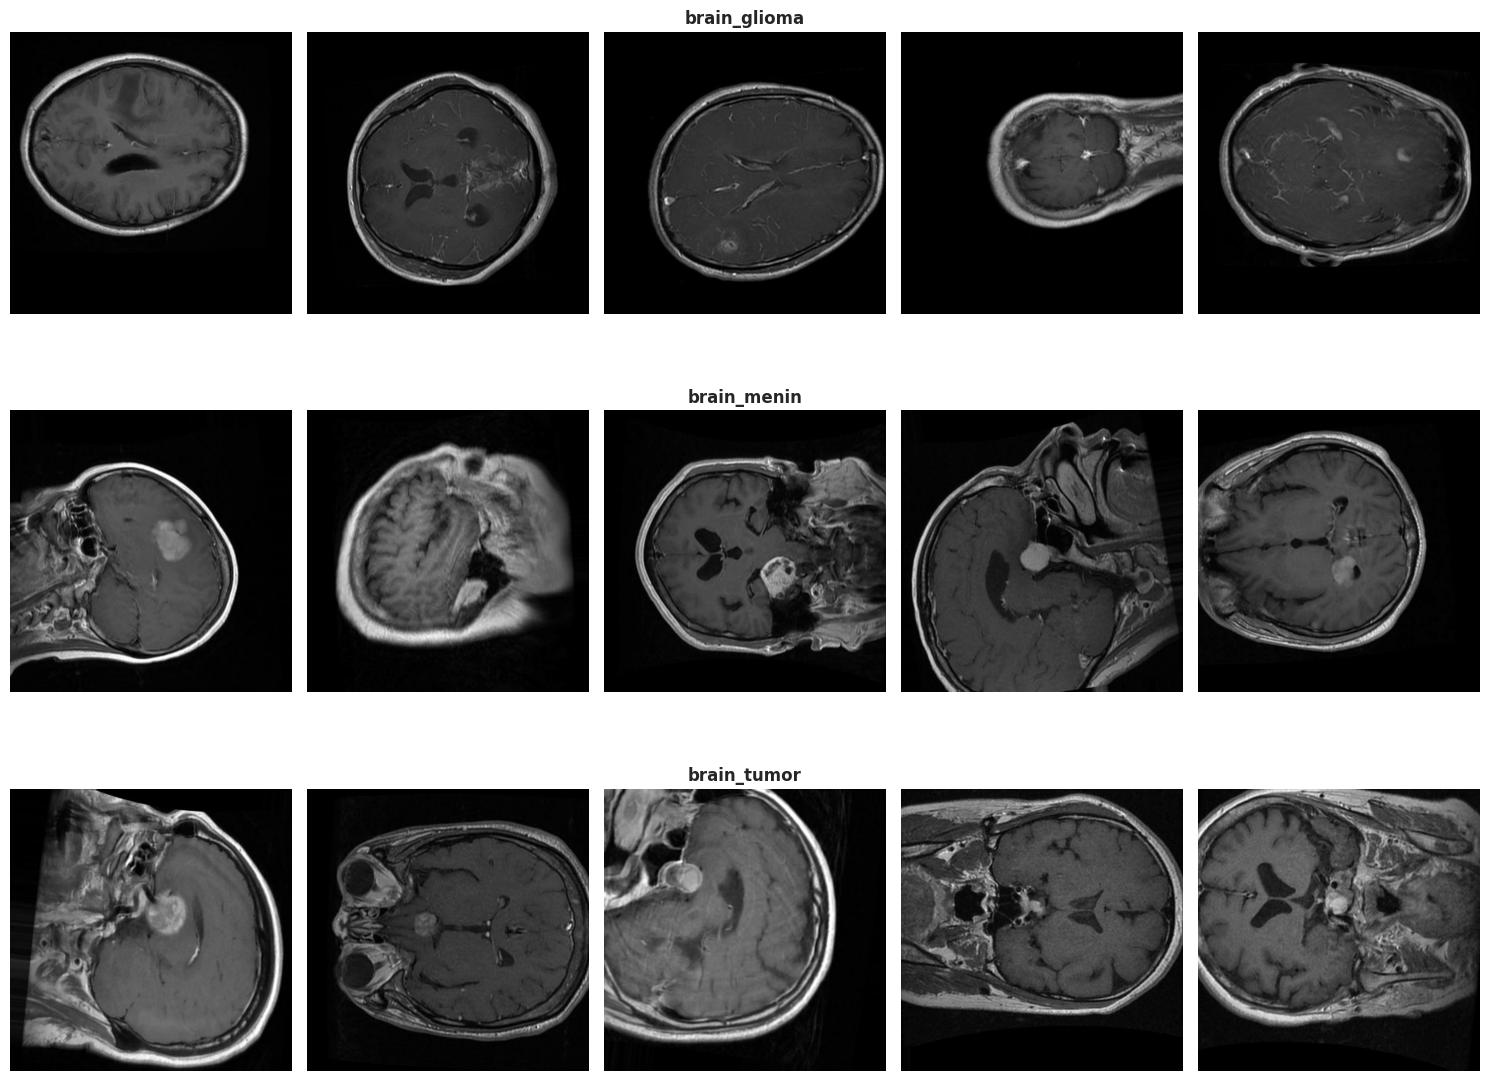


📏 Boyut ve Parlaklık Analizi yapılıyor...


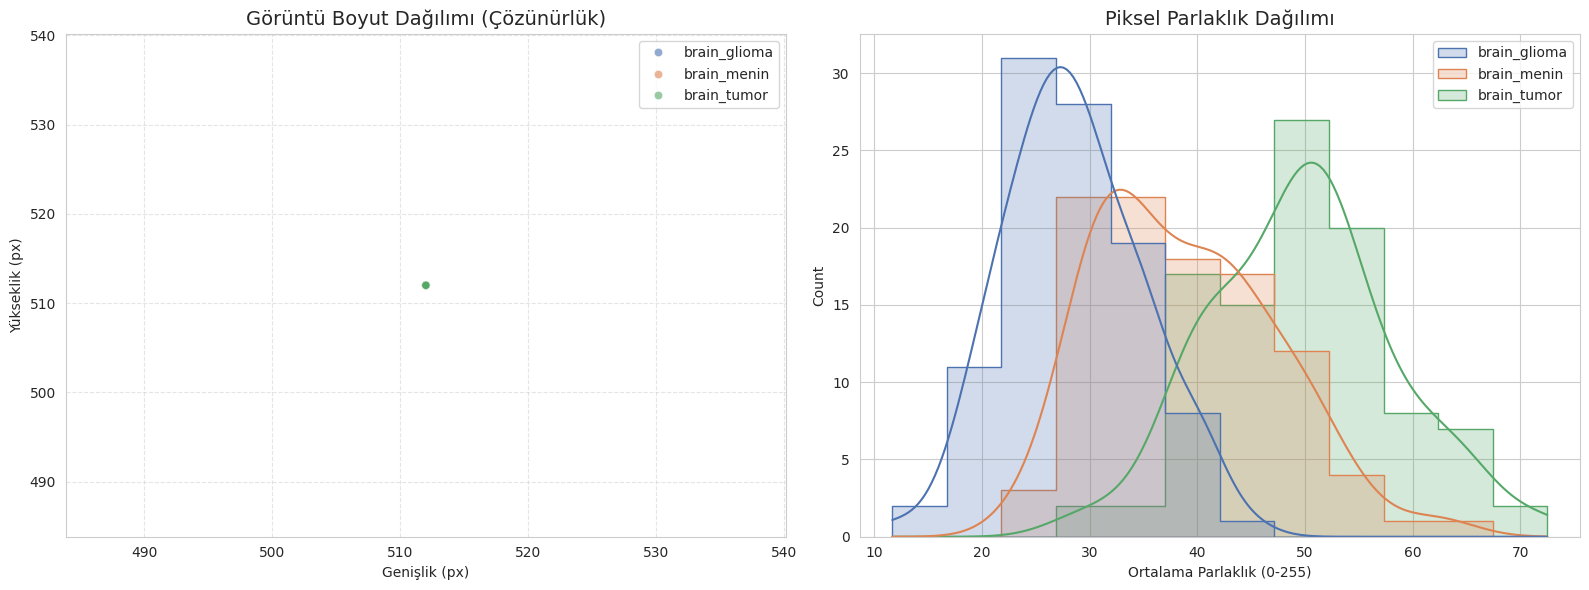


✅ TÜM İŞLEMLER BİTTİ.
📂 Dosyaları şurada bulabilirsin: /content/drive/MyDrive/Colab Notebooks/EDA_Kesfi


In [ ]:
# =========================================================
# 1. KURULUM VE KÜTÜPHANELER
# =========================================================
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import drive

# Google Drive Bağlantısı
drive.mount('/content/drive')

# Grafik Ayarları
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# =========================================================
# 2. AYARLAR VE KAYIT KLASÖRÜ
# =========================================================
# Veri seti ana yolu (Kaynak)
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/Brain_Cancer"

# Kayıt yapılacak YENİ AYRI klasör
# Brain_Cancer'ın içine değil, Colab Notebooks altında ayrı bir klasör olacak.
SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/EDA_Kesfi"

# Klasörü oluştur (Yoksa yaratır)
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"📂 Veri Kaynağı: {DATASET_PATH}")
print(f"💾 Kayıt Hedefi: {SAVE_DIR} (Veri setinden ayrı oluşturuldu)")

# Sınıfları oku (Klasör olmayanları ve gizli dosyaları atla)
# DenseNet kontrolü kaldırıldı.
all_items = os.listdir(DATASET_PATH)
class_names = sorted([
    d for d in all_items
    if os.path.isdir(os.path.join(DATASET_PATH, d))
    and not d.startswith('.')
])

print(f"✅ Tespit Edilen Sınıflar: {class_names}")

# =========================================================
# 3. VERİ DAĞILIMI ANALİZİ
# =========================================================
class_counts = {}
total_images = 0

for cls in class_names:
    cls_path = os.path.join(DATASET_PATH, cls)
    count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    class_counts[cls] = count
    total_images += count

# --- Sayısal Verileri CSV Olarak Kaydet ---
df_counts = pd.DataFrame(list(class_counts.items()), columns=['Sinif', 'Goruntu_Sayisi'])
df_counts['Oran_Yuzde'] = (df_counts['Goruntu_Sayisi'] / total_images) * 100
csv_path = os.path.join(SAVE_DIR, "sinif_dagilimi_tablosu.csv")
df_counts.to_csv(csv_path, index=False)
print(f"📊 Tablo kaydedildi: {csv_path}")

# --- Grafik 1: Sınıf Dağılımı ---
plt.figure(figsize=(16, 7))

# Sol: Çubuk Grafik
plt.subplot(1, 2, 1)
ax = sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")
plt.title(f"Sınıf Dağılımı (Toplam: {total_images})", fontsize=14, fontweight='bold')
plt.xlabel("Sınıflar"); plt.ylabel("Adet")
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

# Sağ: Pasta Grafik
plt.subplot(1, 2, 2)
plt.pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette("viridis", len(class_names)))
plt.title("Veri Seti Oransal Dağılımı", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "1_sinif_dagilimi_grafigi.png"), dpi=300, bbox_inches='tight')
plt.show()

# =========================================================
# 4. GÖRSEL KALİTE ANALİZİ
# =========================================================
print("\n🖼️ Örnek görüntüler hazırlanıyor...")

plt.figure(figsize=(15, 4 * len(class_names)))

for i, cls in enumerate(class_names):
    cls_folder = os.path.join(DATASET_PATH, cls)
    images = [img for img in os.listdir(cls_folder) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Her sınıftan max 5 tane, yoksa olan kadar al
    sample_count = min(len(images), 5)
    random_samples = random.sample(images, sample_count)

    for j, img_name in enumerate(random_samples):
        img_path = os.path.join(cls_folder, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(len(class_names), 5, i * 5 + j + 1)
            plt.imshow(img)
            plt.axis("off")
            if j == 2:
                plt.title(f"{cls}", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "2_ornek_goruntuler_grid.png"), dpi=300, bbox_inches='tight')
plt.show()

# =========================================================
# 5. YAPISAL ANALİZ (Boyut & Parlaklık)
# =========================================================
print("\n📏 Boyut ve Parlaklık Analizi yapılıyor...")

widths, heights, brightness_vals, labels_stats = [], [], [], []

for cls in class_names:
    cls_folder = os.path.join(DATASET_PATH, cls)
    images = [img for img in os.listdir(cls_folder) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    sample_size = min(len(images), 100) # Her sınıftan max 100 örnek al
    sampled_images = random.sample(images, sample_size)

    for img_name in sampled_images:
        img_path = os.path.join(cls_folder, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            h, w, _ = img.shape
            heights.append(h)
            widths.append(w)
            brightness_vals.append(np.mean(img))
            labels_stats.append(cls)

# --- Grafik 3: Boyut ve Parlaklık ---
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=widths, y=heights, hue=labels_stats, alpha=0.6, palette="deep")
plt.title("Görüntü Boyut Dağılımı (Çözünürlük)", fontsize=14)
plt.xlabel("Genişlik (px)"); plt.ylabel("Yükseklik (px)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.subplot(1, 2, 2)
sns.histplot(x=brightness_vals, hue=labels_stats, kde=True, element="step", palette="deep")
plt.title("Piksel Parlaklık Dağılımı", fontsize=14)
plt.xlabel("Ortalama Parlaklık (0-255)")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "3_yapisal_analiz_grafigi.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ TÜM İŞLEMLER BİTTİ.")
print(f"📂 Dosyaları şurada bulabilirsin: {SAVE_DIR}")

**DUPLİCATE KISMI**

In [ ]:
!pip install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 6.0 MB/s eta 0:00:00


In [ ]:
# ECG / IMAGE DATASET DUPLICATE ANALYSIS + SANITY CHECK
# ======================================================

# ---------- LIBRARIES ----------
import os
import shutil
import numpy as np
from PIL import Image
import imagehash
from skimage.metrics import structural_similarity as ssim

# ---------- FLAGS ----------
RUN_SANITY_CHECK = False   # True → SADECE RAPOR, KOPYALAMA YOK

# ---------- PATHS ----------
DATASET_DIR = "/content/drive/MyDrive/Projeypy/Brain_Cancer"
CLEAN_DIR   = "/content/drive/MyDrive/Projeypy/Brain_Cancer_Clean"
DUP_DIR     = "/content/drive/MyDrive/Projeypy/Brain_Cancer_Duplicate"

os.makedirs(CLEAN_DIR, exist_ok=True)
os.makedirs(DUP_DIR, exist_ok=True)

# ---------- SETTINGS ----------
SSIM_THRESHOLD = 0.98
IMG_SIZE = (256, 256)
VALID_EXT = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

hash_dict = {}   # hash(str) -> (class_name, img_path)
total_images = 0
duplicate_count = 0

print("\n========== DUPLICATE ANALYSIS STARTED ==========\n")

# ---------- MAIN LOOP ----------
for class_name in sorted(os.listdir(DATASET_DIR)):
    class_path = os.path.join(DATASET_DIR, class_name)
    if not os.path.isdir(class_path):
        continue

    clean_class_dir = os.path.join(CLEAN_DIR, class_name)
    dup_class_dir   = os.path.join(DUP_DIR, class_name)
    os.makedirs(clean_class_dir, exist_ok=True)
    os.makedirs(dup_class_dir, exist_ok=True)

    for img_name in sorted(os.listdir(class_path)):
        if not img_name.lower().endswith(VALID_EXT):
            continue

        img_path = os.path.join(class_path, img_name)
        total_images += 1

        try:
            with Image.open(img_path) as img:
                img = img.convert("L").resize(IMG_SIZE)
                img_hash = str(imagehash.phash(img))

            if img_hash not in hash_dict:
                hash_dict[img_hash] = (class_name, img_path)

                if not RUN_SANITY_CHECK:
                    shutil.copy2(img_path, os.path.join(clean_class_dir, img_name))

            else:
                old_class, old_path = hash_dict[img_hash]

                with Image.open(old_path) as old_img:
                    old_img = old_img.convert("L").resize(IMG_SIZE)

                sim = ssim(np.array(img), np.array(old_img))

                if sim >= SSIM_THRESHOLD:
                    duplicate_count += 1

                    print("DUPLICATE FOUND 🔁")
                    print(f"  → Class 1 : {old_class}")
                    print(f"  → Image 1 : {old_path}")
                    print(f"  → Class 2 : {class_name}")
                    print(f"  → Image 2 : {img_path}")
                    print(f"  → SSIM    : {sim:.4f}")
                    print("-" * 60)

                    if not RUN_SANITY_CHECK:
                        shutil.copy2(img_path, os.path.join(dup_class_dir, img_name))
                else:
                    # Aynı hash ama görsel farklı → temiz kabul
                    if not RUN_SANITY_CHECK:
                        shutil.copy2(img_path, os.path.join(clean_class_dir, img_name))

        except Exception as e:
            print(f"❌ ERROR: {img_path} -> {e}")

print("\n========== DUPLICATE ANALYSIS FINISHED ==========")
print(f"Toplam görüntü sayısı       : {total_images}")
print(f"Benzersiz hash sayısı       : {len(hash_dict)}")
print(f"Ayıklanan duplicate sayısı : {duplicate_count}")

# ======================================================
# FINAL SANITY CHECK
# ======================================================
print("\n========== FINAL SANITY CHECK ==========\n")

if os.path.exists(CLEAN_DIR):
    for class_name in sorted(os.listdir(CLEAN_DIR)):
        class_path = os.path.join(CLEAN_DIR, class_name)
        if os.path.isdir(class_path):
            print(f"{class_name:<20} : {len(os.listdir(class_path))} görüntü")

print("\nSanity check tamamlandı ✔")



========== DUPLICATE ANALYSIS STARTED ==========

DUPLICATE FOUND 🔁
  → Class 1 : brain_tumor
  → Image 1 : /content/drive/MyDrive/Projeypy/Brain_Cancer/brain_tumor/brain_tumor_0013 - Copy.jpg
  → Class 2 : brain_tumor
  → Image 2 : /content/drive/MyDrive/Projeypy/Brain_Cancer/brain_tumor/brain_tumor_0013.jpg
  → SSIM    : 1.0000
------------------------------------------------------------
DUPLICATE FOUND 🔁
  → Class 1 : brain_tumor
  → Image 1 : /content/drive/MyDrive/Projeypy/Brain_Cancer/brain_tumor/brain_tumor_0014 - Copy.jpg
  → Class 2 : brain_tumor
  → Image 2 : /content/drive/MyDrive/Projeypy/Brain_Cancer/brain_tumor/brain_tumor_0014.jpg
  → SSIM    : 1.0000
------------------------------------------------------------
DUPLICATE FOUND 🔁
  → Class 1 : brain_tumor
  → Image 1 : /content/drive/MyDrive/Projeypy/Brain_Cancer/brain_tumor/brain_tumor_0015 - Copy.jpg
  → Class 2 : brain_tumor
  → Image 2 : /content/drive/MyDrive/Projeypy/Brain_Cancer/brain_tumor/brain_tumor_0015.jpg
  

# DUPLICATE EDİLDİKTEN SONRAKİ EDA ANALİZİ

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Veri Kaynağı: /content/drive/MyDrive/Projeypy/Brain_Cancer_Clean
💾 Kayıt Hedefi: /content/drive/MyDrive/Projeypy/Sonuclar/EDA_Duplicate_Kesfi (Veri setinden ayrı oluşturuldu)
✅ Tespit Edilen Sınıflar: ['brain_glioma', 'brain_menin', 'brain_tumor']
📊 Tablo kaydedildi: /content/drive/MyDrive/Projeypy/Sonuclar/EDA_Duplicate_Kesfi/sinif_dagilimi_tablosu.csv


/tmp/ipython-input-2941543883.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")


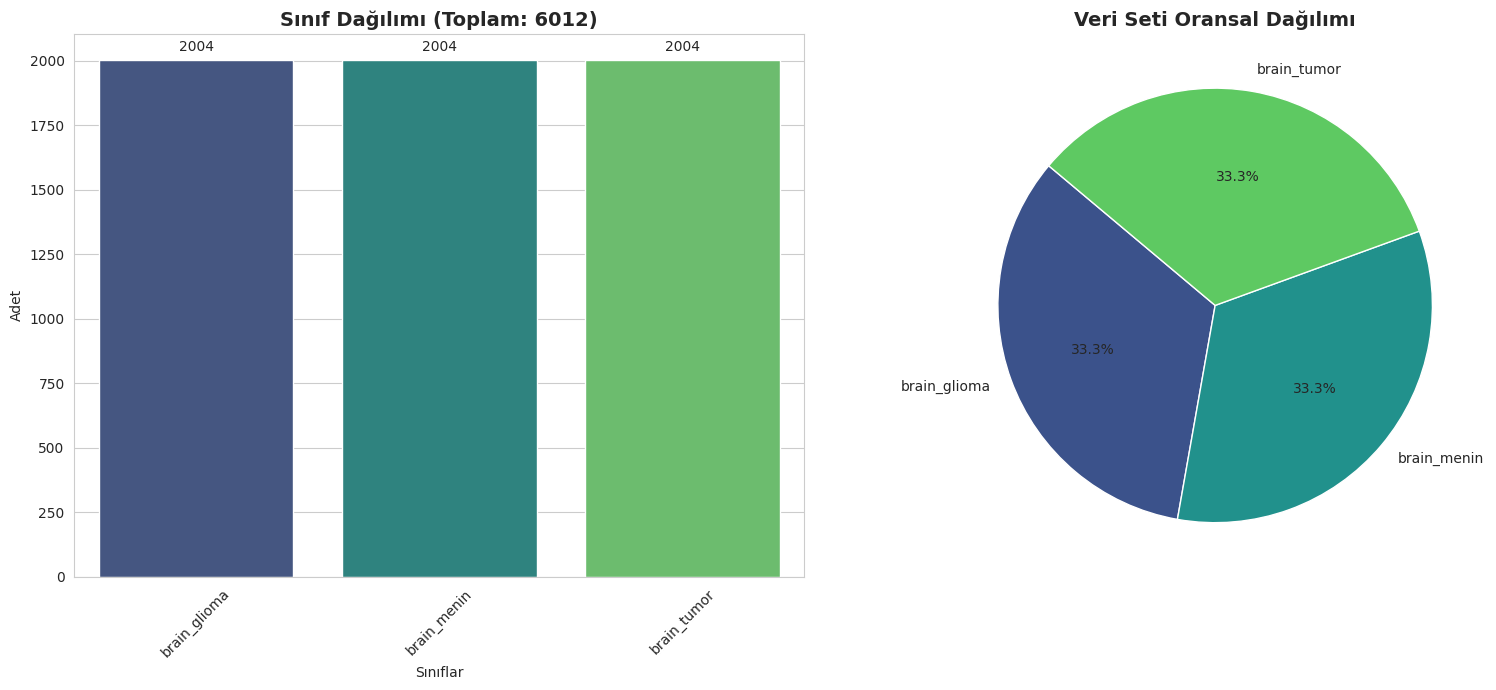


🖼️ Örnek görüntüler hazırlanıyor...


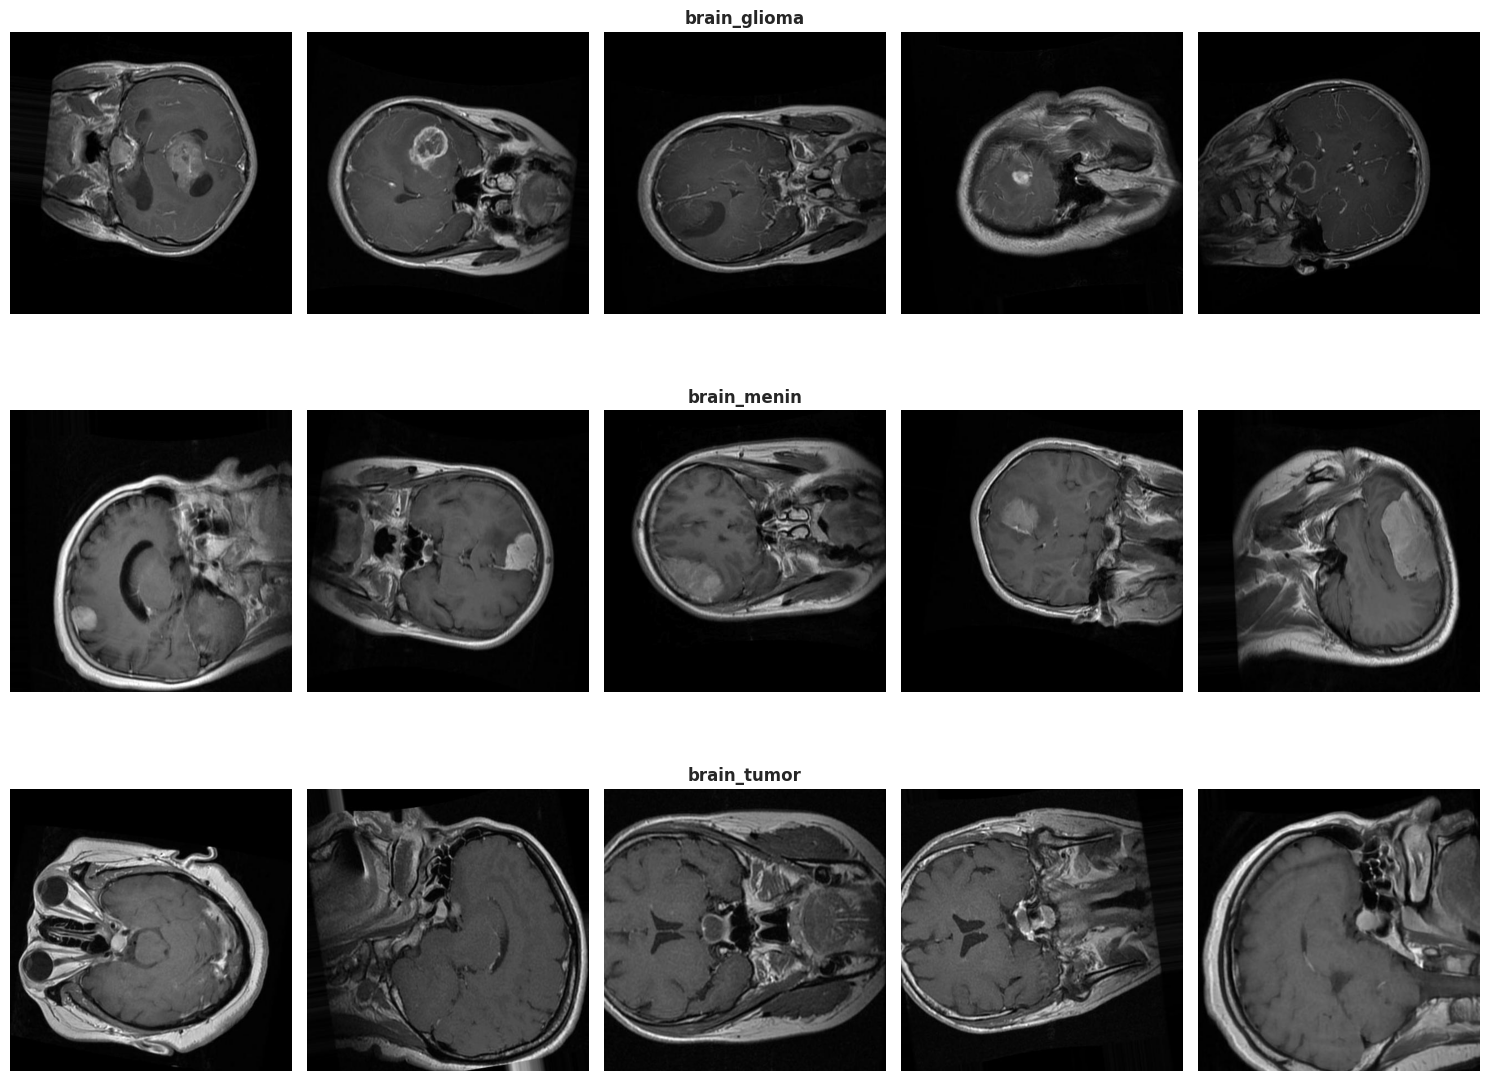


📏 Boyut ve Parlaklık Analizi yapılıyor...


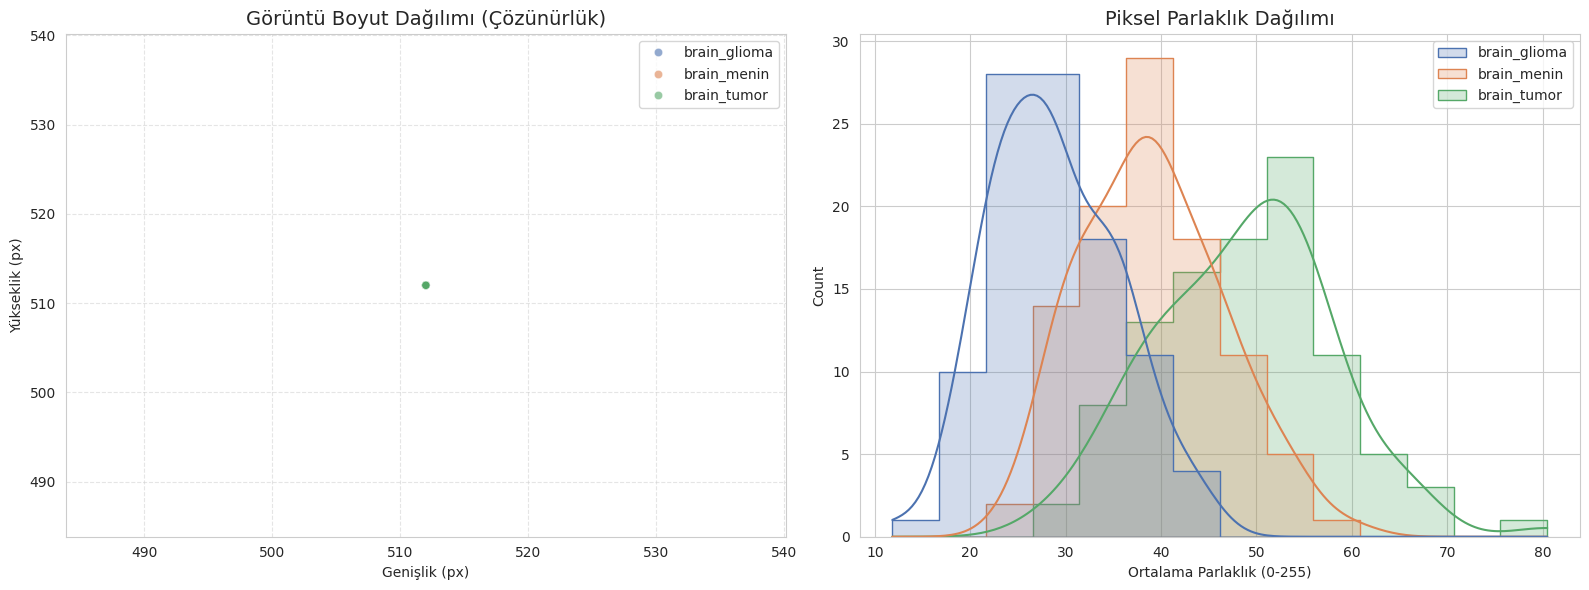


✅ TÜM İŞLEMLER BİTTİ.
📂 Dosyaları şurada bulabilirsin: /content/drive/MyDrive/Projeypy/Sonuclar/EDA_Duplicate_Kesfi


In [ ]:
# =========================================================
# 1. KURULUM VE KÜTÜPHANELER
# =========================================================
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import drive

# Google Drive Bağlantısı
drive.mount('/content/drive')

# Grafik Ayarları
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# =========================================================
# 2. AYARLAR VE KAYIT KLASÖRÜ
# =========================================================
# Veri seti ana yolu (Kaynak)
DATASET_PATH = "/content/drive/MyDrive/Projeypy/Brain_Cancer_Clean"
# Kayıt yapılacak YENİ AYRI klasör
# Brain_Cancer'ın içine değil, Colab Notebooks altında ayrı bir klasör olacak.
SAVE_DIR = "/content/drive/MyDrive/Projeypy/Sonuclar/EDA_Duplicate_Kesfi"

# Klasörü oluştur (Yoksa yaratır)
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"📂 Veri Kaynağı: {DATASET_PATH}")
print(f"💾 Kayıt Hedefi: {SAVE_DIR} (Veri setinden ayrı oluşturuldu)")

# Sınıfları oku (Klasör olmayanları ve gizli dosyaları atla)
# DenseNet kontrolü kaldırıldı.
all_items = os.listdir(DATASET_PATH)
class_names = sorted([
    d for d in all_items
    if os.path.isdir(os.path.join(DATASET_PATH, d))
    and not d.startswith('.')
])

print(f"✅ Tespit Edilen Sınıflar: {class_names}")

# =========================================================
# 3. VERİ DAĞILIMI ANALİZİ
# =========================================================
class_counts = {}
total_images = 0

for cls in class_names:
    cls_path = os.path.join(DATASET_PATH, cls)
    count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    class_counts[cls] = count
    total_images += count

# --- Sayısal Verileri CSV Olarak Kaydet ---
df_counts = pd.DataFrame(list(class_counts.items()), columns=['Sinif', 'Goruntu_Sayisi'])
df_counts['Oran_Yuzde'] = (df_counts['Goruntu_Sayisi'] / total_images) * 100
csv_path = os.path.join(SAVE_DIR, "sinif_dagilimi_tablosu.csv")
df_counts.to_csv(csv_path, index=False)
print(f"📊 Tablo kaydedildi: {csv_path}")

# --- Grafik 1: Sınıf Dağılımı ---
plt.figure(figsize=(16, 7))

# Sol: Çubuk Grafik
plt.subplot(1, 2, 1)
ax = sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")
plt.title(f"Sınıf Dağılımı (Toplam: {total_images})", fontsize=14, fontweight='bold')
plt.xlabel("Sınıflar"); plt.ylabel("Adet")
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

# Sağ: Pasta Grafik
plt.subplot(1, 2, 2)
plt.pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette("viridis", len(class_names)))
plt.title("Veri Seti Oransal Dağılımı", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "1_sinif_dagilimi_grafigi.png"), dpi=300, bbox_inches='tight')
plt.show()

# =========================================================
# 4. GÖRSEL KALİTE ANALİZİ
# =========================================================
print("\n🖼️ Örnek görüntüler hazırlanıyor...")

plt.figure(figsize=(15, 4 * len(class_names)))

for i, cls in enumerate(class_names):
    cls_folder = os.path.join(DATASET_PATH, cls)
    images = [img for img in os.listdir(cls_folder) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Her sınıftan max 5 tane, yoksa olan kadar al
    sample_count = min(len(images), 5)
    random_samples = random.sample(images, sample_count)

    for j, img_name in enumerate(random_samples):
        img_path = os.path.join(cls_folder, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(len(class_names), 5, i * 5 + j + 1)
            plt.imshow(img)
            plt.axis("off")
            if j == 2:
                plt.title(f"{cls}", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "2_ornek_goruntuler_grid.png"), dpi=300, bbox_inches='tight')
plt.show()

# =========================================================
# 5. YAPISAL ANALİZ (Boyut & Parlaklık)
# =========================================================
print("\n📏 Boyut ve Parlaklık Analizi yapılıyor...")

widths, heights, brightness_vals, labels_stats = [], [], [], []

for cls in class_names:
    cls_folder = os.path.join(DATASET_PATH, cls)
    images = [img for img in os.listdir(cls_folder) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    sample_size = min(len(images), 100) # Her sınıftan max 100 örnek al
    sampled_images = random.sample(images, sample_size)

    for img_name in sampled_images:
        img_path = os.path.join(cls_folder, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            h, w, _ = img.shape
            heights.append(h)
            widths.append(w)
            brightness_vals.append(np.mean(img))
            labels_stats.append(cls)

# --- Grafik 3: Boyut ve Parlaklık ---
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=widths, y=heights, hue=labels_stats, alpha=0.6, palette="deep")
plt.title("Görüntü Boyut Dağılımı (Çözünürlük)", fontsize=14)
plt.xlabel("Genişlik (px)"); plt.ylabel("Yükseklik (px)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.subplot(1, 2, 2)
sns.histplot(x=brightness_vals, hue=labels_stats, kde=True, element="step", palette="deep")
plt.title("Piksel Parlaklık Dağılımı", fontsize=14)
plt.xlabel("Ortalama Parlaklık (0-255)")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "3_yapisal_analiz_grafigi.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ TÜM İŞLEMLER BİTTİ.")
print(f"📂 Dosyaları şurada bulabilirsin: {SAVE_DIR}")

#**TEKLİ MODELLER**

**DENSENET121**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Veri Seti Okunuyor: /content/drive/MyDrive/Projeypy/Brain_Cancer_Clean
💾 Sonuçlar Kaydedilecek: /content/drive/MyDrive/Projeypy/Sonuclar/DenseNet121_Sonuclar (Veri setinden ayrı)
Sınıflar: ['brain_glioma', 'brain_menin', 'brain_tumor']
Toplam görüntü: 6012
Train+Val: 5410 | Test: 602

================ FOLD 1 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.3586 - loss: 1.7752 - val_accuracy: 0.5425 - val_loss: 1.3546 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.5942 - loss: 1.3376 - val_accuracy: 0.8438 - val_loss: 0.9994 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.7704 - loss: 1.0551 - val_accuracy: 0.8808 - val_loss: 0.8784 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.8525 - 

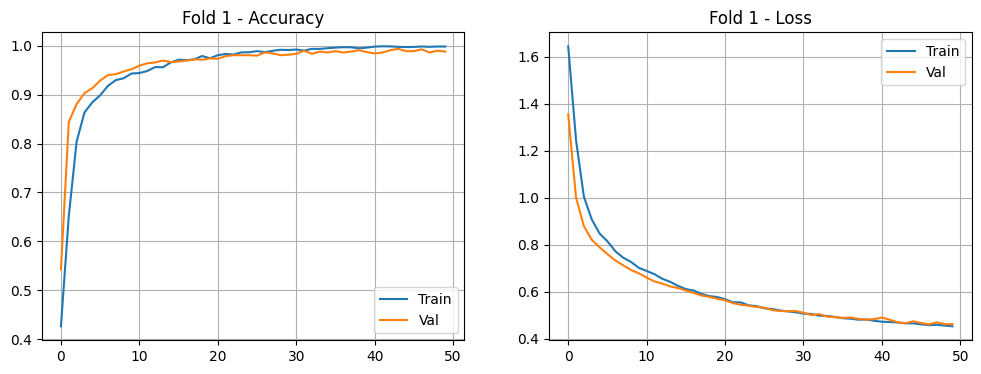

Fold 1 Val Acc: 0.9926 | Test Acc: 0.9917
*** YENİ EN İYİ FOLD BULUNDU: 1 (Acc: 0.9926) ***
Model kaydedildi: /content/drive/MyDrive/Projeypy/Sonuclar/DenseNet121_Sonuclar/best_densenet121_model.h5
Grafikler Drive'a kaydedildi.
Metrikler CSV olarak kaydedildi.

================ FOLD 2 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 93s 757ms/step - accuracy: 0.3965 - loss: 1.7630 - val_accuracy: 0.6571 - val_loss: 1.2656 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.6380 - loss: 1.2894 - val_accuracy: 0.8290 - val_loss: 0.9956 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.7844 - loss: 1.0252 - val_accuracy: 0.8900 - val_loss: 0.8682 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.8616 - loss: 0.9063 - val_accuracy: 0.9205 - val_loss: 0.7982 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.879

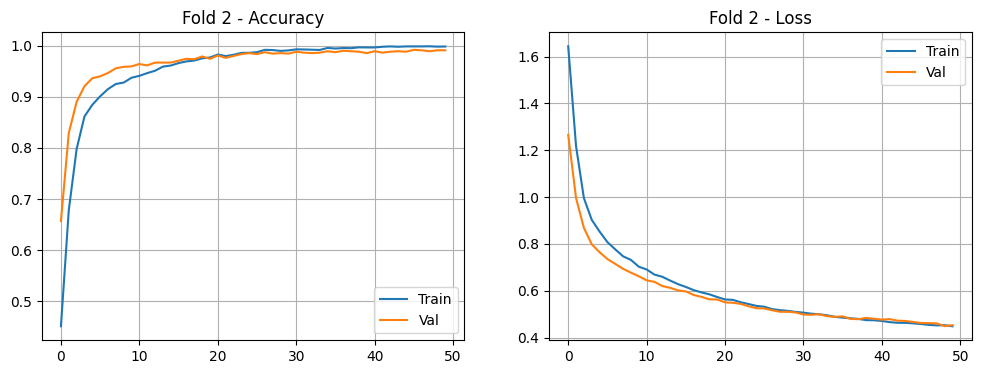

Fold 2 Val Acc: 0.9908 | Test Acc: 0.9884

================ FOLD 3 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 97s 792ms/step - accuracy: 0.3521 - loss: 1.8672 - val_accuracy: 0.6211 - val_loss: 1.3096 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.5785 - loss: 1.3896 - val_accuracy: 0.8530 - val_loss: 0.9920 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.7369 - loss: 1.1072 - val_accuracy: 0.8956 - val_loss: 0.8557 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.8101 - loss: 0.9788 - val_accuracy: 0.9113 - val_loss: 0.8064 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.8699 - loss: 0.8847 - val_accuracy: 0.9205 - val_loss: 0.7753 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.8927 - loss: 0.8376 - val_accuracy: 0.9335 - val_loss: 0.7443 - 

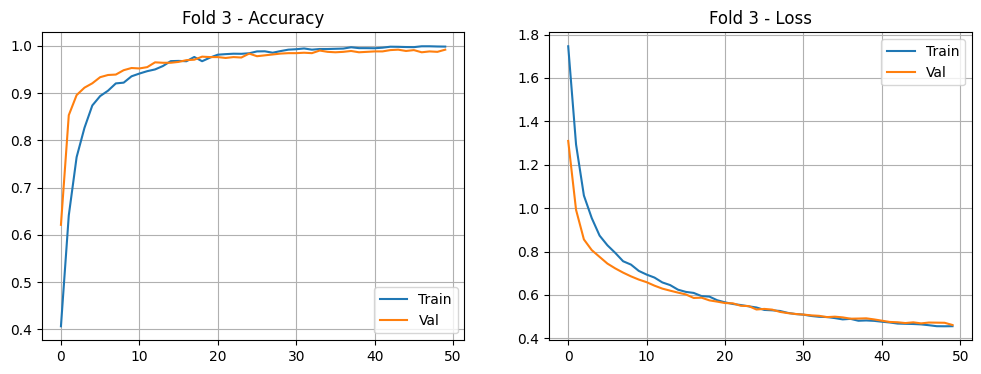

Fold 3 Val Acc: 0.9917 | Test Acc: 0.9884

================ FOLD 4 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 95s 752ms/step - accuracy: 0.3910 - loss: 1.7816 - val_accuracy: 0.6359 - val_loss: 1.2913 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.6113 - loss: 1.3262 - val_accuracy: 0.8244 - val_loss: 0.9968 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.7685 - loss: 1.0618 - val_accuracy: 0.8771 - val_loss: 0.8689 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.8418 - loss: 0.9370 - val_accuracy: 0.9011 - val_loss: 0.8158 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.8687 - loss: 0.8768 - val_accuracy: 0.9233 - val_loss: 0.7803 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9060 - loss: 0.8187 - val_accuracy: 0.9307 - val_loss: 0.7563 - le

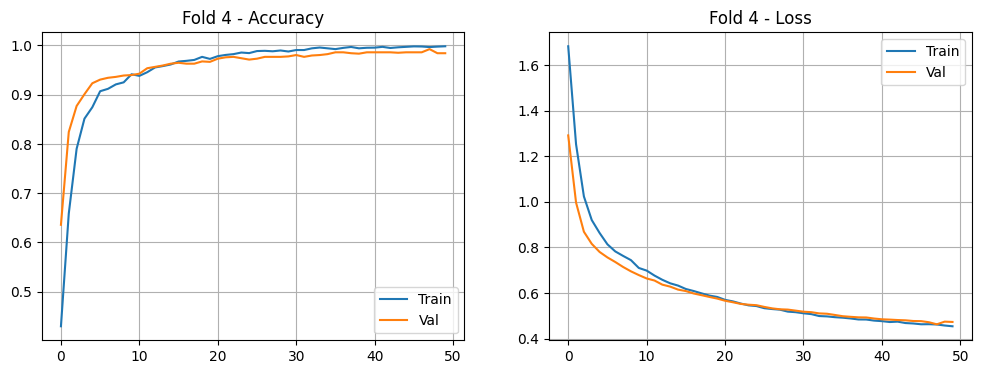

Fold 4 Val Acc: 0.9926 | Test Acc: 0.9850

================ FOLD 5 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 95s 790ms/step - accuracy: 0.3711 - loss: 1.7723 - val_accuracy: 0.5924 - val_loss: 1.3360 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.5912 - loss: 1.3383 - val_accuracy: 0.8327 - val_loss: 1.0077 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.7598 - loss: 1.0793 - val_accuracy: 0.8983 - val_loss: 0.8649 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.8420 - loss: 0.9296 - val_accuracy: 0.9196 - val_loss: 0.8026 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.8708 - loss: 0.8691 - val_accuracy: 0.9316 - val_loss: 0.7650 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.8944 - loss: 0.8236 - val_accuracy: 0.9362 - val_loss: 0.7365 - lea

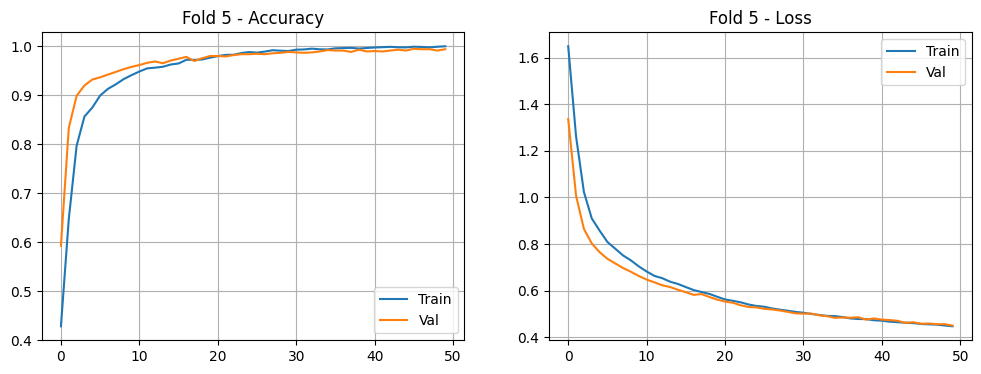

Fold 5 Val Acc: 0.9935 | Test Acc: 0.9884
*** YENİ EN İYİ FOLD BULUNDU: 5 (Acc: 0.9935) ***
Model kaydedildi: /content/drive/MyDrive/Projeypy/Sonuclar/DenseNet121_Sonuclar/best_densenet121_model.h5
Grafikler Drive'a kaydedildi.
Metrikler CSV olarak kaydedildi.

>>> EĞİTİM TAMAMLANDI. En iyi fold: 5. Dosyalar '/content/drive/MyDrive/Projeypy/Sonuclar/DenseNet121_Sonuclar' klasöründe.


In [ ]:
# =========================================================
# GOOGLE DRIVE BAĞLANTISI
# =========================================================
# Drive'ı bağlıyoruz çünkü veri setimiz orada ve sonuçları da oraya kaydedeceğiz.
from google.colab import drive
drive.mount('/content/drive')

# =========================================================
# GEREKLİ KÜTÜPHANELER
# =========================================================
# Veri işleme, görselleştirme, model mimarisi ve metrikler için gerekli tüm kütüphaneleri çağırıyoruz.
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn kütüphanesinden veri ayırma, çapraz doğrulama ve performans metriklerini alıyoruz.
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# Deep Learning işlemleri için Tensorflow ve Keras modülleri.
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121 # Transfer learning için kullanacağımız model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.keras import mixed_precision, regularizers

# =========================================================
# 🚀 MIXED PRECISION (A100 - GPU HIZLANDIRMA)
# =========================================================
# A100 GPU kullandığımız için mixed_float16 politikasını aktif ediyoruz.
# Bu sayede model eğitimi çok daha hızlı olacak ve bellek kullanımı düşecek.
mixed_precision.set_global_policy("mixed_float16")

# İşlem parçacığı ayarlarını sıfırlayarak sistemin varsayılan optimizasyonunu kullanmasını sağlıyoruz.
tf.config.threading.set_intra_op_parallelism_threads(0)
tf.config.threading.set_inter_op_parallelism_threads(0)

# =========================================================
# GENEL AYARLAR VE PATH TANIMLAMALARI
# =========================================================
# Temizlenmiş beyin kanseri veri setinin bulunduğu ana klasör yolu.
DATASET_PATH = "/content/drive/MyDrive/Projeypy/Brain_Cancer_Clean"

# Eğitim sonuçlarının (modeller, grafikler, csv) kaydedileceği klasör.
SAVE_DIR = "/content/drive/MyDrive/Projeypy/Sonuclar/DenseNet121_Sonuclar"
# Eğer bu klasör yoksa otomatik olarak oluşturuyoruz.
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"📂 Veri Seti Okunuyor: {DATASET_PATH}")
print(f"💾 Sonuçlar Kaydedilecek: {SAVE_DIR} (Veri setinden ayrı)")

# Görüntü boyutu (DenseNet için 224x224 standart), Batch size ve Epoch sayısı.
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 50
SEED = 42 # Sonuçların tekrar edilebilir olması için sabit bir seed değeri.

# Rastgelelik içeren her yere bu seed'i veriyoruz.
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# SINIFLARI VE DOSYALARI OKUMA
# =========================================================
# Klasör isimlerini alarak sınıf isimlerini belirliyoruz.
class_names = sorted(os.listdir(DATASET_PATH))

# Sadece geçerli resim klasörlerini listeye alıyoruz (Sonuç klasörü veya gizli dosyalar hariç).
class_names = [c for c in class_names
               if os.path.isdir(os.path.join(DATASET_PATH, c))
               and c != "DenseNet121_Sonuclar"
               and not c.startswith('.')]

NUM_CLASSES = len(class_names) # Toplam sınıf sayısı

# Tüm resimlerin dosya yollarını ve etiketlerini listelere topluyoruz.
image_paths, labels = [], []
for i, cls in enumerate(class_names):
    cls_path = os.path.join(DATASET_PATH, cls)
    if not os.path.exists(cls_path): continue
    for img in os.listdir(cls_path):
        # Sadece resim formatındaki dosyaları alıyoruz.
        if img.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(cls_path, img))
            labels.append(i) # Etiketi sayısal olarak (0, 1, 2...) ekliyoruz.

# İşlem kolaylığı için listeleri numpy array'e çeviriyoruz.
image_paths = np.array(image_paths)
labels = np.array(labels)

print("Sınıflar:", class_names)
print("Toplam görüntü:", len(image_paths))

# =========================================================
# VERİ SETİNİ BÖLME (TRAIN / TEST SPLIT)
# =========================================================
# Veriyi önce %90 Eğitim+Doğrulama ve %10 Test (Final Testi) olarak ayırıyoruz.
# stratify=labels diyerek her sınıftan eşit oranda dağılım sağlıyoruz.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    image_paths, labels,
    test_size=0.10,
    stratify=labels,
    random_state=SEED
)

print("Train+Val:", len(X_trainval), "| Test:", len(X_test))

# =========================================================
# GÖRÜNTÜ YÜKLEME VE İŞLEME FONKSİYONU
# =========================================================
def load_image(path, label):
    # Dosya yolundan resmi okuyoruz.
    img = tf.io.read_file(path)
    # Resmi decode edip 3 kanallı (RGB) hale getiriyoruz.
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    # Resmi modelin istediği boyuta (224x224) getiriyoruz.
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    # Piksel değerlerini 0-1 arasına normalize ediyoruz (float32 tipinde).
    img = tf.cast(img, tf.float32) / 255.0
    # Etiketi One-Hot Encoding formatına çeviriyoruz.
    return img, tf.one_hot(label, NUM_CLASSES)

# =========================================================
# VERİ ÇOĞALTMA (DATA AUGMENTATION)
# =========================================================
# Sadece eğitim sırasında kullanılacak veri çoğaltma işlemleri.
# Overfitting'i önlemek için resimlere rastgele bozulmalar uyguluyoruz.
@tf.function
def augment(img, y):
    img = tf.image.random_flip_left_right(img) # Yatay çevirme
    img = tf.image.random_flip_up_down(img)    # Dikey çevirme
    img = tf.image.random_brightness(img, 0.2) # Parlaklık değişimi
    img = tf.image.random_contrast(img, 0.8, 1.2)   # Kontrast değişimi
    img = tf.image.random_saturation(img, 0.8, 1.2) # Doygunluk değişimi
    # Biraz büyütüp rastgele kırpma (Zoom etkisi yaratır)
    big = tf.image.resize(img, (IMG_SIZE + 12, IMG_SIZE + 12))
    img = tf.image.random_crop(big, [IMG_SIZE, IMG_SIZE, 3])
    return img, y


# =========================================================
# WARMUP CALLBACK (ÖZEL LR AYARLAYICI)
# =========================================================
# Eğitimin başında Learning Rate'i yavaşça artırarak modelin
# ani ağırlık değişimleriyle sapıtmasını engelleyen sınıf.
class WarmUpLR(Callback):
    def __init__(self, base_lr=3e-5, warmup_epochs=3):
        super().__init__()
        self.base_lr = base_lr
        self.warmup_epochs = warmup_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            # İlk 3 epoch boyunca LR'yi lineer olarak artır.
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
            # Güvenli atama yöntemi ile optimizer'a yeni LR'yi veriyoruz.
            self.model.optimizer.learning_rate.assign(lr)

# Her epoch'un ne kadar sürdüğünü ölçen yardımcı sınıf.
class TimeHistory(Callback):
    def on_train_begin(self, logs={}):
        self.times = []
    def on_epoch_begin(self, batch, logs={}):
        self.epoch_time_start = time.time()
    def on_epoch_end(self, batch, logs={}):
        self.times.append(time.time() - self.epoch_time_start)

# =========================================================
# MODEL MİMARİSİ (DENSENET121)
# =========================================================
def build_model():
    # Transfer Learning: DenseNet121 modelini ImageNet ağırlıklarıyla indiriyoruz.
    # include_top=False diyerek son sınıflandırma katmanını almıyoruz.
    base = DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    # Modelin özellik çıkaran katmanlarının büyük kısmını donduruyoruz (Trainable=False).
    # Son 60 katmanı eğitime açık bırakıyoruz (Fine-tuning).
    for layer in base.layers[:-60]:
        layer.trainable = False

    # Kendi sınıflandırma katmanlarımızı ekliyoruz.
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation="relu",
              kernel_regularizer=regularizers.l2(1e-3))(x) # L2 Regularization ile aşırı öğrenmeyi engelle
    x = Dropout(0.5)(x) # Nöronların yarısını kapatarak ezberlemeyi önle
    # Çıkış katmanı: Sınıf sayısı kadar nöron ve Softmax aktivasyonu.
    out = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = Model(base.input, out)

    # Modeli derliyoruz. Label smoothing ile modelin kendine aşırı güvenmesini engelliyoruz.
    model.compile(
        optimizer=Adam(3e-5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08),
        metrics=["accuracy"]
    )
    return model

# =========================================================
# GRAFİK ÇİZME VE KAYDETME FONKSİYONU
# =========================================================
def save_plot_metrics(history, y_true, y_pred, y_prob, fold, save_path):
    # Bu fonksiyon sadece EN İYİ FOLD olduğunda çalışır ve sonuçları Drive'a kaydeder.

    # 1. Accuracy ve Loss Grafikleri
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Val")
    plt.title(f"Accuracy - Best Fold ({fold})")
    plt.legend(); plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Val")
    plt.title(f"Loss - Best Fold ({fold})")
    plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_loss_acc.png"))
    plt.close() # Ekrana basmadan kapatır, bellek şişmesin.

    # 2. Confusion Matrix (Karmaşıklık Matrisi)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names, cmap="Blues")
    plt.title(f"Confusion Matrix - Best Fold ({fold})")
    plt.savefig(os.path.join(save_path, "best_fold_confusion_matrix.png"))
    plt.close()

    # 3. ROC Eğrisi ve AUC Skorları
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    plt.figure(figsize=(7, 6))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title(f"ROC - Best Fold ({fold})")
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_roc_curve.png"))
    plt.close()

# =========================================================
# 5-FOLD CV DÖNGÜSÜ VE EĞİTİM
# =========================================================
# Veriyi 5 parçaya bölüyoruz (K-Fold). Her seferinde farklı bir parça doğrulama (val) için kullanılıyor.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

best_val_acc = 0.0  # En iyi fold'u takip etmek için başlangıç değeri
best_fold_index = 0

all_fold_results = []

# Döngü başlıyor: Her fold için eğitim yapılacak.
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    print(f"\n================ FOLD {fold} =================")

    # İndekslere göre train ve validation setlerini ayırıyoruz.
    X_tr, y_tr = X_trainval[tr_idx], y_trainval[tr_idx]
    X_val, y_val = X_trainval[val_idx], y_trainval[val_idx]

    # Sınıf dengesizliğini gidermek için ağırlık hesaplıyoruz (Az bulunan sınıfa daha çok odaklan).
    cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(zip(np.unique(y_tr), cw))

    # Eğitim verisi için Dataset pipeline'ı oluşturuyoruz (Shuffle + Augment + Batch).
    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
        .shuffle(4096)
        .map(load_image)
        .map(augment) # Veri çoğaltma burada uygulanır.
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE) # Hız için sonraki batch'i önden hazırla.
    )

    # Doğrulama verisi için pipeline (Augment YOK).
    val_ds = (
        tf.data.Dataset.from_tensor_slices((X_val, y_val))
        .map(load_image)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    # Modeli her fold için sıfırdan kuruyoruz.
    model = build_model()
    time_callback = TimeHistory()

    # Modeli eğitiyoruz.
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights,
        callbacks=[
            WarmUpLR(), # Learning rate ısındırma
            EarlyStopping(patience=8, restore_best_weights=True), # İyileşme durursa eğitimi kes
            ReduceLROnPlateau(patience=4, factor=0.3), # Plato çizilirse LR düşür
            time_callback # Süreyi tut
        ],
        verbose=1
    )

    # -------------------------------------------------------
    # EKRANDA GÖRMEK İÇİN GRAFİK (HER FOLD İÇİN)
    # -------------------------------------------------------
    # Bu kısım kaydedilmez, sadece eğitimi takip etmek için ekrana basılır.
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Val")
    plt.title(f"Fold {fold} - Accuracy")
    plt.legend(); plt.grid()
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Val")
    plt.title(f"Fold {fold} - Loss")
    plt.legend(); plt.grid()
    plt.show() # Ekrana bas
    # -------------------------------------------------------

    # Fold bittiğinde tahminleri alıyoruz.
    val_true, val_pred, val_prob = [], [], []
    for imgs, lbls in val_ds:
        p = model.predict(imgs, verbose=0)
        val_prob.extend(p)
        val_true.extend(np.argmax(lbls.numpy(), axis=1))
        val_pred.extend(np.argmax(p, axis=1))

    # Test seti için tahminler (Dikkat: test_ds döngü dışında tanımlanmalıydı ama kodun orijinali böyle).
    test_true, test_pred, test_prob = [], [], []
    for imgs, lbls in test_ds:
        p = model.predict(imgs, verbose=0)
        test_prob.extend(p)
        test_true.extend(np.argmax(lbls.numpy(), axis=1))
        test_pred.extend(np.argmax(p, axis=1))

    val_acc = accuracy_score(val_true, val_pred)
    test_acc = accuracy_score(test_true, test_pred)
    avg_epoch_time = np.mean(time_callback.times)

    # Detaylı metrikleri hesaplıyoruz (Precision, Recall, F1).
    precision, recall, f1, _ = precision_recall_fscore_support(test_true, test_pred, average='weighted')

    print(f"Fold {fold} Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")

    # EĞER BU FOLD ŞİMDİYE KADARKİ EN İYİSİ İSE KAYDETME İŞLEMLERİNİ YAP
    if val_acc > best_val_acc:
        print(f"*** YENİ EN İYİ FOLD BULUNDU: {fold} (Acc: {val_acc:.4f}) ***")
        best_val_acc = val_acc
        best_fold_index = fold

        # 1. Modeli Drive'a kaydet (.h5 formatında)
        model_save_path = os.path.join(SAVE_DIR, "best_densenet121_model.h5")
        model.save(model_save_path)
        print(f"Model kaydedildi: {model_save_path}")

        # 2. Grafikleri Drive'a kaydet (Yukarıdaki fonksiyonu çağırıyoruz)
        save_plot_metrics(history, test_true, test_pred, np.array(test_prob), fold, SAVE_DIR)
        print("Grafikler Drive'a kaydedildi.")

        # 3. Metrikleri CSV olarak kaydet
        best_fold_metrics = {
            "Model": "DenseNet121",
            "Best_Fold": fold,
            "Val_Accuracy": val_acc,
            "Test_Accuracy": test_acc,
            "Precision": precision,
            "Recall": recall,
            "F1_Score": f1,
            "Avg_Epoch_Time_Sec": avg_epoch_time
        }
        df = pd.DataFrame([best_fold_metrics])
        df.to_csv(os.path.join(SAVE_DIR, "best_model_metrics.csv"), index=False)
        print("Metrikler CSV olarak kaydedildi.")

print(f"\n>>> EĞİTİM TAMAMLANDI. En iyi fold: {best_fold_index}. Dosyalar '{SAVE_DIR}' klasöründe.")



**MobilNetV2**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Veri Seti Okunuyor: /content/drive/MyDrive/Projeypy/Brain_Cancer_Clean
💾 Sonuçlar Kaydedilecek: /content/drive/MyDrive/Projeypy/Sonuclar/MobileNetV2_Sonuclar (Veri setinden ayrı)
Sınıflar: ['brain_glioma', 'brain_menin', 'brain_tumor']
Toplam görüntü: 6012
Train+Val: 5410 | Test: 602

================ FOLD 1 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - accuracy: 0.4303 - loss: 1.2558 - val_accuracy: 0.5203 - val_loss: 1.0294 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.7556 - loss: 0.7382 - val_accuracy: 0.6738 - val_loss: 0.8427 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.8776 - loss: 0.5497 - val_accuracy: 0.7708 - val_loss: 0.7159 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9138 - l

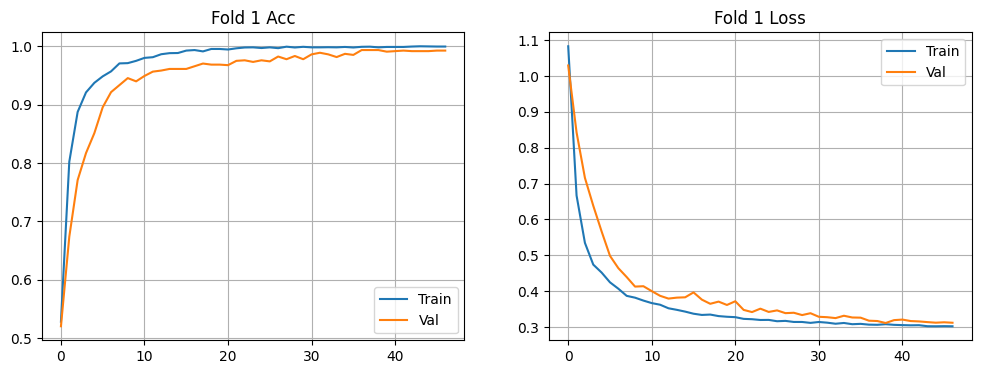

Fold 1 Val Acc: 0.9935 | Test Acc: 0.9900
*** YENİ EN İYİ FOLD: 1 (Acc: 0.9935) ***
Model ve Metrikler Kaydedildi.

================ FOLD 2 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 111s 977ms/step - accuracy: 0.4055 - loss: 1.3185 - val_accuracy: 0.5721 - val_loss: 0.9675 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.7480 - loss: 0.7572 - val_accuracy: 0.6969 - val_loss: 0.7796 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.8795 - loss: 0.5519 - val_accuracy: 0.7616 - val_loss: 0.7004 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.9065 - loss: 0.4949 - val_accuracy: 0.8290 - val_loss: 0.5967 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.9202 - loss: 0.4709 - val_accuracy: 0.8623 - val_loss: 0.5345 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accura

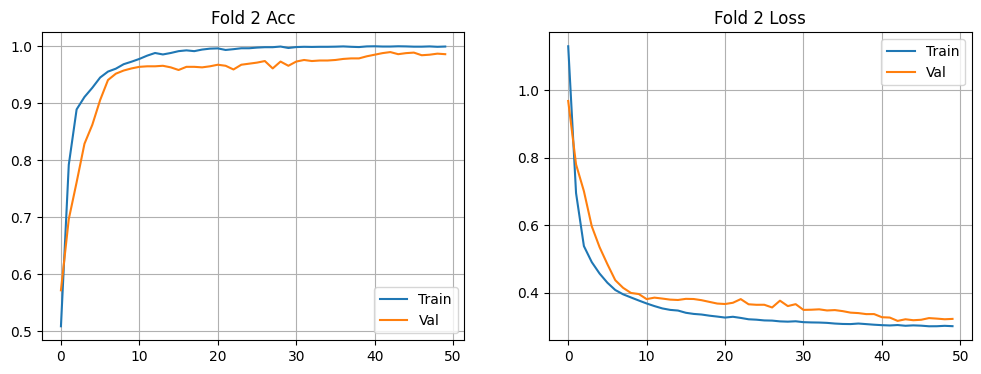

Fold 2 Val Acc: 0.9898 | Test Acc: 0.9834

================ FOLD 3 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 112s 974ms/step - accuracy: 0.4232 - loss: 1.2193 - val_accuracy: 0.6423 - val_loss: 0.8533 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.7521 - loss: 0.7263 - val_accuracy: 0.7181 - val_loss: 0.7928 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.8791 - loss: 0.5493 - val_accuracy: 0.7948 - val_loss: 0.6727 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.9220 - loss: 0.4776 - val_accuracy: 0.8632 - val_loss: 0.5550 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.9329 - loss: 0.4581 - val_accuracy: 0.8946 - val_loss: 0.4991 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.9520 - loss: 0.4224 - val_accuracy: 0.9205 - val_loss: 0.4614 - lea

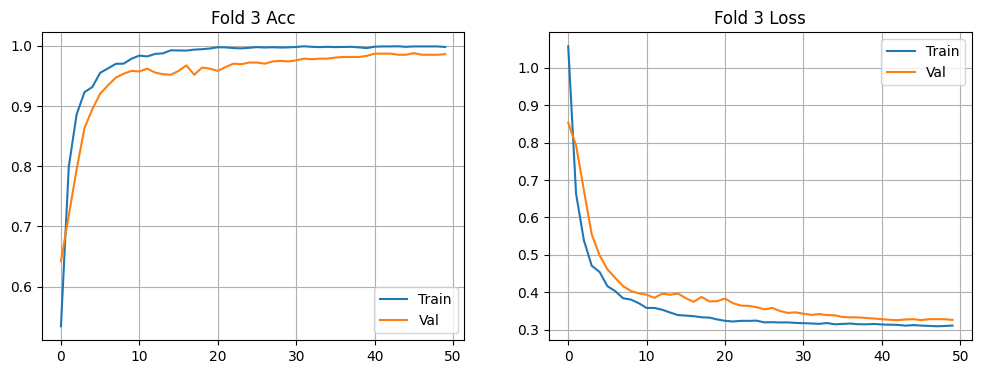

Fold 3 Val Acc: 0.9871 | Test Acc: 0.9834

================ FOLD 4 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 112s 994ms/step - accuracy: 0.4590 - loss: 1.2197 - val_accuracy: 0.5139 - val_loss: 1.0111 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.7457 - loss: 0.7617 - val_accuracy: 0.6525 - val_loss: 0.8829 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.8608 - loss: 0.5750 - val_accuracy: 0.7736 - val_loss: 0.6985 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.9092 - loss: 0.5027 - val_accuracy: 0.8189 - val_loss: 0.6429 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.9327 - loss: 0.4614 - val_accuracy: 0.8549 - val_loss: 0.5748 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.9483 - loss: 0.4321 - val_accuracy: 0.8835 - val_loss: 0.5245 - lea

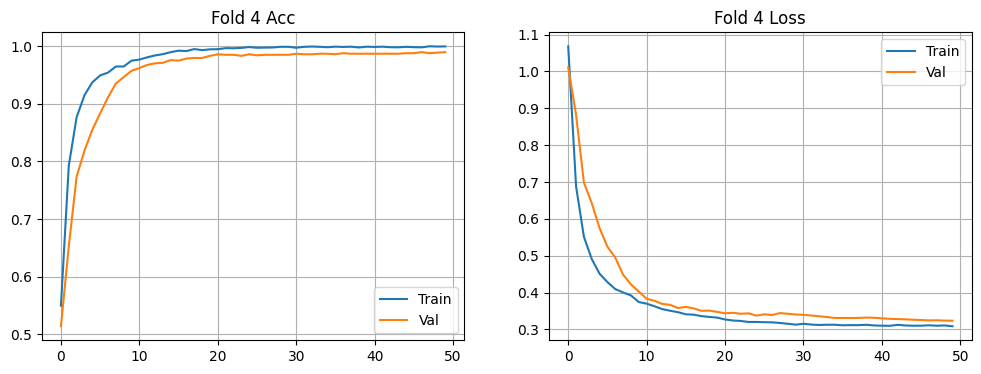

Fold 4 Val Acc: 0.9898 | Test Acc: 0.9801

================ FOLD 5 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 111s 968ms/step - accuracy: 0.4104 - loss: 1.2701 - val_accuracy: 0.5610 - val_loss: 0.9669 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.7468 - loss: 0.7354 - val_accuracy: 0.7006 - val_loss: 0.7997 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.8639 - loss: 0.5735 - val_accuracy: 0.7671 - val_loss: 0.7236 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.9107 - loss: 0.4975 - val_accuracy: 0.8752 - val_loss: 0.5742 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.9324 - loss: 0.4627 - val_accuracy: 0.9131 - val_loss: 0.4993 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.9491 - loss: 0.4282 - val_accuracy: 0.9270 - val_loss: 0.4630 - le

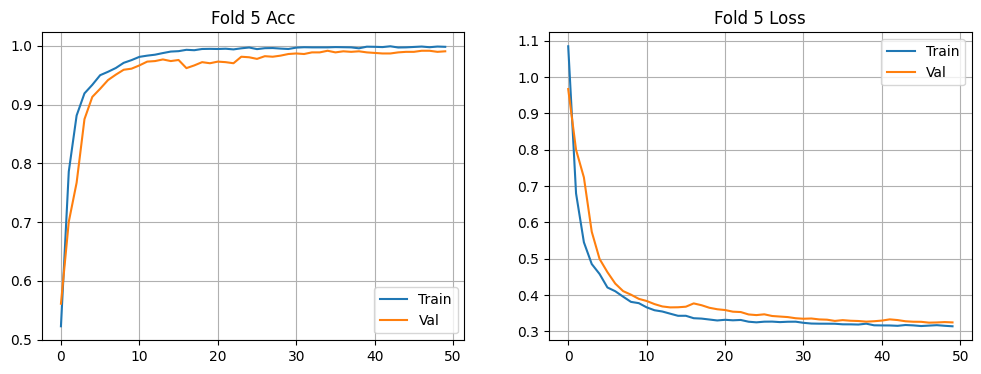

Fold 5 Val Acc: 0.9917 | Test Acc: 0.9801

>>> TAMAMLANDI. En iyi fold: 1


In [ ]:
# =========================================================
# GOOGLE DRIVE BAĞLANTISI
# =========================================================
# Veri setimiz Drive üzerinde olduğu için önce oraya erişim izni alıyoruz.
from google.colab import drive
drive.mount('/content/drive')

# =========================================================
# GEREKLİ KÜTÜPHANELER
# =========================================================
# Veri manipülasyonu, görselleştirme ve metrikler için standart kütüphaneler.
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn'den model değerlendirme ve veri bölme araçları.
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# Derin öğrenme (Deep Learning) için TensorFlow ve Keras modülleri.
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2 # Bu sefer MobileNetV2 modelini kullanıyoruz.
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.keras import mixed_precision, regularizers

# =========================================================
# 🚀 MIXED PRECISION (A100/T4 GPU HIZLANDIRMA)
# =========================================================
# GPU belleğini verimli kullanmak ve eğitimi hızlandırmak için float16 hassasiyetini açıyoruz.
mixed_precision.set_global_policy("mixed_float16")

# =========================================================
# AYARLAR VE PATH TANIMLARI
# =========================================================
# Temiz veri setimizin bulunduğu ana yol.
DATASET_PATH = "/content/drive/MyDrive/Projeypy/Brain_Cancer_Clean"

# DEĞİŞİKLİK 2: Sonuçların karışmaması için MobileNetV2'ye özel klasör oluşturuyoruz.
SAVE_DIR = "/content/drive/MyDrive/Projeypy/Sonuclar/MobileNetV2_Sonuclar"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"📂 Veri Seti Okunuyor: {DATASET_PATH}")
print(f"💾 Sonuçlar Kaydedilecek: {SAVE_DIR} (Veri setinden ayrı)")

# Görüntü boyutu (MobileNetV2 standart input: 224x224), Batch ve Epoch ayarları.
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 50
SEED = 42 # Tekrarlanabilirlik için sabit seed.

np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# SINIFLARI VE DOSYALARI OKUMA
# =========================================================
# Klasör isimlerinden sınıf adlarını çıkarıyoruz.
class_names = sorted(os.listdir(DATASET_PATH))
# Sadece geçerli klasörleri alıyoruz (Sonuç klasörü hariç).
class_names = [c for c in class_names
               if os.path.isdir(os.path.join(DATASET_PATH, c))
               and "Sonuclar" not in c
               and not c.startswith('.')]

NUM_CLASSES = len(class_names) # Sınıf sayısını belirliyoruz.

# Tüm resimlerin yollarını ve etiketlerini topluyoruz.
image_paths, labels = [], []
for i, cls in enumerate(class_names):
    cls_path = os.path.join(DATASET_PATH, cls)
    if not os.path.exists(cls_path): continue
    for img in os.listdir(cls_path):
        if img.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(cls_path, img))
            labels.append(i)

# Listeleri numpy array'e çeviriyoruz.
image_paths = np.array(image_paths)
labels = np.array(labels)

print("Sınıflar:", class_names)
print("Toplam görüntü:", len(image_paths))

# =========================================================
# VERİ SETİNİ BÖLME (TRAIN / TEST)
# =========================================================
# Veriyi %90 Eğitim+Doğrulama ve %10 Test olarak ayırıyoruz.
# 'stratify' ile her sınıftan eşit oranda örnek alınmasını sağlıyoruz.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    image_paths, labels,
    test_size=0.10,
    stratify=labels,
    random_state=SEED
)

print("Train+Val:", len(X_trainval), "| Test:", len(X_test))

# =========================================================
# IMAGE LOADER (MOBILENETV2 İÇİN ÖZEL PREPROCESSING)
# =========================================================
def load_image(path, label):
    # Görüntüyü diskten okuyup decode ediyoruz.
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    # ÖNEMLİ: MobileNetV2, piksel değerlerinin -1 ile 1 arasında olmasını bekler.
    # Normalde (0-255) arası olan değerleri önce (0-1)'e değil, direkt bu formülle normalize ediyoruz.
    # Formül: (x / 127.5) - 1.0
    img = tf.cast(img, tf.float32)
    img = (img / 127.5) - 1.0

    return img, tf.one_hot(label, NUM_CLASSES)

# =========================================================
# VERİ ÇOĞALTMA (DATA AUGMENTATION)
# =========================================================
# Eğitim setinde overfitting'i önlemek için rastgele değişiklikler yapıyoruz.
@tf.function
def augment(img, y):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    # Biraz büyütüp rastgele kırparak zoom etkisi veriyoruz.
    big = tf.image.resize(img, (IMG_SIZE + 12, IMG_SIZE + 12))
    img = tf.image.random_crop(big, [IMG_SIZE, IMG_SIZE, 3])
    return img, y

# =========================================================
# !!! TEST DATASET PİPELİNE (EKLENDİ ✅) !!!
# =========================================================
# Test verisi için pipeline oluşturuyoruz (Burada Augmentation YOK).
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(load_image)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# =========================================================
# CALLBACKS & MODEL MİMARİSİ
# =========================================================
# Eğitimin başında LR'yi yavaşça artıran WarmUp sınıfı.
class WarmUpLR(Callback):
    def __init__(self, base_lr=3e-5, warmup_epochs=3):
        super().__init__()
        self.base_lr = base_lr
        self.warmup_epochs = warmup_epochs
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
            self.model.optimizer.learning_rate.assign(lr)

# Eğitim süresini epoch başına ölçen sınıf.
class TimeHistory(Callback):
    def on_train_begin(self, logs={}): self.times = []
    def on_epoch_begin(self, batch, logs={}): self.epoch_time_start = time.time()
    def on_epoch_end(self, batch, logs={}): self.times.append(time.time() - self.epoch_time_start)

def build_model():
    # DEĞİŞİKLİK 3: Model MobileNetV2 olarak değiştirildi.
    # ImageNet ağırlıklarıyla yükleniyor, son katman hariç.
    base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

    # Fine Tuning: Modelin tamamını önce trainable yapıp, sonra ilk katmanları donduruyoruz.
    # Son 60 katman eğitime açık bırakılıyor.
    base.trainable = True
    for layer in base.layers[:-60]:
        layer.trainable = False

    # Kendi sınıflandırma katmanlarımız.
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = Dropout(0.5)(x) # Overfitting önleyici.
    out = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = Model(base.input, out)
    # Label smoothing, modelin kendine aşırı güvenmesini engeller (0.08).
    model.compile(optimizer=Adam(3e-5), loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08), metrics=["accuracy"])
    return model

# Grafikleri ve metrikleri kaydeden yardımcı fonksiyon.
def save_plot_metrics(history, y_true, y_pred, y_prob, fold, save_path):
    # Acc/Loss Grafikleri
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history["accuracy"], label="Train"); plt.plot(history.history["val_accuracy"], label="Val"); plt.title(f"Accuracy ({fold})"); plt.legend(); plt.grid()
    plt.subplot(1, 2, 2); plt.plot(history.history["loss"], label="Train"); plt.plot(history.history["val_loss"], label="Val"); plt.title(f"Loss ({fold})"); plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_loss_acc.png")); plt.close()

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6)); sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues"); plt.title(f"CM ({fold})"); plt.savefig(os.path.join(save_path, "best_fold_confusion_matrix.png")); plt.close()

    # ROC Eğrileri
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    plt.figure(figsize=(7, 6))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--"); plt.title(f"ROC ({fold})"); plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_roc_curve.png")); plt.close()

# =========================================================
# 5-FOLD CROSS VALIDATION (ÇAPRAZ DOĞRULAMA)
# =========================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
best_val_acc = 0.0
best_fold_index = 0

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    print(f"\n================ FOLD {fold} =================")
    # Eğitim ve Doğrulama verisini ayırıyoruz.
    X_tr, y_tr = X_trainval[tr_idx], y_trainval[tr_idx]
    X_val, y_val = X_trainval[val_idx], y_trainval[val_idx]

    # Sınıf ağırlıklarını hesapla (Dengesiz veri setleri için önemli).
    cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(zip(np.unique(y_tr), cw))

    # Datasetleri oluştur (Train için shuffle+augment, Val için sadece load).
    train_ds = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr)).shuffle(4096).map(load_image).map(augment).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
    val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val)).map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

    # Modeli oluştur ve eğit.
    model = build_model()
    time_callback = TimeHistory()

    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, class_weight=class_weights,
                        callbacks=[WarmUpLR(), EarlyStopping(patience=8, restore_best_weights=True), ReduceLROnPlateau(patience=4, factor=0.3), time_callback], verbose=1)

    # GRAFİKLERİ GÖSTER (Ekrana basmak için)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history["accuracy"], label="Train"); plt.plot(history.history["val_accuracy"], label="Val"); plt.title(f"Fold {fold} Acc"); plt.legend(); plt.grid()
    plt.subplot(1, 2, 2); plt.plot(history.history["loss"], label="Train"); plt.plot(history.history["val_loss"], label="Val"); plt.title(f"Fold {fold} Loss"); plt.legend(); plt.grid()
    plt.show()

    # METRİKLER (Hata vermemesi için düzeltilmiş tahmin alma yöntemi)
    val_prob = model.predict(val_ds, verbose=0)
    val_pred = np.argmax(val_prob, axis=1)
    val_true = np.concatenate([y for x, y in val_ds], axis=0) # Gerçek etiketleri datasetten çekiyoruz.
    val_true = np.argmax(val_true, axis=1)

    test_prob = model.predict(test_ds, verbose=0)
    test_pred = np.argmax(test_prob, axis=1)

    val_acc = accuracy_score(val_true, val_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print(f"Fold {fold} Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")

    # EĞER EN İYİ FOLD İSE KAYDET
    if val_acc > best_val_acc:
        print(f"*** YENİ EN İYİ FOLD: {fold} (Acc: {val_acc:.4f}) ***")
        best_val_acc = val_acc
        best_fold_index = fold

        # DEĞİŞİKLİK 4: Modeli MobileNetV2 adıyla kaydediyoruz.
        model.save(os.path.join(SAVE_DIR, "best_mobilenetv2_model.h5"))
        # Grafikleri Drive'a kaydet.
        save_plot_metrics(history, y_test, test_pred, test_prob, fold, SAVE_DIR)

        # CSV'ye detaylı metrikleri yaz.
        avg_epoch_time = np.mean(time_callback.times)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, test_pred, average='weighted')
        df = pd.DataFrame([{
            "Model": "MobileNetV2", "Best_Fold": fold, # DEĞİŞİKLİK 5: CSV'de model adı doğru olsun.
            "Val_Accuracy": val_acc, "Test_Accuracy": test_acc,
            "Precision": precision, "Recall": recall, "F1_Score": f1,
            "Avg_Epoch_Time_Sec": avg_epoch_time
        }])
        df.to_csv(os.path.join(SAVE_DIR, "best_model_metrics.csv"), index=False)
        print("Model ve Metrikler Kaydedildi.")

print(f"\n>>> TAMAMLANDI. En iyi fold: {best_fold_index}")

**InceptionV3**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Veri Seti Okunuyor: /content/drive/MyDrive/Projeypy/Brain_Cancer_Clean
💾 Sonuçlar Kaydedilecek: /content/drive/MyDrive/Projeypy/Sonuclar/InceptionV3_Sonuclar (Veri setinden ayrı)
Sınıflar: ['brain_glioma', 'brain_menin', 'brain_tumor']
Toplam görüntü: 6012
Train+Val: 5410 | Test: 602

================ FOLD 1 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 84s 848ms/step - accuracy: 0.4737 - loss: 1.1130 - val_accuracy: 0.6830 - val_loss: 0.7929 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.7782 - loss: 0.6999 - val_accuracy: 0.8373 - val_loss: 0.5947 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.8713 - loss: 0.5555 - val_accuracy: 0.9104 - val_loss: 0.4953 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9211 

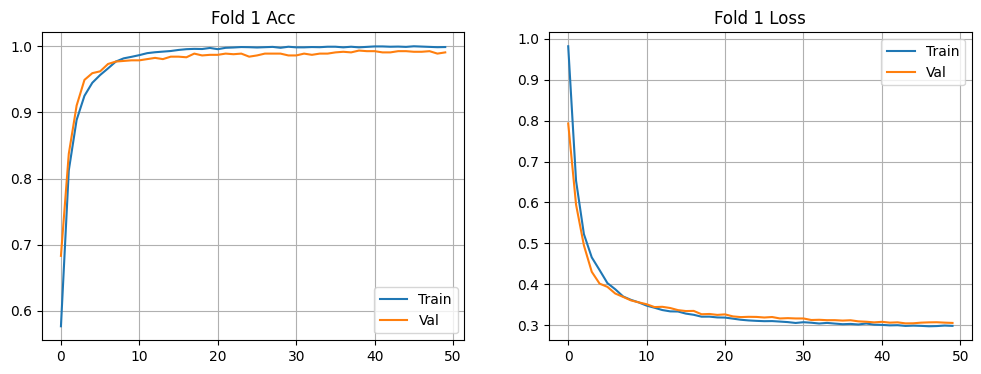

Fold 1 Val Acc: 0.9926 | Test Acc: 0.9917
*** YENİ EN İYİ FOLD: 1 (Acc: 0.9926) ***
Model ve Metrikler Kaydedildi.

================ FOLD 2 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 60s 499ms/step - accuracy: 0.4905 - loss: 1.0690 - val_accuracy: 0.7542 - val_loss: 0.7216 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.8044 - loss: 0.6877 - val_accuracy: 0.8115 - val_loss: 0.6205 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.8960 - loss: 0.5248 - val_accuracy: 0.8854 - val_loss: 0.5212 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.9298 - loss: 0.4601 - val_accuracy: 0.9409 - val_loss: 0.4337 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.9432 - loss: 0.4271 - val_accuracy: 0.9556 - val_loss: 0.4060 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accurac

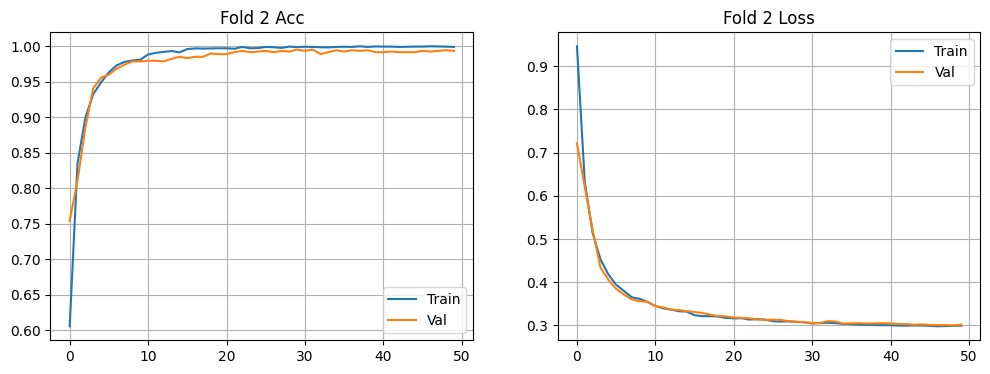

Fold 2 Val Acc: 0.9935 | Test Acc: 0.9867
*** YENİ EN İYİ FOLD: 2 (Acc: 0.9935) ***
Model ve Metrikler Kaydedildi.

================ FOLD 3 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 62s 495ms/step - accuracy: 0.4664 - loss: 1.1041 - val_accuracy: 0.7560 - val_loss: 0.7257 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.8066 - loss: 0.6769 - val_accuracy: 0.8373 - val_loss: 0.5906 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.8932 - loss: 0.5236 - val_accuracy: 0.8956 - val_loss: 0.5205 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9274 - loss: 0.4620 - val_accuracy: 0.9335 - val_loss: 0.4544 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.9534 - loss: 0.4149 - val_accuracy: 0.9519 - val_loss: 0.4149 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accurac

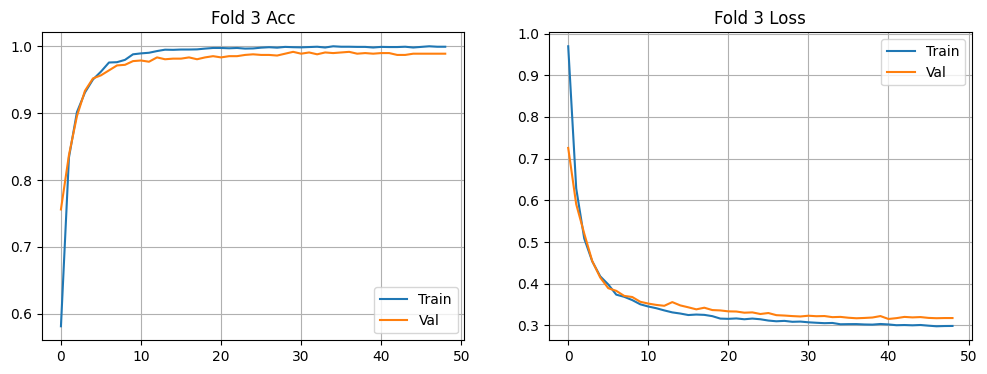

Fold 3 Val Acc: 0.9898 | Test Acc: 0.9867

================ FOLD 4 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 60s 490ms/step - accuracy: 0.4478 - loss: 1.1631 - val_accuracy: 0.7773 - val_loss: 0.7373 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.7924 - loss: 0.6912 - val_accuracy: 0.8364 - val_loss: 0.6110 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.8909 - loss: 0.5227 - val_accuracy: 0.9020 - val_loss: 0.5032 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.9277 - loss: 0.4594 - val_accuracy: 0.9353 - val_loss: 0.4480 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9456 - loss: 0.4316 - val_accuracy: 0.9501 - val_loss: 0.4121 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9575 - loss: 0.3996 - val_accuracy: 0.9566 - val_loss: 0.3953 - lear

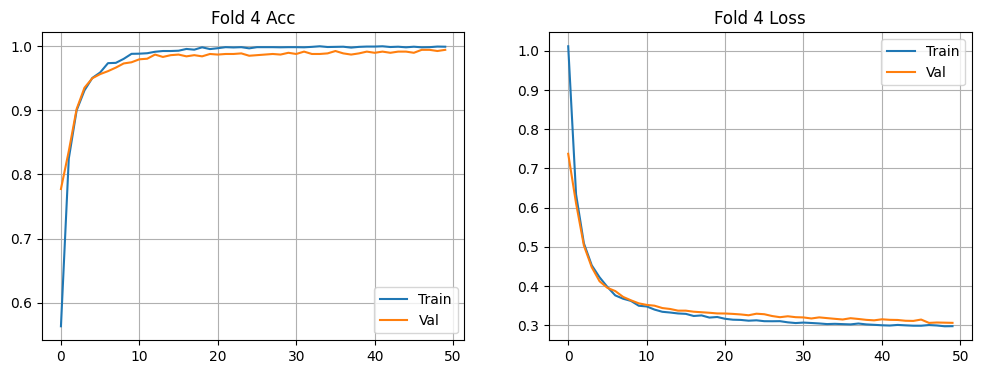

Fold 4 Val Acc: 0.9945 | Test Acc: 0.9917
*** YENİ EN İYİ FOLD: 4 (Acc: 0.9945) ***
Model ve Metrikler Kaydedildi.

================ FOLD 5 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 62s 490ms/step - accuracy: 0.4665 - loss: 1.1347 - val_accuracy: 0.7264 - val_loss: 0.7642 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.7819 - loss: 0.6895 - val_accuracy: 0.8364 - val_loss: 0.5986 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.8916 - loss: 0.5297 - val_accuracy: 0.8956 - val_loss: 0.5086 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.9258 - loss: 0.4680 - val_accuracy: 0.9381 - val_loss: 0.4376 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.9460 - loss: 0.4292 - val_accuracy: 0.9510 - val_loss: 0.4079 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accurac

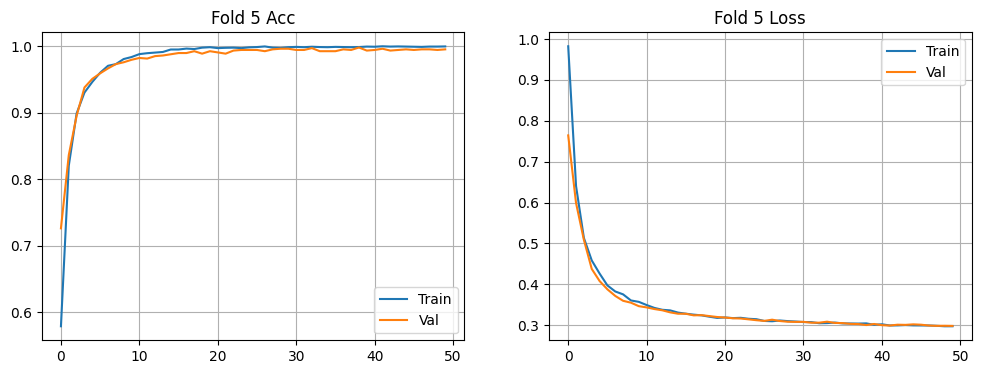

Fold 5 Val Acc: 0.9954 | Test Acc: 0.9884
*** YENİ EN İYİ FOLD: 5 (Acc: 0.9954) ***
Model ve Metrikler Kaydedildi.

>>> TAMAMLANDI. En iyi fold: 5


In [ ]:
# =========================================================
# GOOGLE DRIVE BAĞLANTISI
# =========================================================
# Verilerimiz Drive'da olduğu için önce bulut alanımızı bağlıyoruz.
from google.colab import drive
drive.mount('/content/drive')

# =========================================================
# GEREKLİ KÜTÜPHANELER
# =========================================================
# Temel veri işleme ve görselleştirme araçları.
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model başarısını ölçmek ve veriyi parçalamak için Sklearn kütüphaneleri.
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# Derin öğrenme (Deep Learning) mimarisi için TensorFlow araçları.
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3 # Bu sefer InceptionV3 mimarisini kullanıyoruz.
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.keras import mixed_precision, regularizers

# =========================================================
# 🚀 MIXED PRECISION (A100/T4 PERFORMANS AYARI)
# =========================================================
# GPU'nun tensor çekirdeklerini kullanarak eğitimi hızlandırıyoruz (Mixed Float16).
mixed_precision.set_global_policy("mixed_float16")

# İşlem parçacığı ayarlarını otomatikte bırakıyoruz.
tf.config.threading.set_intra_op_parallelism_threads(0)
tf.config.threading.set_inter_op_parallelism_threads(0)

# =========================================================
# AYARLAR VE PATH TANIMLARI
# =========================================================
# Veri setinin bulunduğu ana klasör.
DATASET_PATH = "/content/drive/MyDrive/Projeypy/Brain_Cancer_Clean"

# Sonuçları InceptionV3 için özel bir klasöre kaydediyoruz ki diğer modellerle karışmasın.
SAVE_DIR = "/content/drive/MyDrive/Projeypy/Sonuclar/InceptionV3_Sonuclar"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"📂 Veri Seti Okunuyor: {DATASET_PATH}")
print(f"💾 Sonuçlar Kaydedilecek: {SAVE_DIR} (Veri setinden ayrı)")

# InceptionV3, 299x299 sever ama 224x224 ile de çalışır. Biz standartı bozmuyoruz.
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 50
SEED = 42 # Rastgeleliği sabitlemek için.

np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# SINIFLARI VE DOSYALARI LİSTELEME
# =========================================================
# Klasör isimlerini okuyup sınıf adlarını oluşturuyoruz.
class_names = sorted(os.listdir(DATASET_PATH))
# "Sonuclar" klasörünü ve gizli dosyaları hariç tutuyoruz.
class_names = [c for c in class_names
               if os.path.isdir(os.path.join(DATASET_PATH, c))
               and "Sonuclar" not in c
               and not c.startswith('.')]

NUM_CLASSES = len(class_names)

# Tüm resimlerin yollarını listeye ekliyoruz.
image_paths, labels = [], []
for i, cls in enumerate(class_names):
    cls_path = os.path.join(DATASET_PATH, cls)
    if not os.path.exists(cls_path): continue
    for img in os.listdir(cls_path):
        if img.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(cls_path, img))
            labels.append(i)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Sınıflar:", class_names)
print("Toplam görüntü:", len(image_paths))

# =========================================================
# TRAIN / TEST AYIRMA
# =========================================================
# Verinin %10'unu final testi için kenara ayırıyoruz.
# 'stratify' sayesinde her sınıftan orantılı örnek alıyoruz.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    image_paths, labels,
    test_size=0.10,
    stratify=labels,
    random_state=SEED
)

print("Train+Val:", len(X_trainval), "| Test:", len(X_test))

# =========================================================
# IMAGE LOADER (INCEPTIONV3 İÇİN ÖZEL NORMALİZASYON)
# =========================================================
def load_image(path, label):
    # Resmi oku ve decode et.
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    # ÖNEMLİ: InceptionV3 modeli, verilerin -1 ile 1 arasında olmasını bekler.
    # Bu yüzden (img / 127.5) - 1.0 formülünü kullanıyoruz.
    # 0 -> -1 olur, 255 -> 1 olur.
    img = tf.cast(img, tf.float32)
    img = (img / 127.5) - 1.0

    return img, tf.one_hot(label, NUM_CLASSES)

# =========================================================
# VERİ ÇOĞALTMA (DATA AUGMENTATION)
# =========================================================
# Eğitim sırasında modele farklı varyasyonlar göstererek ezberlemeyi (overfitting) engelliyoruz.
@tf.function
def augment(img, y):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    # Resme hafif zoom yapıp rastgele bir yerini kesiyoruz.
    big = tf.image.resize(img, (IMG_SIZE + 12, IMG_SIZE + 12))
    img = tf.image.random_crop(big, [IMG_SIZE, IMG_SIZE, 3])
    return img, y

# =========================================================
# TEST VERİ SETİ PIPELINE'I
# =========================================================
# Test verisi için augmentasyon yapmadan sadece boyutlandırma ve normalizasyon uyguluyoruz.
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(load_image)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# =========================================================
# CALLBACKS & MODEL MİMARİSİ
# =========================================================
# Eğitimin başında öğrenme oranını (LR) yavaşça artıran sınıf.
class WarmUpLR(Callback):
    def __init__(self, base_lr=3e-5, warmup_epochs=3):
        super().__init__()
        self.base_lr = base_lr
        self.warmup_epochs = warmup_epochs
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
            self.model.optimizer.learning_rate.assign(lr)

# Eğitim süresini ölçen yardımcı callback.
class TimeHistory(Callback):
    def on_train_begin(self, logs={}): self.times = []
    def on_epoch_begin(self, batch, logs={}): self.epoch_time_start = time.time()
    def on_epoch_end(self, batch, logs={}): self.times.append(time.time() - self.epoch_time_start)

def build_model():
    # Model olarak InceptionV3 kullanıyoruz.
    # ImageNet ağırlıklarıyla başlatıyoruz, tepe katmanını (fully connected) almayıp kendimiz ekleyeceğiz.
    base = InceptionV3(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

    # Fine Tuning: Modelin son 60 katmanını eğitime açıyoruz, gerisini donduruyoruz.
    base.trainable = True
    for layer in base.layers[:-60]:
        layer.trainable = False

    # Kendi sınıflandırma katmanlarımız.
    x = GlobalAveragePooling2D()(base.output)
    # L2 Regularization ile ağırlıkların çok büyümesini engelliyoruz.
    x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = Dropout(0.5)(x) # %50 Dropout ile nöronların birbirine bağımlılığını azaltıyoruz.
    out = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = Model(base.input, out)
    # Label smoothing (0.08) ile modelin aşırı güvenli (overconfident) tahminler yapmasını yumuşatıyoruz.
    model.compile(optimizer=Adam(3e-5), loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08), metrics=["accuracy"])
    return model

# Grafik ve Metrik Kaydetme Fonksiyonu
def save_plot_metrics(history, y_true, y_pred, y_prob, fold, save_path):
    # Eğitim ve Doğrulama grafikleri (Loss & Accuracy)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history["accuracy"], label="Train"); plt.plot(history.history["val_accuracy"], label="Val"); plt.title(f"Accuracy ({fold})"); plt.legend(); plt.grid()
    plt.subplot(1, 2, 2); plt.plot(history.history["loss"], label="Train"); plt.plot(history.history["val_loss"], label="Val"); plt.title(f"Loss ({fold})"); plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_loss_acc.png")); plt.close()

    # Confusion Matrix (Karmaşıklık Matrisi)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6)); sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues"); plt.title(f"CM ({fold})"); plt.savefig(os.path.join(save_path, "best_fold_confusion_matrix.png")); plt.close()

    # ROC Eğrileri
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    plt.figure(figsize=(7, 6))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--"); plt.title(f"ROC ({fold})"); plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_roc_curve.png")); plt.close()

# =========================================================
# 5-FOLD CROSS VALIDATION (ÇAPRAZ DOĞRULAMA)
# =========================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
best_val_acc = 0.0
best_fold_index = 0

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    print(f"\n================ FOLD {fold} =================")
    # Eğitim ve Val setlerini indekslere göre ayırıyoruz.
    X_tr, y_tr = X_trainval[tr_idx], y_trainval[tr_idx]
    X_val, y_val = X_trainval[val_idx], y_trainval[val_idx]

    # Sınıf dengesizliğini yönetmek için ağırlık hesaplama.
    cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(zip(np.unique(y_tr), cw))

    # Dataset Pipeline oluşturma (Train için shuffle+augment, Val için standart).
    train_ds = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr)).shuffle(4096).map(load_image).map(augment).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
    val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val)).map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

    # Her fold için modeli sıfırdan oluşturuyoruz.
    model = build_model()
    time_callback = TimeHistory()

    # Model Eğitimi
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, class_weight=class_weights,
                        callbacks=[WarmUpLR(), EarlyStopping(patience=8, restore_best_weights=True), ReduceLROnPlateau(patience=4, factor=0.3), time_callback], verbose=1)

    # GRAFİKLERİ ANLIK GÖRMEK İÇİN (Kaydetmez, ekrana basar)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history["accuracy"], label="Train"); plt.plot(history.history["val_accuracy"], label="Val"); plt.title(f"Fold {fold} Acc"); plt.legend(); plt.grid()
    plt.subplot(1, 2, 2); plt.plot(history.history["loss"], label="Train"); plt.plot(history.history["val_loss"], label="Val"); plt.title(f"Fold {fold} Loss"); plt.legend(); plt.grid()
    plt.show()

    # METRİKLER VE TAHMİNLER
    val_prob = model.predict(val_ds, verbose=0)
    val_pred = np.argmax(val_prob, axis=1)
    # Gerçek etiketleri datasetten çekiyoruz.
    val_true = np.concatenate([y for x, y in val_ds], axis=0)
    val_true = np.argmax(val_true, axis=1)

    test_prob = model.predict(test_ds, verbose=0)
    test_pred = np.argmax(test_prob, axis=1)

    val_acc = accuracy_score(val_true, val_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print(f"Fold {fold} Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")

    # EĞER BU FOLD EN İYİSİ İSE KAYDET
    if val_acc > best_val_acc:
        print(f"*** YENİ EN İYİ FOLD: {fold} (Acc: {val_acc:.4f}) ***")
        best_val_acc = val_acc
        best_fold_index = fold

        # Modeli kaydet (.h5)
        model.save(os.path.join(SAVE_DIR, "best_inceptionv3_model.h5"))
        # Grafikleri Drive'a kaydet
        save_plot_metrics(history, y_test, test_pred, test_prob, fold, SAVE_DIR)

        # CSV Metrikleri
        avg_epoch_time = np.mean(time_callback.times)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, test_pred, average='weighted')
        df = pd.DataFrame([{
            "Model": "InceptionV3", "Best_Fold": fold,
            "Val_Accuracy": val_acc, "Test_Accuracy": test_acc,
            "Precision": precision, "Recall": recall, "F1_Score": f1,
            "Avg_Epoch_Time_Sec": avg_epoch_time
        }])
        df.to_csv(os.path.join(SAVE_DIR, "best_model_metrics.csv"), index=False)
        print("Model ve Metrikler Kaydedildi.")

print(f"\n>>> TAMAMLANDI. En iyi fold: {best_fold_index}")

**Xception**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Veri Seti Okunuyor: /content/drive/MyDrive/Projeypy/Brain_Cancer_Clean
💾 Sonuçlar Kaydedilecek: /content/drive/MyDrive/Projeypy/Sonuclar/Xception_Sonuclar (Veri setinden ayrı)
Sınıflar: ['brain_glioma', 'brain_menin', 'brain_tumor']
Toplam görüntü: 6012
Train+Val: 5410 | Test: 602

================ FOLD 1 =================
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 280s 3s/step - accuracy: 0.4529 - loss: 1.1035 - val_accuracy: 0.7421 - val_loss: 0.8372 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.8077 - loss: 0.7587 - val_accuracy: 0.8364 - val_loss: 0.5751 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9052 - loss: 0.4954 - val_accuracy: 0.9261 - val_loss: 0.4498 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━

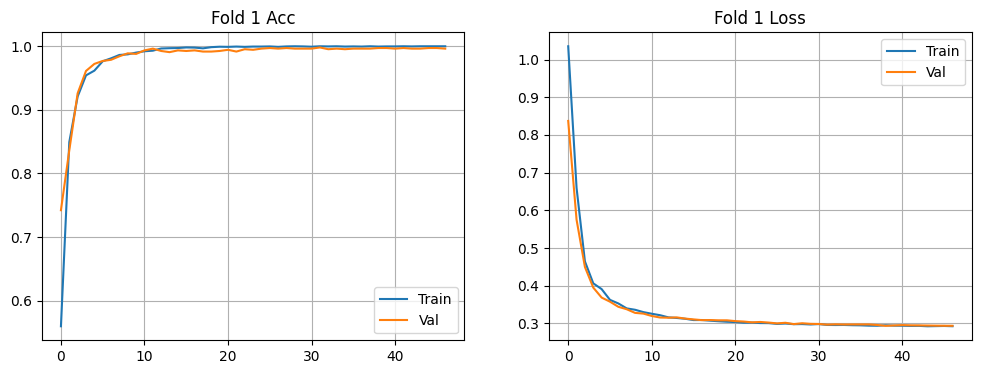

Fold 1 Val Acc: 0.9972 | Test Acc: 0.9950
*** YENİ EN İYİ FOLD: 1 (Acc: 0.9972) ***
Model ve Metrikler Kaydedildi.

================ FOLD 2 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.4227 - loss: 1.1198 - val_accuracy: 0.7033 - val_loss: 0.8571 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.7804 - loss: 0.7852 - val_accuracy: 0.7930 - val_loss: 0.6475 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.9176 - loss: 0.4860 - val_accuracy: 0.9076 - val_loss: 0.4836 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9469 - loss: 0.4166 - val_accuracy: 0.9640 - val_loss: 0.3953 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.9587 - loss: 0.3906 - val_accuracy: 0.9741 - val_loss: 0.3613 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy:

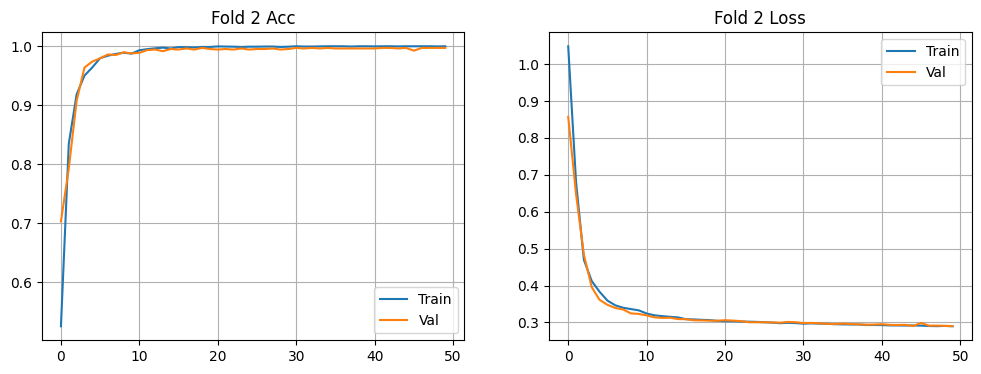

Fold 2 Val Acc: 0.9972 | Test Acc: 0.9934

================ FOLD 3 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.4986 - loss: 1.0791 - val_accuracy: 0.7893 - val_loss: 0.7925 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.8198 - loss: 0.7384 - val_accuracy: 0.8567 - val_loss: 0.5787 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.9230 - loss: 0.4756 - val_accuracy: 0.9335 - val_loss: 0.4511 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.9547 - loss: 0.4099 - val_accuracy: 0.9510 - val_loss: 0.4084 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.9695 - loss: 0.3790 - val_accuracy: 0.9630 - val_loss: 0.3735 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9752 - loss: 0.3609 - val_accuracy: 0.9704 - val_loss: 0.3577 - learni

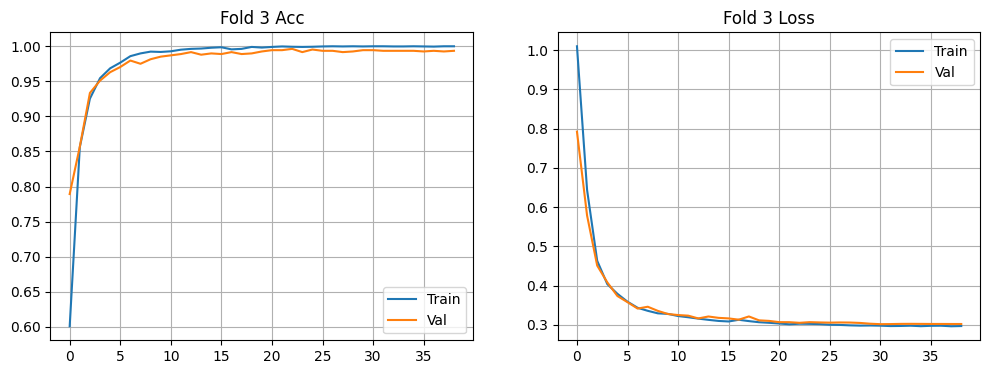

Fold 3 Val Acc: 0.9945 | Test Acc: 0.9917

================ FOLD 4 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.4143 - loss: 1.1248 - val_accuracy: 0.5388 - val_loss: 0.9703 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.7994 - loss: 0.7694 - val_accuracy: 0.8290 - val_loss: 0.6013 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.9157 - loss: 0.4906 - val_accuracy: 0.9113 - val_loss: 0.4746 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9454 - loss: 0.4145 - val_accuracy: 0.9482 - val_loss: 0.4069 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.9658 - loss: 0.3846 - val_accuracy: 0.9630 - val_loss: 0.3699 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.9704 - loss: 0.3674 - val_accuracy: 0.9750 - val_loss: 0.3520 - learn

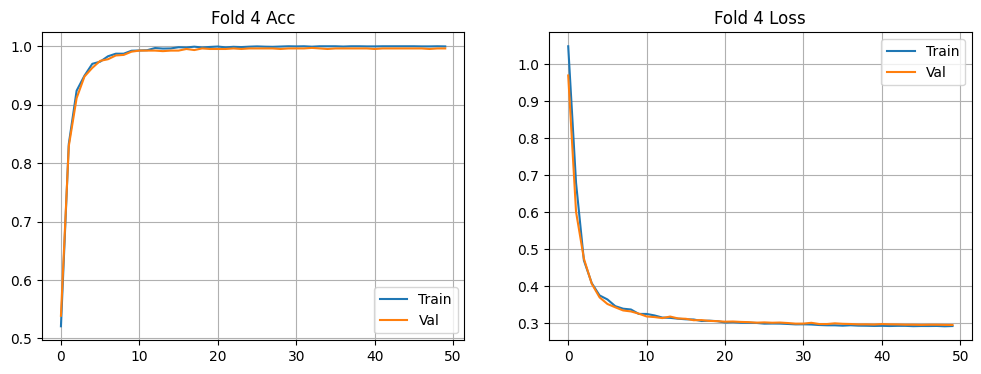

Fold 4 Val Acc: 0.9963 | Test Acc: 0.9934

================ FOLD 5 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.4531 - loss: 1.1078 - val_accuracy: 0.7079 - val_loss: 0.8466 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.8139 - loss: 0.7473 - val_accuracy: 0.8863 - val_loss: 0.5125 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.9120 - loss: 0.4940 - val_accuracy: 0.9381 - val_loss: 0.4299 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.9390 - loss: 0.4210 - val_accuracy: 0.9612 - val_loss: 0.3825 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.9622 - loss: 0.3838 - val_accuracy: 0.9732 - val_loss: 0.3601 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.9731 - loss: 0.3650 - val_accuracy: 0.9806 - val_loss: 0.3430 - learn

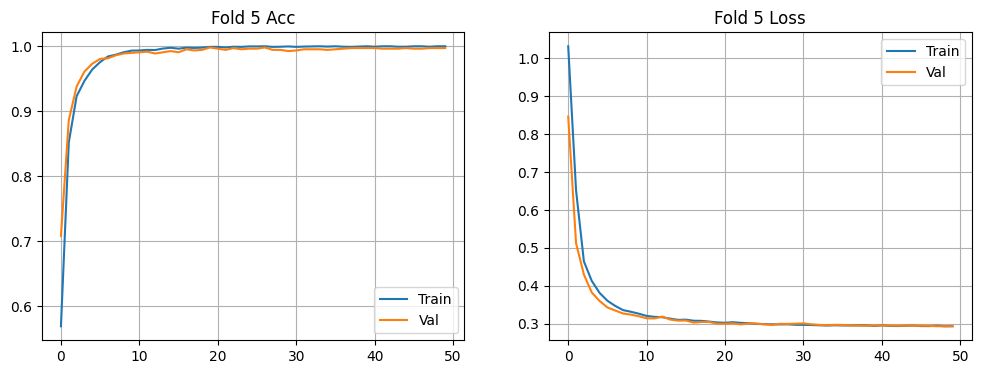

Fold 5 Val Acc: 0.9972 | Test Acc: 0.9900

>>> Xception EĞİTİMİ TAMAMLANDI. En iyi fold: 1


In [ ]:
# =========================================================
# GOOGLE DRIVE BAĞLANTISI
# =========================================================
# Verilerimiz bulutta olduğu için Drive'ı bağlıyoruz.
from google.colab import drive
drive.mount('/content/drive')

# =========================================================
# GEREKLİ KÜTÜPHANELER
# =========================================================
# Veri işleme, görselleştirme ve makine öğrenmesi metrikleri.
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model değerlendirme ve veri bölme araçları.
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# Derin öğrenme altyapısı (TensorFlow/Keras).
import tensorflow as tf
# --- DEĞİŞİKLİK: Xception Modelini Çağırıyoruz ---
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.keras import mixed_precision, regularizers

# =========================================================
# 🚀 MIXED PRECISION (HIZLANDIRMA)
# =========================================================
# GPU belleğini verimli kullanmak ve eğitimi hızlandırmak için mixed precision (float16) açıyoruz.
mixed_precision.set_global_policy("mixed_float16")

# İşlem parçacığı ayarlarını varsayılana bırakıyoruz.
tf.config.threading.set_intra_op_parallelism_threads(0)
tf.config.threading.set_inter_op_parallelism_threads(0)

# =========================================================
# AYARLAR VE KLASÖR YOLU
# =========================================================
# Veri setinin ana yolu.
DATASET_PATH = "/content/drive/MyDrive/Projeypy/Brain_Cancer_Clean"

# --- DEĞİŞİKLİK: Sonuçları Xception klasörüne kaydedeceğiz ---
SAVE_DIR = "/content/drive/MyDrive/Projeypy/Sonuclar/Xception_Sonuclar"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"📂 Veri Seti Okunuyor: {DATASET_PATH}")
print(f"💾 Sonuçlar Kaydedilecek: {SAVE_DIR} (Veri setinden ayrı)")

IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 50
SEED = 42 # Sonuçların tekrar edilebilir olması için sabit seed.

np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# SINIFLARI VE DOSYALARI LİSTELEME
# =========================================================
# Klasör isimlerini alıp sınıf listesini oluşturuyoruz.
class_names = sorted(os.listdir(DATASET_PATH))
# Gereksiz dosyaları ve sonuç klasörünü hariç tutuyoruz.
class_names = [c for c in class_names
               if os.path.isdir(os.path.join(DATASET_PATH, c))
               and "Sonuclar" not in c
               and not c.startswith('.')]

NUM_CLASSES = len(class_names) # Sınıf sayısı

# Tüm resim yollarını ve etiketlerini topluyoruz.
image_paths, labels = [], []
for i, cls in enumerate(class_names):
    cls_path = os.path.join(DATASET_PATH, cls)
    if not os.path.exists(cls_path): continue
    for img in os.listdir(cls_path):
        if img.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(cls_path, img))
            labels.append(i)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Sınıflar:", class_names)
print("Toplam görüntü:", len(image_paths))

# =========================================================
# TRAIN / TEST BÖLME
# =========================================================
# Verinin %90'ını eğitim/doğrulama, %10'unu final testi için ayırıyoruz.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    image_paths, labels,
    test_size=0.10,
    stratify=labels,
    random_state=SEED
)

print("Train+Val:", len(X_trainval), "| Test:", len(X_test))

# =========================================================
# IMAGE LOADER (XCEPTION İÇİN ÖZEL PREPROCESSING)
# =========================================================
def load_image(path, label):
    # Resmi oku ve decode et.
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    # Xception Preprocessing:
    # Xception, Inception mimarisine dayandığı için o da verilerin -1 ile 1 arasında olmasını ister.
    # Formül: (x / 127.5) - 1.0
    img = tf.cast(img, tf.float32)
    img = (img / 127.5) - 1.0

    return img, tf.one_hot(label, NUM_CLASSES)

# =========================================================
# VERİ ÇOĞALTMA (DATA AUGMENTATION)
# =========================================================
# Eğitim verisini çeşitlendirerek modelin ezberlemesini önlüyoruz.
@tf.function
def augment(img, y):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    # Zoom benzeri etki için büyütüp kırpıyoruz.
    big = tf.image.resize(img, (IMG_SIZE + 12, IMG_SIZE + 12))
    img = tf.image.random_crop(big, [IMG_SIZE, IMG_SIZE, 3])
    return img, y

# =========================================================
# TEST VERİ SETİ
# =========================================================
# Test verisi için augmentation yapmıyoruz, sadece batch'liyoruz.
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(load_image)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# =========================================================
# CALLBACKS & MODEL MİMARİSİ
# =========================================================
# Eğitimin başında LR'yi yavaşça artıran sınıf.
class WarmUpLR(Callback):
    def __init__(self, base_lr=3e-5, warmup_epochs=3):
        super().__init__()
        self.base_lr = base_lr
        self.warmup_epochs = warmup_epochs
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
            self.model.optimizer.learning_rate.assign(lr)

# Eğitim süresini epoch başına tutan sınıf.
class TimeHistory(Callback):
    def on_train_begin(self, logs={}): self.times = []
    def on_epoch_begin(self, batch, logs={}): self.epoch_time_start = time.time()
    def on_epoch_end(self, batch, logs={}): self.times.append(time.time() - self.epoch_time_start)

def build_model():
    # --- DEĞİŞİKLİK: Xception Modelini Yüklüyoruz ---
    # ImageNet ağırlıklarıyla başlatıyoruz, son katmanı almıyoruz.
    base = Xception(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Fine Tuning: Son 60 katman hariç geri kalanını donduruyoruz.
    base.trainable = True
    for layer in base.layers[:-60]:
        layer.trainable = False

    # Kendi sınıflandırıcımızı ekliyoruz.
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = Dropout(0.5)(x) # Overfitting önleyici dropout.
    out = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = Model(base.input, out)
    # Label smoothing (0.08) ile modelin aşırı güvenini kırıyoruz.
    model.compile(optimizer=Adam(3e-5), loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08), metrics=["accuracy"])
    return model

# Grafik Kaydetme Fonksiyonu
def save_plot_metrics(history, y_true, y_pred, y_prob, fold, save_path):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history["accuracy"], label="Train"); plt.plot(history.history["val_accuracy"], label="Val"); plt.title(f"Accuracy ({fold})"); plt.legend(); plt.grid()
    plt.subplot(1, 2, 2); plt.plot(history.history["loss"], label="Train"); plt.plot(history.history["val_loss"], label="Val"); plt.title(f"Loss ({fold})"); plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_loss_acc.png")); plt.close()

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6)); sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues"); plt.title(f"CM ({fold})"); plt.savefig(os.path.join(save_path, "best_fold_confusion_matrix.png")); plt.close()

    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    plt.figure(figsize=(7, 6))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--"); plt.title(f"ROC ({fold})"); plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_roc_curve.png")); plt.close()

# =========================================================
# 5-FOLD CROSS VALIDATION (ÇAPRAZ DOĞRULAMA)
# =========================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
best_val_acc = 0.0
best_fold_index = 0

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    print(f"\n================ FOLD {fold} =================")
    # Eğitim ve Doğrulama verisini ayırıyoruz.
    X_tr, y_tr = X_trainval[tr_idx], y_trainval[tr_idx]
    X_val, y_val = X_trainval[val_idx], y_trainval[val_idx]

    # Sınıf ağırlıklarını hesapla.
    cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(zip(np.unique(y_tr), cw))

    # Datasetleri oluştur.
    train_ds = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr)).shuffle(4096).map(load_image).map(augment).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
    val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val)).map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

    # Modeli oluştur.
    model = build_model()
    time_callback = TimeHistory()

    # Eğitimi başlat.
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, class_weight=class_weights,
                        callbacks=[WarmUpLR(), EarlyStopping(patience=8, restore_best_weights=True), ReduceLROnPlateau(patience=4, factor=0.3), time_callback], verbose=1)

    # GRAFİKLER (Ekranda anlık takip için)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history["accuracy"], label="Train"); plt.plot(history.history["val_accuracy"], label="Val"); plt.title(f"Fold {fold} Acc"); plt.legend(); plt.grid()
    plt.subplot(1, 2, 2); plt.plot(history.history["loss"], label="Train"); plt.plot(history.history["val_loss"], label="Val"); plt.title(f"Fold {fold} Loss"); plt.legend(); plt.grid()
    plt.show()

    # METRİKLER
    val_prob = model.predict(val_ds, verbose=0)
    val_pred = np.argmax(val_prob, axis=1)
    val_true = np.concatenate([y for x, y in val_ds], axis=0)
    val_true = np.argmax(val_true, axis=1)

    test_prob = model.predict(test_ds, verbose=0)
    test_pred = np.argmax(test_prob, axis=1)

    val_acc = accuracy_score(val_true, val_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print(f"Fold {fold} Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")

    # EN İYİ FOLD KAYIT İŞLEMİ
    if val_acc > best_val_acc:
        print(f"*** YENİ EN İYİ FOLD: {fold} (Acc: {val_acc:.4f}) ***")
        best_val_acc = val_acc
        best_fold_index = fold

        # --- DEĞİŞİKLİK: Xception Modelini Kaydet ---
        model.save(os.path.join(SAVE_DIR, "best_xception_model.h5"))
        save_plot_metrics(history, y_test, test_pred, test_prob, fold, SAVE_DIR)

        avg_epoch_time = np.mean(time_callback.times)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, test_pred, average='weighted')

        # --- DEĞİŞİKLİK: CSV'ye Xception Olarak Yaz ---
        df = pd.DataFrame([{
            "Model": "Xception", "Best_Fold": fold,
            "Val_Accuracy": val_acc, "Test_Accuracy": test_acc,
            "Precision": precision, "Recall": recall, "F1_Score": f1,
            "Avg_Epoch_Time_Sec": avg_epoch_time
        }])
        df.to_csv(os.path.join(SAVE_DIR, "best_model_metrics.csv"), index=False)
        print("Model ve Metrikler Kaydedildi.")

print(f"\n>>> Xception EĞİTİMİ TAMAMLANDI. En iyi fold: {best_fold_index}")

# HYBRİD **MODELLER**

**HYBRİD** InceptionV3 ve Xception

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Veri Seti Okunuyor: /content/drive/MyDrive/Projeypy/Brain_Cancer_Clean
💾 Sonuçlar Kaydedilecek: /content/drive/MyDrive/Projeypy/Sonuclar/Hybrid_Inception_Xception_FineTuned
Sınıflar: ['brain_glioma', 'brain_menin', 'brain_tumor']
Toplam görüntü: 6012
Train+Val: 5410 | Test: 602

================ HYBRID FOLD 1 (FINE-TUNING) =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 0.5072 - loss: 1.0645 - val_accuracy: 0.7662 - val_loss: 0.7087 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.8546 - loss: 0.6151 - val_accuracy: 0.8577 - val_loss: 0.5729 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.9116 - loss: 0.4800 - val_accuracy: 0.9399 - val_loss: 0.4368 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - ac

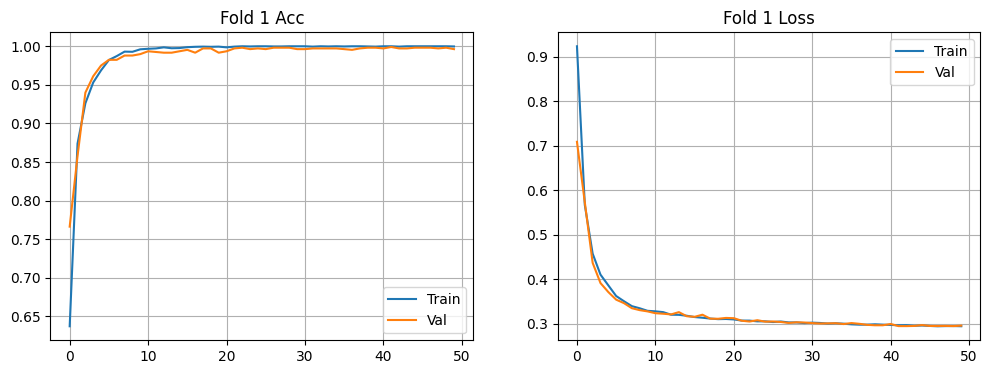

Fold 1 Val Acc: 0.9972 | Test Acc: 0.9950
*** YENİ EN İYİ HYBRID FOLD: 1 (Acc: 0.9972) ***
Hybrid Model ve Metrikler Kaydedildi.

================ HYBRID FOLD 2 (FINE-TUNING) =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.4695 - loss: 1.0930 - val_accuracy: 0.7985 - val_loss: 0.6645 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.8331 - loss: 0.6449 - val_accuracy: 0.8392 - val_loss: 0.5968 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.9267 - loss: 0.4815 - val_accuracy: 0.9224 - val_loss: 0.4795 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.9547 - loss: 0.4149 - val_accuracy: 0.9677 - val_loss: 0.3848 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.9701 - loss: 0.3837 - val_accuracy: 0.9769 - val_loss: 0.3628 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━

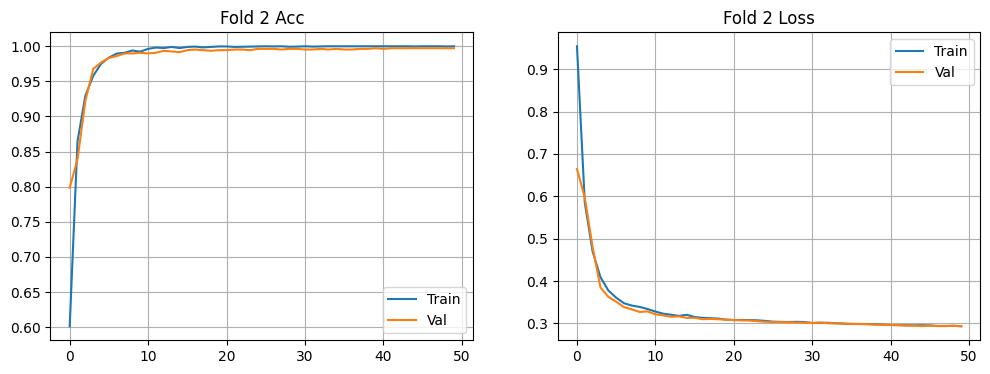

Fold 2 Val Acc: 0.9972 | Test Acc: 0.9950

================ HYBRID FOLD 3 (FINE-TUNING) =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.4948 - loss: 1.0776 - val_accuracy: 0.7449 - val_loss: 0.7293 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.8431 - loss: 0.6382 - val_accuracy: 0.8244 - val_loss: 0.6430 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.9158 - loss: 0.4747 - val_accuracy: 0.8983 - val_loss: 0.5277 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.9493 - loss: 0.4185 - val_accuracy: 0.9519 - val_loss: 0.4327 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.9735 - loss: 0.3812 - val_accuracy: 0.9686 - val_loss: 0.3726 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.9852 - loss: 0.3599 - val_accuracy: 0.9787 -

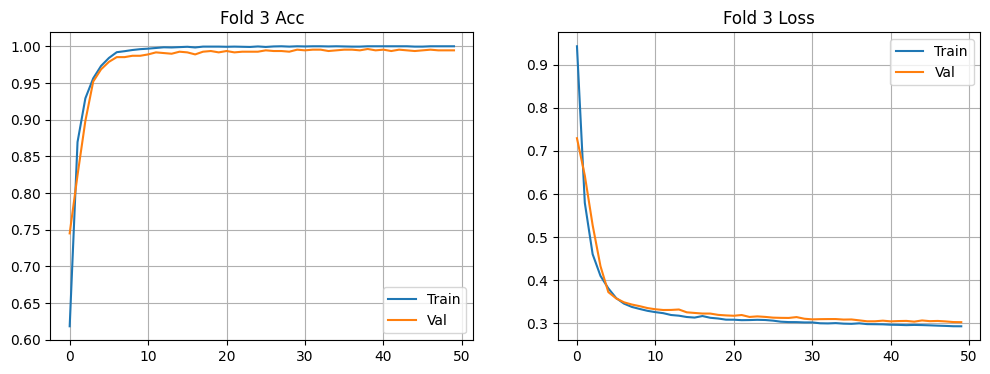

Fold 3 Val Acc: 0.9945 | Test Acc: 0.9884

================ HYBRID FOLD 4 (FINE-TUNING) =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step - accuracy: 0.5024 - loss: 1.0602 - val_accuracy: 0.8004 - val_loss: 0.6717 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.8410 - loss: 0.6201 - val_accuracy: 0.9076 - val_loss: 0.4938 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.9315 - loss: 0.4699 - val_accuracy: 0.9482 - val_loss: 0.4280 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.9521 - loss: 0.4174 - val_accuracy: 0.9593 - val_loss: 0.3994 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.9697 - loss: 0.3862 - val_accuracy: 0.9667 - val_loss: 0.3710 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 144ms/step - accuracy: 0.9825 - loss: 0.3613 - val_accuracy: 0.9797 -

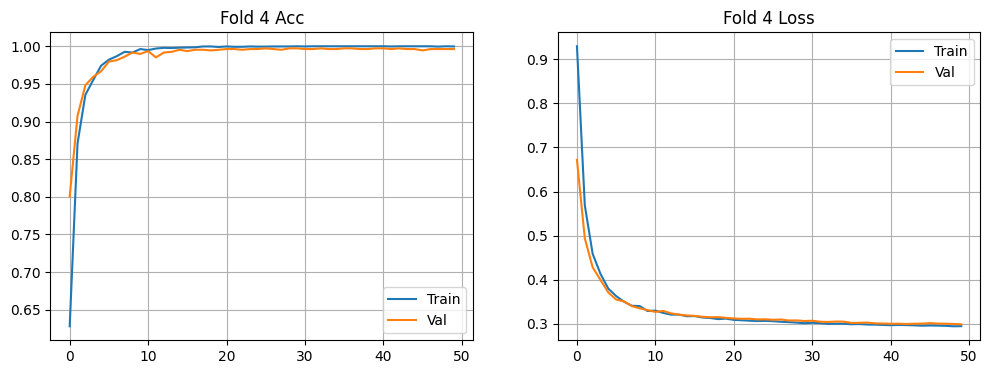

Fold 4 Val Acc: 0.9963 | Test Acc: 0.9917

================ HYBRID FOLD 5 (FINE-TUNING) =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.4840 - loss: 1.1665 - val_accuracy: 0.7061 - val_loss: 0.7920 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.8363 - loss: 0.6463 - val_accuracy: 0.7902 - val_loss: 0.7023 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.9305 - loss: 0.4691 - val_accuracy: 0.8965 - val_loss: 0.5204 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.9594 - loss: 0.4091 - val_accuracy: 0.9492 - val_loss: 0.4241 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.9756 - loss: 0.3766 - val_accuracy: 0.9686 - val_loss: 0.3803 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - accuracy: 0.9812 - loss: 0.3588 - val_accuracy: 0.9852 - 

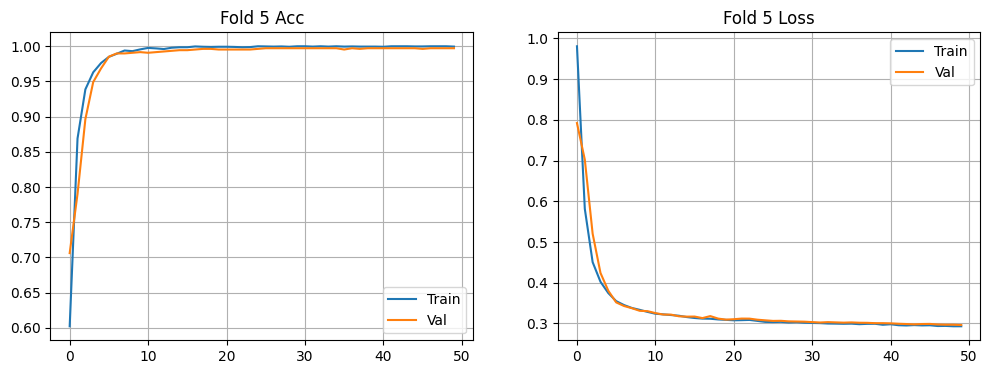

Fold 5 Val Acc: 0.9972 | Test Acc: 0.9934

>>> HYBRID EĞİTİM (FINE-TUNED) TAMAMLANDI. En iyi fold: 1


In [ ]:
# =========================================================
# GOOGLE DRIVE BAĞLANTISI
# =========================================================
# Verilerimiz bulutta, bu yüzden Drive'a kapıyı açıyoruz.
from google.colab import drive
drive.mount('/content/drive')

# =========================================================
# GEREKLİ KÜTÜPHANELER
# =========================================================
# Veri işleme, görselleştirme ve metrikler için standart kütüphanelerimiz.
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn araçları: Veriyi bölmek ve sonuçları ölçmek için.
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# Derin Öğrenme (Deep Learning) Kütüphaneleri
import tensorflow as tf
# İki modeli de aynı anda çağırıyoruz: InceptionV3 ve Xception
from tensorflow.keras.applications import InceptionV3, Xception
# Modelleri birleştirmek için 'Concatenate' katmanını ekliyoruz.
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.keras import mixed_precision, regularizers

# =========================================================
# 🚀 MIXED PRECISION (A100 PERFORMANS)
# =========================================================
# Bu hibrit model büyük olduğu için GPU belleğini verimli kullanmak şart.
# Mixed Precision ile hem hız kazanıyoruz hem de bellekten tasarruf ediyoruz.
mixed_precision.set_global_policy("mixed_float16")

# İşlem parçacığı ayarları.
tf.config.threading.set_intra_op_parallelism_threads(0)
tf.config.threading.set_inter_op_parallelism_threads(0)

# =========================================================
# AYARLAR VE KLASÖR YOLLARI
# =========================================================
DATASET_PATH = "/content/drive/MyDrive/Projeypy/Brain_Cancer_Clean"

# --- Kayıt Klasörü: Hybrid (Fine-Tuning) ---
# Sonuçları, diğer tekil modellerden ayırmak için özel bir klasöre alıyoruz.
SAVE_DIR = "/content/drive/MyDrive/Projeypy/Sonuclar/Hybrid_Inception_Xception_FineTuned"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"📂 Veri Seti Okunuyor: {DATASET_PATH}")
print(f"💾 Sonuçlar Kaydedilecek: {SAVE_DIR}")

# Görüntü boyutu ve eğitim parametreleri.
# Hybrid model daha fazla bellek yiyeceği için batch size'a dikkat edilmeli ama A100 ile 64 rahat kurtarır.
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 50
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# SINIFLARI VE DOSYALARI LİSTELEME
# =========================================================
class_names = sorted(os.listdir(DATASET_PATH))
class_names = [c for c in class_names
               if os.path.isdir(os.path.join(DATASET_PATH, c))
               and "Sonuclar" not in c
               and not c.startswith('.')]

NUM_CLASSES = len(class_names)

# Resim yollarını topluyoruz.
image_paths, labels = [], []
for i, cls in enumerate(class_names):
    cls_path = os.path.join(DATASET_PATH, cls)
    if not os.path.exists(cls_path): continue
    for img in os.listdir(cls_path):
        if img.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(cls_path, img))
            labels.append(i)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Sınıflar:", class_names)
print("Toplam görüntü:", len(image_paths))

# =========================================================
# TRAIN / TEST BÖLME
# =========================================================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    image_paths, labels,
    test_size=0.10,
    stratify=labels,
    random_state=SEED
)

print("Train+Val:", len(X_trainval), "| Test:", len(X_test))

# =========================================================
# IMAGE LOADER (ORTAK PREPROCESSING)
# =========================================================
def load_image(path, label):
    # Resmi oku ve decode et.
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    # Şanslıyız ki hem InceptionV3 hem de Xception aynı ön işlemeyi sever:
    # Piksel değerleri -1 ile 1 arasında olmalıdır.
    # Formül: (x / 127.5) - 1.0
    img = tf.cast(img, tf.float32)
    img = (img / 127.5) - 1.0

    return img, tf.one_hot(label, NUM_CLASSES)

# =========================================================
# VERİ ÇOĞALTMA (AUGMENTATION)
# =========================================================
# Modelin ezberlemesini önlemek için veri çeşitlendirme.
@tf.function
def augment(img, y):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    big = tf.image.resize(img, (IMG_SIZE + 12, IMG_SIZE + 12))
    img = tf.image.random_crop(big, [IMG_SIZE, IMG_SIZE, 3])
    return img, y

# =========================================================
# TEST VERİ SETİ
# =========================================================
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(load_image)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# =========================================================
# CALLBACKS (YARDIMCI FONKSİYONLAR)
# =========================================================
class WarmUpLR(Callback):
    def __init__(self, base_lr=3e-5, warmup_epochs=3):
        super().__init__()
        self.base_lr = base_lr
        self.warmup_epochs = warmup_epochs
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
            self.model.optimizer.learning_rate.assign(lr)

class TimeHistory(Callback):
    def on_train_begin(self, logs={}): self.times = []
    def on_epoch_begin(self, batch, logs={}): self.epoch_time_start = time.time()
    def on_epoch_end(self, batch, logs={}): self.times.append(time.time() - self.epoch_time_start)

# =========================================================
# 🔥 HYBRID MODEL (INCEPTION + XCEPTION BİRLEŞİMİ) 🔥
# =========================================================
# Bu fonksiyon, iki güçlü modeli yan yana getirip (paralel bağlayıp) özelliklerini birleştirir.
def build_hybrid_model():
    # Ortak giriş katmanı (Her iki model de aynı resmi görecek).
    input_tensor = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # --- KOL 1: INCEPTION V3 ---
    # InceptionV3 modelini yüklüyoruz.
    base_inception = InceptionV3(weights="imagenet", include_top=False, input_tensor=input_tensor)

    # Keras'ta iki model birleşince katman isimleri çakışabilir (örn: 'conv2d_1').
    # Bunu önlemek için her katmanın ismine 'inc_' ön eki ekliyoruz.
    for layer in base_inception.layers: layer._name = "inc_" + layer.name

    # FINE-TUNING STRATEJİSİ:
    # Modelin genelini eğitime açıyoruz (trainable=True),
    # FAKAT sonra ilk katmanları dondurup sadece son 60 katmanı açık bırakıyoruz.
    base_inception.trainable = True
    for layer in base_inception.layers[:-60]:
        layer.trainable = False

    # Inception'ın çıkışını alıp vektör haline getiriyoruz.
    x1 = base_inception.output
    x1 = GlobalAveragePooling2D(name="avg_pool_inception")(x1)

    # --- KOL 2: XCEPTION ---
    # Xception modelini yüklüyoruz.
    base_xception = Xception(weights="imagenet", include_top=False, input_tensor=input_tensor)
    # Katman isim karışıklığını önlemek için 'xcp_' ön eki ekliyoruz.
    for layer in base_xception.layers: layer._name = "xcp_" + layer.name

    # FINE-TUNING STRATEJİSİ (Aynı mantık):
    # Son 60 katman hariç donduruyoruz.
    base_xception.trainable = True
    for layer in base_xception.layers[:-60]:
        layer.trainable = False

    # Xception'ın çıkışını alıp vektör haline getiriyoruz.
    x2 = base_xception.output
    x2 = GlobalAveragePooling2D(name="avg_pool_xception")(x2)

    # --- BİRLEŞTİRME (FEATURE FUSION) ---
    # İki dev modelden gelen özellik vektörlerini (x1 ve x2) yan yana yapıştırıyoruz.
    #
    merged = Concatenate(name="concat_features")([x1, x2])

    # --- ORTAK KARAR KATMANI ---
    # Artık elimizde çok zengin bir özellik havuzu var. Bunu sınıflandırmak için Dense katmanlara veriyoruz.
    x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(merged)
    x = Dropout(0.5)(x) # Ezberlemeyi önlemek için.
    output = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    # Modeli inşa ediyoruz. Giriş tek, çıkış tek ama içeride iki yol var.
    model = Model(inputs=input_tensor, outputs=output, name="Hybrid_Inception_Xception_FineTuned")

    # Fine-Tuning yaptığımız için Learning Rate'i (Öğrenme Hızı) düşük tutuyoruz (3e-5).
    # Çok yüksek olursa önceden öğrenilmiş hassas ağırlıkları bozarız.
    model.compile(
        optimizer=Adam(3e-5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08),
        metrics=["accuracy"]
    )
    return model

# Grafik Kaydetme Yardımcısı
def save_plot_metrics(history, y_true, y_pred, y_prob, fold, save_path):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history["accuracy"], label="Train"); plt.plot(history.history["val_accuracy"], label="Val"); plt.title(f"Accuracy ({fold})"); plt.legend(); plt.grid()
    plt.subplot(1, 2, 2); plt.plot(history.history["loss"], label="Train"); plt.plot(history.history["val_loss"], label="Val"); plt.title(f"Loss ({fold})"); plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_loss_acc.png")); plt.close()

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6)); sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Greens"); plt.title(f"CM ({fold})"); plt.savefig(os.path.join(save_path, "best_fold_confusion_matrix.png")); plt.close()

    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    plt.figure(figsize=(7, 6))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--"); plt.title(f"ROC ({fold})"); plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_roc_curve.png")); plt.close()

# =========================================================
# 5-FOLD CROSS VALIDATION (ÇAPRAZ DOĞRULAMA)
# =========================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
best_val_acc = 0.0
best_fold_index = 0

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    print(f"\n================ HYBRID FOLD {fold} (FINE-TUNING) =================")
    X_tr, y_tr = X_trainval[tr_idx], y_trainval[tr_idx]
    X_val, y_val = X_trainval[val_idx], y_trainval[val_idx]

    # Sınıf ağırlıkları hesaplama.
    cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(zip(np.unique(y_tr), cw))

    # Datasetleri hazırlama.
    train_ds = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr)).shuffle(4096).map(load_image).map(augment).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
    val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val)).map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

    # Hybrid modeli oluşturma.
    model = build_hybrid_model()
    time_callback = TimeHistory()

    # Eğitimi başlatma.
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, class_weight=class_weights,
                        callbacks=[WarmUpLR(), EarlyStopping(patience=8, restore_best_weights=True), ReduceLROnPlateau(patience=4, factor=0.3), time_callback], verbose=1)

    # Grafikleri ekranda gösterme.
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history["accuracy"], label="Train"); plt.plot(history.history["val_accuracy"], label="Val"); plt.title(f"Fold {fold} Acc"); plt.legend(); plt.grid()
    plt.subplot(1, 2, 2); plt.plot(history.history["loss"], label="Train"); plt.plot(history.history["val_loss"], label="Val"); plt.title(f"Fold {fold} Loss"); plt.legend(); plt.grid()
    plt.show()

    # Tahminler ve Metrikler.
    val_prob = model.predict(val_ds, verbose=0)
    val_pred = np.argmax(val_prob, axis=1)
    val_true = np.concatenate([y for x, y in val_ds], axis=0)
    val_true = np.argmax(val_true, axis=1)

    test_prob = model.predict(test_ds, verbose=0)
    test_pred = np.argmax(test_prob, axis=1)

    val_acc = accuracy_score(val_true, val_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print(f"Fold {fold} Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")

    # En iyi sonucu kaydetme.
    if val_acc > best_val_acc:
        print(f"*** YENİ EN İYİ HYBRID FOLD: {fold} (Acc: {val_acc:.4f}) ***")
        best_val_acc = val_acc
        best_fold_index = fold

        # Hybrid model adıyla kaydet.
        model.save(os.path.join(SAVE_DIR, "best_hybrid_inc_xcp_finetuned.h5"))
        save_plot_metrics(history, y_test, test_pred, test_prob, fold, SAVE_DIR)

        avg_epoch_time = np.mean(time_callback.times)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, test_pred, average='weighted')

        df = pd.DataFrame([{
            "Model": "Hybrid_FineTuned (Inception+Xception)", "Best_Fold": fold,
            "Val_Accuracy": val_acc, "Test_Accuracy": test_acc,
            "Precision": precision, "Recall": recall, "F1_Score": f1,
            "Avg_Epoch_Time_Sec": avg_epoch_time
        }])
        df.to_csv(os.path.join(SAVE_DIR, "best_hybrid_metrics.csv"), index=False)
        print("Hybrid Model ve Metrikler Kaydedildi.")

print(f"\n>>> HYBRID EĞİTİM (FINE-TUNED) TAMAMLANDI. En iyi fold: {best_fold_index}")

**HYBRİD** DenseNet121 ve EfficientNetB0

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Veri Seti Okunuyor: /content/drive/MyDrive/Projeypy/Brain_Cancer_Clean
💾 Sonuçlar Kaydedilecek: /content/drive/MyDrive/Projeypy/Sonuclar/Hybrid_DenseNet_FineTuned_EfficientNet_Frozen
Sınıflar: ['brain_glioma', 'brain_menin', 'brain_tumor']
Toplam görüntü: 6012
Train+Val: 5410 | Test: 602

================ HYBRID FOLD 1 =================
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - accuracy: 0.4618 - loss: 1.1889 - val_accuracy: 0.7579 - val_loss: 0.8089 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.6850 - loss: 0.8331 - val_accuracy: 0.8669 - val_loss: 0.5950 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.8110 - loss: 0.6451 - val_accuracy: 0.9002 - val_loss: 0.5093 - learning_rate: 3.0000e-05
Epoch 4/50

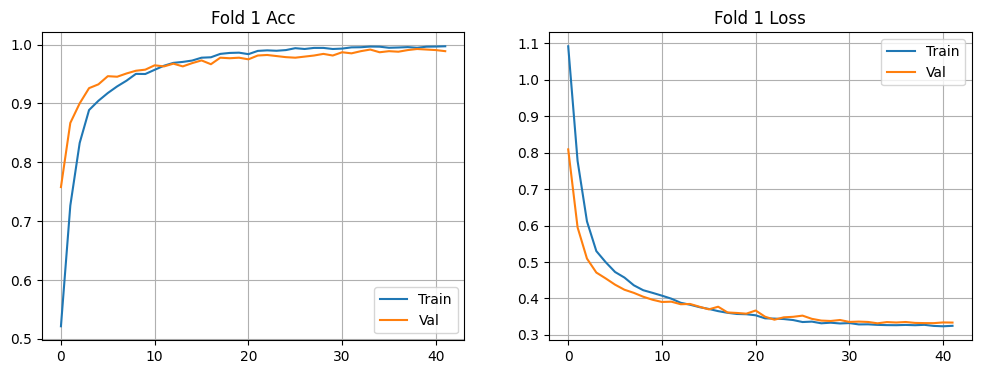

Fold 1 Val Acc: 0.9917 | Test Acc: 0.9834
*** YENİ EN İYİ HYBRID FOLD: 1 (Acc: 0.9917) ***
Hybrid Model ve Metrikler Kaydedildi.

================ HYBRID FOLD 2 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.4159 - loss: 1.2766 - val_accuracy: 0.6987 - val_loss: 0.8806 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.6747 - loss: 0.8435 - val_accuracy: 0.8715 - val_loss: 0.6052 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.8230 - loss: 0.6246 - val_accuracy: 0.9030 - val_loss: 0.5077 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.8856 - loss: 0.5323 - val_accuracy: 0.9187 - val_loss: 0.4648 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.9155 - loss: 0.5028 - val_accuracy: 0.9372 - val_loss: 0.4422 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 

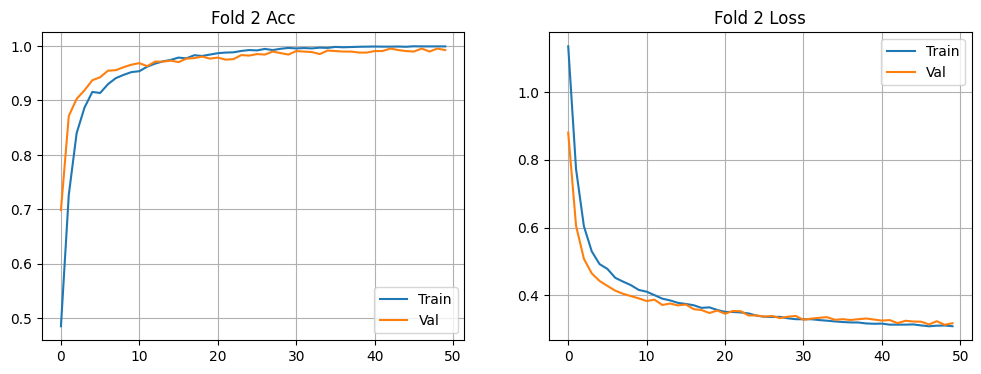

Fold 2 Val Acc: 0.9954 | Test Acc: 0.9917
*** YENİ EN İYİ HYBRID FOLD: 2 (Acc: 0.9954) ***
Hybrid Model ve Metrikler Kaydedildi.

================ HYBRID FOLD 3 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.4473 - loss: 1.2207 - val_accuracy: 0.7726 - val_loss: 0.8388 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.6777 - loss: 0.8510 - val_accuracy: 0.8715 - val_loss: 0.5922 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.8337 - loss: 0.6194 - val_accuracy: 0.9122 - val_loss: 0.4963 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.8738 - loss: 0.5408 - val_accuracy: 0.9224 - val_loss: 0.4643 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.9085 - loss: 0.4952 - val_accuracy: 0.9381 - val_loss: 0.4432 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 

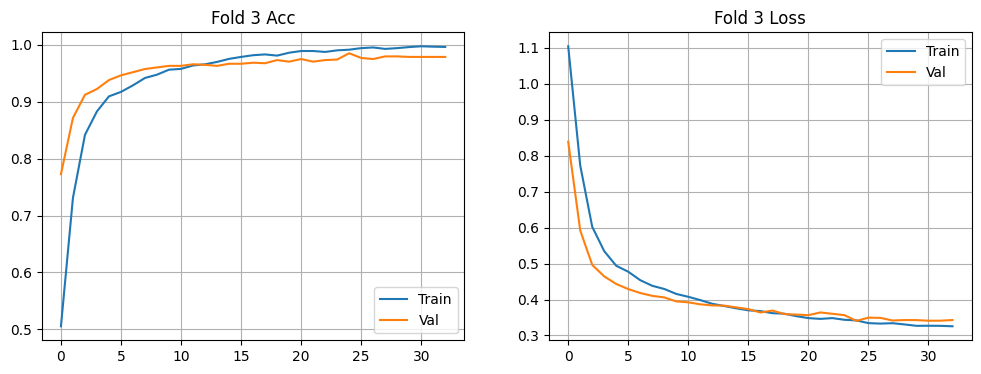

Fold 3 Val Acc: 0.9852 | Test Acc: 0.9801

================ HYBRID FOLD 4 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.3560 - loss: 1.4793 - val_accuracy: 0.6063 - val_loss: 0.9832 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.6051 - loss: 0.9494 - val_accuracy: 0.8494 - val_loss: 0.6527 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.7970 - loss: 0.6715 - val_accuracy: 0.9196 - val_loss: 0.5099 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.8684 - loss: 0.5618 - val_accuracy: 0.9316 - val_loss: 0.4717 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.8950 - loss: 0.5145 - val_accuracy: 0.9381 - val_loss: 0.4486 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.9115 - loss: 0.4887 - val_accuracy: 0.9464 - val_loss: 0.431

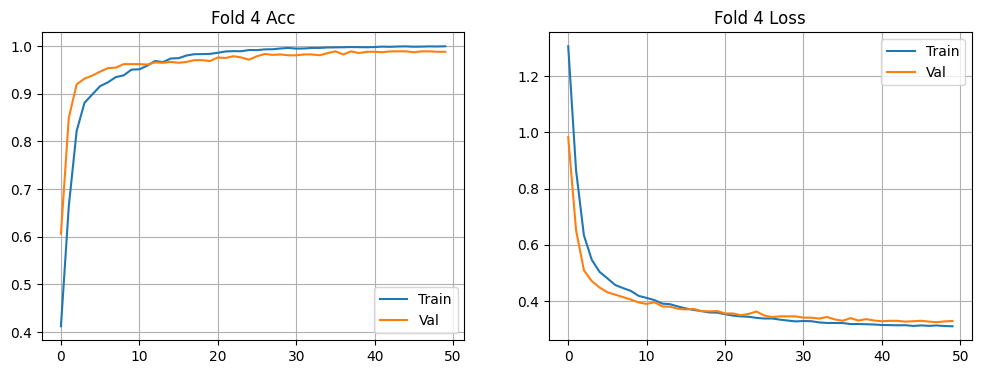

Fold 4 Val Acc: 0.9889 | Test Acc: 0.9867

================ HYBRID FOLD 5 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.3444 - loss: 1.4123 - val_accuracy: 0.6571 - val_loss: 0.9135 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.6418 - loss: 0.9136 - val_accuracy: 0.8530 - val_loss: 0.6204 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.8007 - loss: 0.6680 - val_accuracy: 0.9067 - val_loss: 0.5050 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.8674 - loss: 0.5636 - val_accuracy: 0.9233 - val_loss: 0.4689 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.8964 - loss: 0.5223 - val_accuracy: 0.9390 - val_loss: 0.4434 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.9038 - loss: 0.4981 - val_accuracy: 0.9492 - val_loss: 0.430

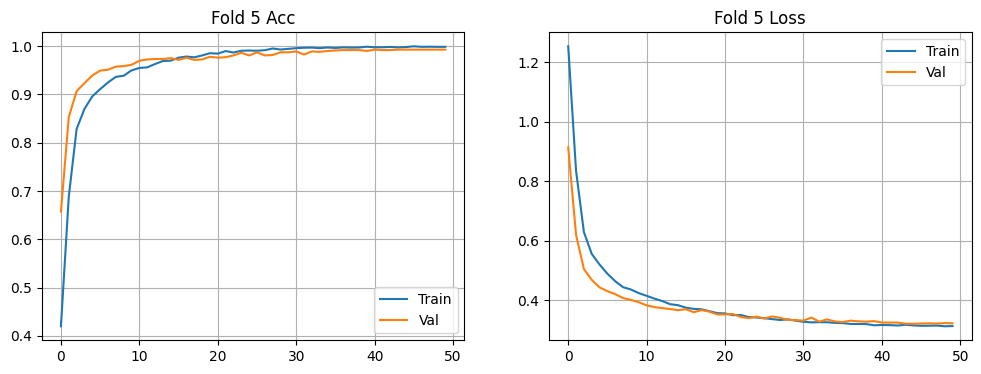

Fold 5 Val Acc: 0.9926 | Test Acc: 0.9850

>>> HYBRID EĞİTİM TAMAMLANDI. En iyi fold: 2


In [ ]:
# =========================================================
# GOOGLE DRIVE BAĞLANTISI
# =========================================================
# Drive bağlantısını sağlıyoruz, verilerimiz ve kayıtlarımız burada.
from google.colab import drive
drive.mount('/content/drive')

# =========================================================
# GEREKLİ KÜTÜPHANELER
# =========================================================
# Veri bilimi ve görselleştirme araçları.
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model metrikleri ve veri bölme işlemleri.
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# Derin öğrenme araçları.
import tensorflow as tf
# İki farklı mimariyi (DenseNet ve EfficientNet) aynı anda kullanacağız.
from tensorflow.keras.applications import DenseNet121, EfficientNetB0
# Modelleri birleştirmek için Concatenate, veri ölçeklemek için Rescaling katmanı şart.
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input, Concatenate, Rescaling
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.keras import mixed_precision, regularizers

# =========================================================
# 🚀 MIXED PRECISION (A100 PERFORMANS AYARI)
# =========================================================
# İki modeli aynı anda belleğe yükleyeceğimiz için float16 kullanarak yer ve hız kazanıyoruz.
mixed_precision.set_global_policy("mixed_float16")

# İşlemci çekirdek ayarları.
tf.config.threading.set_intra_op_parallelism_threads(0)
tf.config.threading.set_inter_op_parallelism_threads(0)

# =========================================================
# AYARLAR VE KLASÖR YOLLARI
# =========================================================
DATASET_PATH = "/content/drive/MyDrive/Projeypy/Brain_Cancer_Clean"

# --- Kayıt Klasörü: Hybrid (Dense Fine-Tuned + Eff Frozen) ---
# Sonuçlar karışmasın diye bu deneye özel klasör açıyoruz.
SAVE_DIR = "/content/drive/MyDrive/Projeypy/Sonuclar/Hybrid_DenseNet_FineTuned_EfficientNet_Frozen"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"📂 Veri Seti Okunuyor: {DATASET_PATH}")
print(f"💾 Sonuçlar Kaydedilecek: {SAVE_DIR}")

IMG_SIZE = 224
BATCH_SIZE = 64 # A100 GPU'su güçlü olduğu için 64 batch size kaldırır.
EPOCHS = 50
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# SINIFLARI VE DOSYALARI LİSTELEME
# =========================================================
class_names = sorted(os.listdir(DATASET_PATH))
class_names = [c for c in class_names
               if os.path.isdir(os.path.join(DATASET_PATH, c))
               and "Sonuclar" not in c
               and not c.startswith('.')]

NUM_CLASSES = len(class_names)

# Resim yollarını alıyoruz.
image_paths, labels = [], []
for i, cls in enumerate(class_names):
    cls_path = os.path.join(DATASET_PATH, cls)
    if not os.path.exists(cls_path): continue
    for img in os.listdir(cls_path):
        if img.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(cls_path, img))
            labels.append(i)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Sınıflar:", class_names)
print("Toplam görüntü:", len(image_paths))

# =========================================================
# TRAIN / TEST BÖLME
# =========================================================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    image_paths, labels,
    test_size=0.10,
    stratify=labels,
    random_state=SEED
)

print("Train+Val:", len(X_trainval), "| Test:", len(X_test))

# =========================================================
# IMAGE LOADER (HAM VERİ - STRATEJİK HAMLE)
# =========================================================
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    # ÖNEMLİ DETAY: Burada veriyi 255'e bölüp 0-1 arasına ÇEKMİYORUZ.
    # Sebebi: EfficientNet 0-255 arası ham veriyi sever, DenseNet ise 0-1 ister.
    # Bu ayrımı modelin içinde "Layer" olarak yapacağız.
    img = tf.cast(img, tf.float32)

    return img, tf.one_hot(label, NUM_CLASSES)

# =========================================================
# VERİ ÇOĞALTMA (AUGMENTATION)
# =========================================================
@tf.function
def augment(img, y):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    big = tf.image.resize(img, (IMG_SIZE + 12, IMG_SIZE + 12))
    img = tf.image.random_crop(big, [IMG_SIZE, IMG_SIZE, 3])
    return img, y

# =========================================================
# TEST VERİ SETİ
# =========================================================
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(load_image)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# =========================================================
# CALLBACKS
# =========================================================
class WarmUpLR(Callback):
    def __init__(self, base_lr=3e-5, warmup_epochs=3):
        super().__init__()
        self.base_lr = base_lr
        self.warmup_epochs = warmup_epochs
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
            self.model.optimizer.learning_rate.assign(lr)

class TimeHistory(Callback):
    def on_train_begin(self, logs={}): self.times = []
    def on_epoch_begin(self, batch, logs={}): self.epoch_time_start = time.time()
    def on_epoch_end(self, batch, logs={}): self.times.append(time.time() - self.epoch_time_start)

# =========================================================
# 🔥 HYBRID MODEL (DENSENET AÇIK + EFFICIENTNET KAPALI) 🔥
# =========================================================
def build_hybrid_model():
    # Ortak Giriş Katmanı (0-255 arası değerler gelir).
    input_tensor = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # --- KOL 1: DENSENET121 (FINE-TUNING YAPILACAK) ---
    # DenseNet 0-1 aralığında çalışır. Bu yüzden sadece bu kola özel bir "Rescaling" katmanı ekliyoruz.
    # Gelen 0-255 verisini 0-1'e dönüştürüp DenseNet'e veriyoruz.
    x_dense_input = Rescaling(1./255)(input_tensor)

    # DenseNet'i yüklüyoruz.

    base_dense = DenseNet121(weights="imagenet", include_top=False, input_tensor=x_dense_input)
    # İsim çakışmasını önlemek için prefix ekliyoruz.
    for layer in base_dense.layers: layer._name = "dense_" + layer.name

    # DenseNet STRATEJİSİ: Fine-Tuning
    # Son 60 katmanı eğitime açıyoruz, gerisini donduruyoruz.
    base_dense.trainable = True
    for layer in base_dense.layers[:-60]:
        layer.trainable = False

    x1 = base_dense.output
    x1 = GlobalAveragePooling2D(name="avg_pool_dense")(x1)

    # --- KOL 2: EFFICIENTNETB0 (FEATURE EXTRACTOR - DONDURULMUŞ) ---
    # EfficientNet, kendi içinde preprocessing katmanına sahiptir, o yüzden ham (0-255) veriyi direkt veriyoruz.

    base_eff = EfficientNetB0(weights="imagenet", include_top=False, input_tensor=input_tensor)
    for layer in base_eff.layers: layer._name = "eff_" + layer.name

    # EfficientNet STRATEJİSİ: Frozen (Dondurulmuş)
    # Bu modelin ağırlıklarına hiç dokunmuyoruz, sadece özellik çıkarıcı olarak kullanıyoruz.
    base_eff.trainable = False

    x2 = base_eff.output
    x2 = GlobalAveragePooling2D(name="avg_pool_eff")(x2)

    # --- BİRLEŞTİRME (FEATURE FUSION) ---
    # DenseNet'ten gelen öğrenilmiş özellikler ile EfficientNet'ten gelen sabit özellikleri birleştiriyoruz.
    merged = Concatenate(name="concat_features")([x1, x2])

    # --- ORTAK KARAR KATMANI ---
    x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(merged)
    x = Dropout(0.5)(x)
    output = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = Model(inputs=input_tensor, outputs=output, name="Hybrid_DenseFT_EffFrozen")

    # Modeli derliyoruz.
    model.compile(
        optimizer=Adam(3e-5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08),
        metrics=["accuracy"]
    )
    return model

# Grafik ve Metrik Kaydetme
def save_plot_metrics(history, y_true, y_pred, y_prob, fold, save_path):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history["accuracy"], label="Train"); plt.plot(history.history["val_accuracy"], label="Val"); plt.title(f"Accuracy ({fold})"); plt.legend(); plt.grid()
    plt.subplot(1, 2, 2); plt.plot(history.history["loss"], label="Train"); plt.plot(history.history["val_loss"], label="Val"); plt.title(f"Loss ({fold})"); plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_loss_acc.png")); plt.close()

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6)); sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Greens"); plt.title(f"CM ({fold})"); plt.savefig(os.path.join(save_path, "best_fold_confusion_matrix.png")); plt.close()

    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    plt.figure(figsize=(7, 6))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--"); plt.title(f"ROC ({fold})"); plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_roc_curve.png")); plt.close()

# =========================================================
# 5-FOLD CROSS VALIDATION
# =========================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
best_val_acc = 0.0
best_fold_index = 0

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    print(f"\n================ HYBRID FOLD {fold} =================")
    X_tr, y_tr = X_trainval[tr_idx], y_trainval[tr_idx]
    X_val, y_val = X_trainval[val_idx], y_trainval[val_idx]

    cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(zip(np.unique(y_tr), cw))

    train_ds = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr)).shuffle(4096).map(load_image).map(augment).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
    val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val)).map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

    model = build_hybrid_model()
    time_callback = TimeHistory()

    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, class_weight=class_weights,
                        callbacks=[WarmUpLR(), EarlyStopping(patience=8, restore_best_weights=True), ReduceLROnPlateau(patience=4, factor=0.3), time_callback], verbose=1)

    # Grafikleri Göster
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history["accuracy"], label="Train"); plt.plot(history.history["val_accuracy"], label="Val"); plt.title(f"Fold {fold} Acc"); plt.legend(); plt.grid()
    plt.subplot(1, 2, 2); plt.plot(history.history["loss"], label="Train"); plt.plot(history.history["val_loss"], label="Val"); plt.title(f"Fold {fold} Loss"); plt.legend(); plt.grid()
    plt.show()

    # Tahminler
    val_prob = model.predict(val_ds, verbose=0)
    val_pred = np.argmax(val_prob, axis=1)
    val_true = np.concatenate([y for x, y in val_ds], axis=0)
    val_true = np.argmax(val_true, axis=1)

    test_prob = model.predict(test_ds, verbose=0)
    test_pred = np.argmax(test_prob, axis=1)

    val_acc = accuracy_score(val_true, val_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print(f"Fold {fold} Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")

    if val_acc > best_val_acc:
        print(f"*** YENİ EN İYİ HYBRID FOLD: {fold} (Acc: {val_acc:.4f}) ***")
        best_val_acc = val_acc
        best_fold_index = fold

        model.save(os.path.join(SAVE_DIR, "best_hybrid_dense_eff.h5"))
        save_plot_metrics(history, y_test, test_pred, test_prob, fold, SAVE_DIR)

        avg_epoch_time = np.mean(time_callback.times)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, test_pred, average='weighted')

        df = pd.DataFrame([{
            "Model": "Hybrid (Dense_FT + Eff_Frozen)", "Best_Fold": fold,
            "Val_Accuracy": val_acc, "Test_Accuracy": test_acc,
            "Precision": precision, "Recall": recall, "F1_Score": f1,
            "Avg_Epoch_Time_Sec": avg_epoch_time
        }])
        df.to_csv(os.path.join(SAVE_DIR, "best_hybrid_metrics.csv"), index=False)
        print("Hybrid Model ve Metrikler Kaydedildi.")

print(f"\n>>> HYBRID EĞİTİM TAMAMLANDI. En iyi fold: {best_fold_index}")

**HYBRİD** Xception ve DenseNet121

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Veri Seti Okunuyor: /content/drive/MyDrive/Projeypy/Brain_Cancer_Clean
💾 Sonuçlar Kaydedilecek: /content/drive/MyDrive/Projeypy/Sonuclar/Hybrid_Xception_DenseNet121_FineTuned
Sınıflar: ['brain_glioma', 'brain_menin', 'brain_tumor']
Toplam görüntü: 6012
Train+Val: 5410 | Test: 602

================ HYBRID FOLD 1 =================
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 572s 6s/step - accuracy: 0.4539 - loss: 1.1862 - val_accuracy: 0.6682 - val_loss: 0.8561 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.7777 - loss: 0.7304 - val_accuracy: 0.8762 - val_loss: 0.5399 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.8986 - loss: 0.5195 - val_accuracy: 0.9335 - val_loss: 0.45

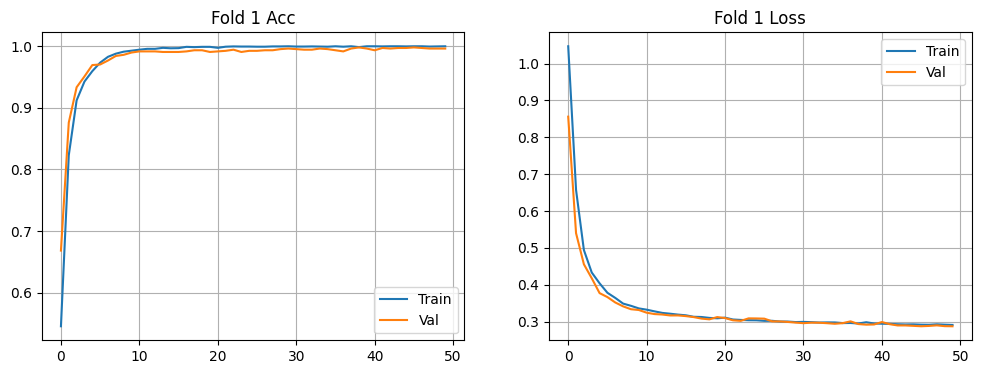

Fold 1 Val Acc: 0.9963 | Test Acc: 0.9934
*** YENİ EN İYİ HYBRID FOLD: 1 (Acc: 0.9963) ***
Hybrid Model ve Metrikler Kaydedildi.

================ HYBRID FOLD 2 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.4405 - loss: 1.1612 - val_accuracy: 0.6830 - val_loss: 0.8170 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.7563 - loss: 0.7305 - val_accuracy: 0.8189 - val_loss: 0.5943 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.9039 - loss: 0.5050 - val_accuracy: 0.9372 - val_loss: 0.4514 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.9376 - loss: 0.4436 - val_accuracy: 0.9713 - val_loss: 0.3824 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9580 - loss: 0.4064 - val_accuracy: 0.9797 - val_loss: 0.3577 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s

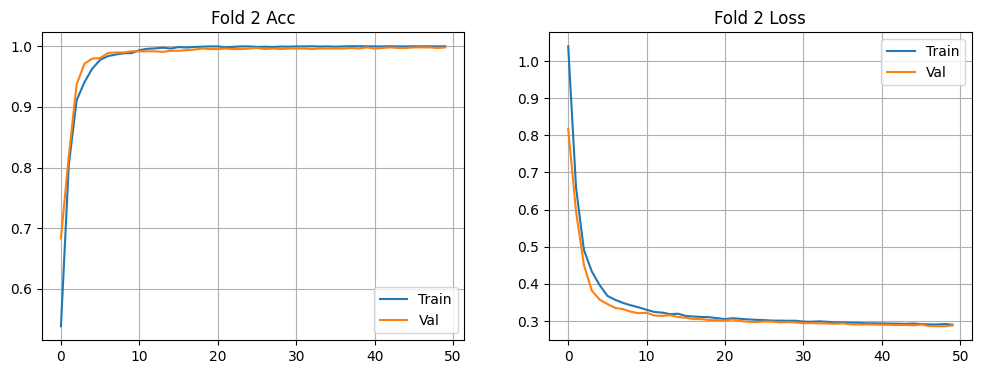

Fold 2 Val Acc: 0.9972 | Test Acc: 0.9934
*** YENİ EN İYİ HYBRID FOLD: 2 (Acc: 0.9972) ***
Hybrid Model ve Metrikler Kaydedildi.

================ HYBRID FOLD 3 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.3980 - loss: 1.2272 - val_accuracy: 0.6867 - val_loss: 0.8107 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.7787 - loss: 0.7273 - val_accuracy: 0.8420 - val_loss: 0.5736 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.9108 - loss: 0.4974 - val_accuracy: 0.9094 - val_loss: 0.4886 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.9492 - loss: 0.4277 - val_accuracy: 0.9529 - val_loss: 0.4046 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.9613 - loss: 0.4001 - val_accuracy: 0.9630 - val_loss: 0.3826 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 

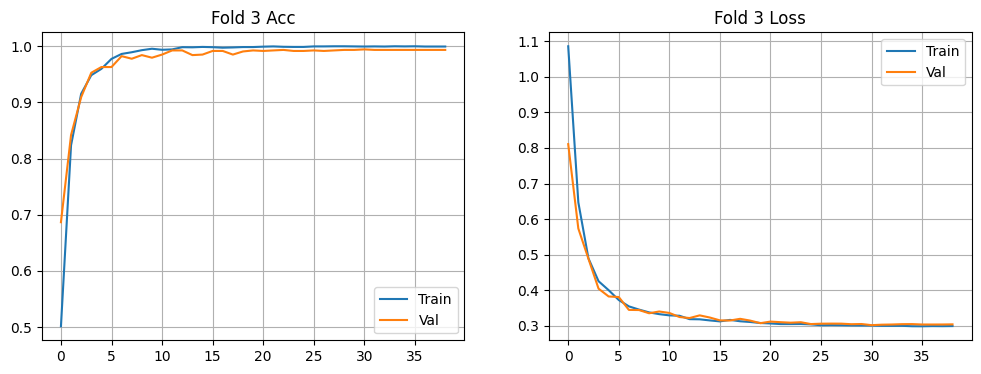

Fold 3 Val Acc: 0.9945 | Test Acc: 0.9900

================ HYBRID FOLD 4 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.4349 - loss: 1.2203 - val_accuracy: 0.6553 - val_loss: 0.8406 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.7567 - loss: 0.7264 - val_accuracy: 0.8383 - val_loss: 0.5988 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.8957 - loss: 0.5254 - val_accuracy: 0.9224 - val_loss: 0.4633 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.9413 - loss: 0.4474 - val_accuracy: 0.9436 - val_loss: 0.4215 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.9627 - loss: 0.4029 - val_accuracy: 0.9640 - val_loss: 0.3838 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.9742 - loss: 0.3751 - val_accuracy: 0.9741 - val_loss: 0.3

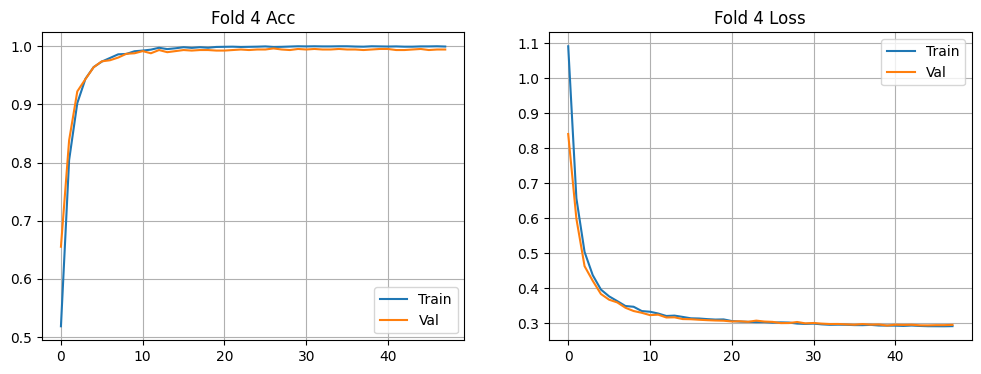

Fold 4 Val Acc: 0.9954 | Test Acc: 0.9917

================ HYBRID FOLD 5 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.4346 - loss: 1.2082 - val_accuracy: 0.5434 - val_loss: 0.9286 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.7724 - loss: 0.7341 - val_accuracy: 0.8031 - val_loss: 0.6422 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.8975 - loss: 0.5108 - val_accuracy: 0.8789 - val_loss: 0.5279 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.9435 - loss: 0.4302 - val_accuracy: 0.9464 - val_loss: 0.4238 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.9633 - loss: 0.3961 - val_accuracy: 0.9658 - val_loss: 0.3819 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.9754 - loss: 0.3714 - val_accuracy: 0.9787 - val_loss: 0.35

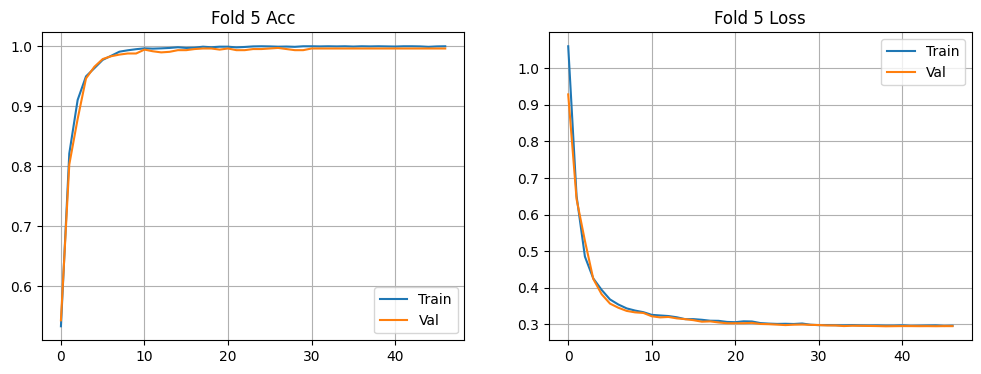

Fold 5 Val Acc: 0.9963 | Test Acc: 0.9900

>>> HYBRID EĞİTİM TAMAMLANDI. En iyi fold: 2


In [ ]:
# =========================================================
# GOOGLE DRIVE BAĞLANTISI
# =========================================================
# Verilerimiz ve kayıt alanımız bulutta olduğu için Drive'ı bağlıyoruz.
from google.colab import drive
drive.mount('/content/drive')

# =========================================================
# GEREKLİ KÜTÜPHANELER
# =========================================================
# Veri işleme, görselleştirme ve metrikler için standart kütüphaneler.
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn: Veriyi bölmek ve performans ölçmek için.
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# Derin Öğrenme Kütüphaneleri
import tensorflow as tf
# --- MODELLER ---
# Bu sefer Xception ve DenseNet121'i aynı anda sahneye çıkarıyoruz.
from tensorflow.keras.applications import Xception, DenseNet121
# Rescaling katmanı burada hayati önem taşıyor (Model içi normalizasyon için).
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input, Concatenate, Rescaling
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.keras import mixed_precision, regularizers

# =========================================================
# 🚀 MIXED PRECISION (A100 PERFORMANS)
# =========================================================
# İki büyük modeli aynı anda çalıştıracağımız için GPU belleğini verimli kullanmak şart.
# Mixed Precision (float16) ile hem hızlanıyoruz hem de bellek tasarrufu yapıyoruz.
mixed_precision.set_global_policy("mixed_float16")

# İşlemci çekirdek ayarları (Varsayılan).
tf.config.threading.set_intra_op_parallelism_threads(0)
tf.config.threading.set_inter_op_parallelism_threads(0)

# =========================================================
# AYARLAR VE KLASÖR YOLLARI
# =========================================================
DATASET_PATH = "/content/drive/MyDrive/Projeypy/Brain_Cancer_Clean"

# --- Kayıt Klasörü: Hybrid (Xception + DenseNet) ---
# Sonuçların karışmaması için bu deneye özel klasör.
SAVE_DIR = "/content/drive/MyDrive/Projeypy/Sonuclar/Hybrid_Xception_DenseNet121_FineTuned"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"📂 Veri Seti Okunuyor: {DATASET_PATH}")
print(f"💾 Sonuçlar Kaydedilecek: {SAVE_DIR}")

IMG_SIZE = 224
BATCH_SIZE = 64 # A100 GPU'su için uygun değer.
EPOCHS = 50
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# SINIFLARI VE DOSYALARI LİSTELEME
# =========================================================
class_names = sorted(os.listdir(DATASET_PATH))
class_names = [c for c in class_names
               if os.path.isdir(os.path.join(DATASET_PATH, c))
               and "Sonuclar" not in c
               and not c.startswith('.')]

NUM_CLASSES = len(class_names)

# Resim yollarını topluyoruz.
image_paths, labels = [], []
for i, cls in enumerate(class_names):
    cls_path = os.path.join(DATASET_PATH, cls)
    if not os.path.exists(cls_path): continue
    for img in os.listdir(cls_path):
        if img.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(cls_path, img))
            labels.append(i)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Sınıflar:", class_names)
print("Toplam görüntü:", len(image_paths))

# =========================================================
# TRAIN / TEST BÖLME
# =========================================================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    image_paths, labels,
    test_size=0.10,
    stratify=labels,
    random_state=SEED
)

print("Train+Val:", len(X_trainval), "| Test:", len(X_test))

# =========================================================
# IMAGE LOADER (STRATEJİK: HAM VERİ YÜKLEME)
# =========================================================
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    # DİKKAT: Burada normalizasyon (255'e bölme) YAPMIYORUZ.
    # Veriyi 0-255 aralığında float32 olarak bırakıyoruz.
    # Çünkü Xception ve DenseNet farklı normalizasyonlar istiyor, bunu modelin içinde yapacağız.
    img = tf.cast(img, tf.float32)

    return img, tf.one_hot(label, NUM_CLASSES)

# =========================================================
# VERİ ÇOĞALTMA (AUGMENTATION)
# =========================================================
@tf.function
def augment(img, y):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    big = tf.image.resize(img, (IMG_SIZE + 12, IMG_SIZE + 12))
    img = tf.image.random_crop(big, [IMG_SIZE, IMG_SIZE, 3])
    return img, y

# =========================================================
# TEST VERİ SETİ
# =========================================================
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(load_image)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# =========================================================
# CALLBACKS (EĞİTİM YARDIMCILARI)
# =========================================================
class WarmUpLR(Callback):
    def __init__(self, base_lr=3e-5, warmup_epochs=3):
        super().__init__()
        self.base_lr = base_lr
        self.warmup_epochs = warmup_epochs
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
            self.model.optimizer.learning_rate.assign(lr)

class TimeHistory(Callback):
    def on_train_begin(self, logs={}): self.times = []
    def on_epoch_begin(self, batch, logs={}): self.epoch_time_start = time.time()
    def on_epoch_end(self, batch, logs={}): self.times.append(time.time() - self.epoch_time_start)

# =========================================================
# 🔥 HYBRID MODEL (XCEPTION + DENSENET) 🔥
# =========================================================
def build_hybrid_model():
    # Ortak Giriş Katmanı (0-255 arası ham piksel değerleri).
    input_tensor = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # --- KOL 1: XCEPTION (-1 ile +1 Aralığı İster) ---

    # Rescaling katmanı ile sadece bu kola giden veriyi dönüştürüyoruz.
    # Formül: (x / 127.5) - 1.0  => 0-255 arası değerler -1 ile 1 arasına sıkışır.
    x_xception_input = Rescaling(scale=1./127.5, offset=-1)(input_tensor)

    base_xception = Xception(weights="imagenet", include_top=False, input_tensor=x_xception_input)
    # İsim çakışmasını önlemek için prefix.
    for layer in base_xception.layers: layer._name = "xcp_" + layer.name

    # Fine-Tuning Stratejisi: Son 60 katman eğitilebilir.
    base_xception.trainable = True
    for layer in base_xception.layers[:-60]:
        layer.trainable = False

    x1 = base_xception.output
    x1 = GlobalAveragePooling2D(name="avg_pool_xception")(x1)

    # --- KOL 2: DENSENET121 (0 ile 1 Aralığı İster) ---

    # DenseNet için farklı bir normalizasyon uyguluyoruz.
    # Formül: x / 255.0 => 0-255 arası değerler 0 ile 1 arasına sıkışır.
    x_dense_input = Rescaling(scale=1./255)(input_tensor)

    base_dense = DenseNet121(weights="imagenet", include_top=False, input_tensor=x_dense_input)
    for layer in base_dense.layers: layer._name = "dense_" + layer.name

    # Fine-Tuning Stratejisi: Son 60 katman eğitilebilir.
    base_dense.trainable = True
    for layer in base_dense.layers[:-60]:
        layer.trainable = False

    x2 = base_dense.output
    x2 = GlobalAveragePooling2D(name="avg_pool_dense")(x2)

    # --- BİRLEŞTİRME (FEATURE FUSION) ---
    # İki modelin ürettiği öznitelik vektörlerini birleştiriyoruz.

    merged = Concatenate(name="concat_features")([x1, x2])

    # --- ORTAK KARAR KATMANI ---
    x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(merged)
    x = Dropout(0.5)(x) # Overfitting önlemi.
    output = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = Model(inputs=input_tensor, outputs=output, name="Hybrid_Xception_DenseNet")

    # Modeli derliyoruz.
    model.compile(
        optimizer=Adam(3e-5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08),
        metrics=["accuracy"]
    )
    return model

# Grafik ve Metrik Kaydetme
def save_plot_metrics(history, y_true, y_pred, y_prob, fold, save_path):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history["accuracy"], label="Train"); plt.plot(history.history["val_accuracy"], label="Val"); plt.title(f"Accuracy ({fold})"); plt.legend(); plt.grid()
    plt.subplot(1, 2, 2); plt.plot(history.history["loss"], label="Train"); plt.plot(history.history["val_loss"], label="Val"); plt.title(f"Loss ({fold})"); plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_loss_acc.png")); plt.close()

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6)); sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Greens"); plt.title(f"CM ({fold})"); plt.savefig(os.path.join(save_path, "best_fold_confusion_matrix.png")); plt.close()

    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    plt.figure(figsize=(7, 6))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--"); plt.title(f"ROC ({fold})"); plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_roc_curve.png")); plt.close()

# =========================================================
# 5-FOLD CROSS VALIDATION
# =========================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
best_val_acc = 0.0
best_fold_index = 0

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    print(f"\n================ HYBRID FOLD {fold} =================")
    X_tr, y_tr = X_trainval[tr_idx], y_trainval[tr_idx]
    X_val, y_val = X_trainval[val_idx], y_trainval[val_idx]

    # Sınıf ağırlıkları (Dengesiz veri setleri için).
    cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(zip(np.unique(y_tr), cw))

    train_ds = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr)).shuffle(4096).map(load_image).map(augment).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
    val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val)).map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

    model = build_hybrid_model()
    time_callback = TimeHistory()

    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, class_weight=class_weights,
                        callbacks=[WarmUpLR(), EarlyStopping(patience=8, restore_best_weights=True), ReduceLROnPlateau(patience=4, factor=0.3), time_callback], verbose=1)

    # Grafikleri Göster
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history["accuracy"], label="Train"); plt.plot(history.history["val_accuracy"], label="Val"); plt.title(f"Fold {fold} Acc"); plt.legend(); plt.grid()
    plt.subplot(1, 2, 2); plt.plot(history.history["loss"], label="Train"); plt.plot(history.history["val_loss"], label="Val"); plt.title(f"Fold {fold} Loss"); plt.legend(); plt.grid()
    plt.show()

    # Tahminler
    val_prob = model.predict(val_ds, verbose=0)
    val_pred = np.argmax(val_prob, axis=1)
    val_true = np.concatenate([y for x, y in val_ds], axis=0)
    val_true = np.argmax(val_true, axis=1)

    test_prob = model.predict(test_ds, verbose=0)
    test_pred = np.argmax(test_prob, axis=1)

    val_acc = accuracy_score(val_true, val_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print(f"Fold {fold} Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")

    if val_acc > best_val_acc:
        print(f"*** YENİ EN İYİ HYBRID FOLD: {fold} (Acc: {val_acc:.4f}) ***")
        best_val_acc = val_acc
        best_fold_index = fold

        model.save(os.path.join(SAVE_DIR, "best_hybrid_xcp_dense_finetuned.h5"))
        save_plot_metrics(history, y_test, test_pred, test_prob, fold, SAVE_DIR)

        avg_epoch_time = np.mean(time_callback.times)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, test_pred, average='weighted')

        df = pd.DataFrame([{
            "Model": "Hybrid (Xception+DenseNet121)", "Best_Fold": fold,
            "Val_Accuracy": val_acc, "Test_Accuracy": test_acc,
            "Precision": precision, "Recall": recall, "F1_Score": f1,
            "Avg_Epoch_Time_Sec": avg_epoch_time
        }])
        df.to_csv(os.path.join(SAVE_DIR, "best_hybrid_metrics.csv"), index=False)
        print("Hybrid Model ve Metrikler Kaydedildi.")

print(f"\n>>> HYBRID EĞİTİM TAMAMLANDI. En iyi fold: {best_fold_index}")

**HYBRİD** InceptionV3 ve DenseNet121

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Veri Seti Okunuyor: /content/drive/MyDrive/Projeypy/Brain_Cancer_Clean
💾 Sonuçlar Kaydedilecek: /content/drive/MyDrive/Projeypy/Sonuclar/Hybrid_DenseNet121_InceptionV3_FineTuned
Sınıflar: ['brain_glioma', 'brain_menin', 'brain_tumor']
Toplam görüntü: 6012
Train+Val: 5410 | Test: 602

================ HYBRID FOLD 1 =================
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 519s 6s/step - accuracy: 0.4560 - loss: 1.2076 - val_accuracy: 0.7874 - val_loss: 0.6954 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.7982 - loss: 0.6792 - val_accuracy: 0.8336 - val_loss: 0.5857 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.8882 - loss: 0.5332 - val_accuracy: 0.9113 - val_loss: 

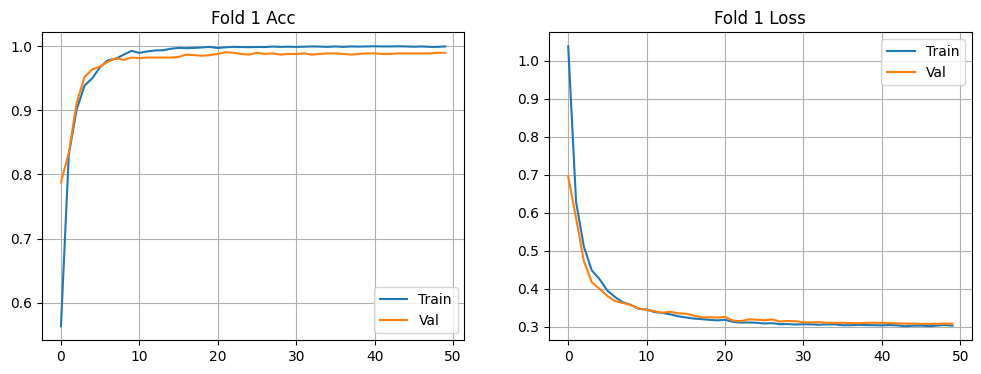

Fold 1 Val Acc: 0.9889 | Test Acc: 0.9834
*** YENİ EN İYİ HYBRID FOLD: 1 (Acc: 0.9889) ***
Hybrid Model ve Metrikler Kaydedildi.

================ HYBRID FOLD 2 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.5128 - loss: 1.0847 - val_accuracy: 0.7329 - val_loss: 0.7451 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.8073 - loss: 0.6631 - val_accuracy: 0.8466 - val_loss: 0.5769 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.9003 - loss: 0.5104 - val_accuracy: 0.9085 - val_loss: 0.4886 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9268 - loss: 0.4603 - val_accuracy: 0.9529 - val_loss: 0.4081 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.9448 - loss: 0.4283 - val_accuracy: 0.9649 - val_loss: 0.3861 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 

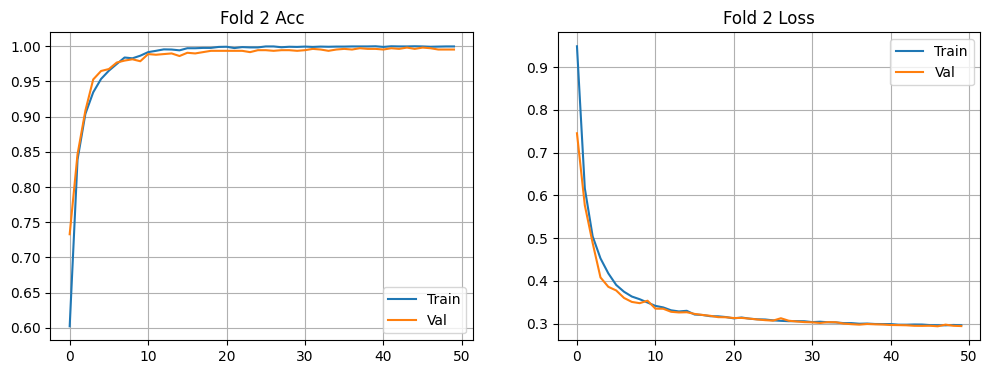

Fold 2 Val Acc: 0.9972 | Test Acc: 0.9900
*** YENİ EN İYİ HYBRID FOLD: 2 (Acc: 0.9972) ***
Hybrid Model ve Metrikler Kaydedildi.

================ HYBRID FOLD 3 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.4815 - loss: 1.1619 - val_accuracy: 0.7893 - val_loss: 0.6778 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.8069 - loss: 0.6713 - val_accuracy: 0.8835 - val_loss: 0.5379 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.8872 - loss: 0.5226 - val_accuracy: 0.9233 - val_loss: 0.4745 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.9285 - loss: 0.4558 - val_accuracy: 0.9464 - val_loss: 0.4297 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9522 - loss: 0.4153 - val_accuracy: 0.9575 - val_loss: 0.3944 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 

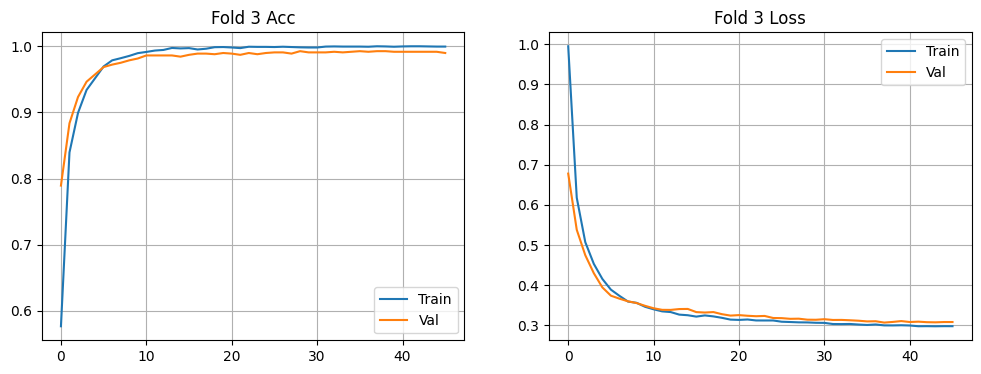

Fold 3 Val Acc: 0.9926 | Test Acc: 0.9884

================ HYBRID FOLD 4 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.4826 - loss: 1.2154 - val_accuracy: 0.7726 - val_loss: 0.6961 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.7964 - loss: 0.6783 - val_accuracy: 0.8660 - val_loss: 0.5587 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.8938 - loss: 0.5170 - val_accuracy: 0.9233 - val_loss: 0.4728 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.9324 - loss: 0.4516 - val_accuracy: 0.9445 - val_loss: 0.4246 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.9547 - loss: 0.4230 - val_accuracy: 0.9603 - val_loss: 0.3955 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9667 - loss: 0.3972 - val_accuracy: 0.9612 - val_loss: 0.382

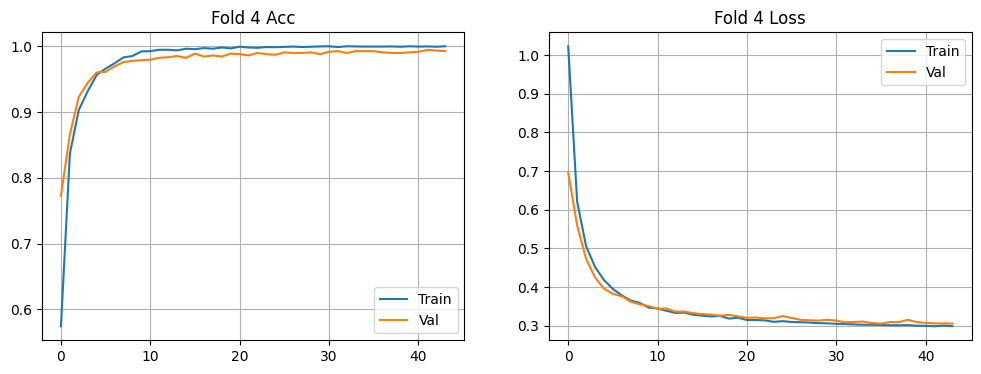

Fold 4 Val Acc: 0.9926 | Test Acc: 0.9867

================ HYBRID FOLD 5 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.4716 - loss: 1.1729 - val_accuracy: 0.8346 - val_loss: 0.6566 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.8013 - loss: 0.6731 - val_accuracy: 0.9159 - val_loss: 0.4877 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.8829 - loss: 0.5286 - val_accuracy: 0.9409 - val_loss: 0.4440 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.9336 - loss: 0.4513 - val_accuracy: 0.9510 - val_loss: 0.4150 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.9501 - loss: 0.4209 - val_accuracy: 0.9621 - val_loss: 0.3927 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.9598 - loss: 0.3983 - val_accuracy: 0.9621 - val_loss: 0.3861 

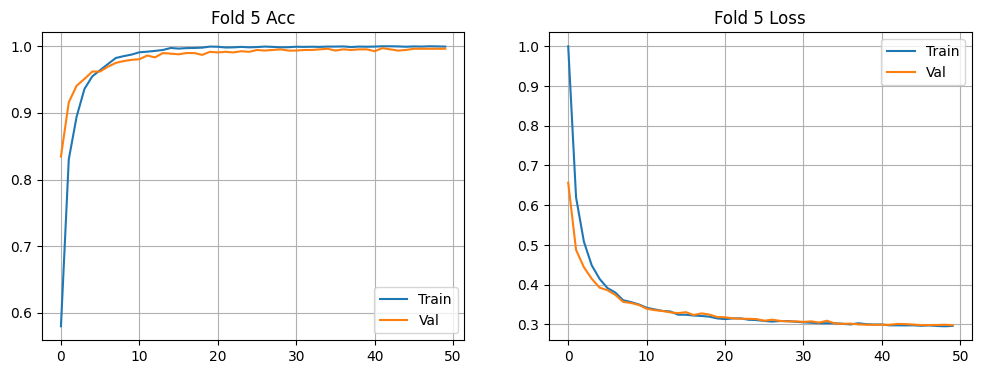

Fold 5 Val Acc: 0.9963 | Test Acc: 0.9850

>>> HYBRID EĞİTİM TAMAMLANDI. En iyi fold: 2


In [ ]:
# =========================================================
# GOOGLE DRIVE BAĞLANTISI
# =========================================================
# Verilerimiz bulutta, bu yüzden Drive'ı bağlıyoruz.
from google.colab import drive
drive.mount('/content/drive')

# =========================================================
# GEREKLİ KÜTÜPHANELER
# =========================================================
# Veri işleme, görselleştirme ve metrikler.
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn araçları.
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# Derin Öğrenme Kütüphaneleri
import tensorflow as tf
# --- MODELLER DEĞİŞTİ: DenseNet121 ve InceptionV3 ---
# Bu sefer DenseNet (Derinlik) ve Inception (Genişlik) güçlerini birleştiriyoruz.
from tensorflow.keras.applications import DenseNet121, InceptionV3
# Model içi normalizasyon için Rescaling, birleştirme için Concatenate.
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input, Concatenate, Rescaling
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.keras import mixed_precision, regularizers

# =========================================================
# 🚀 MIXED PRECISION (A100 PERFORMANS)
# =========================================================
# İki büyük modeli aynı anda eğiteceğimiz için GPU belleğini verimli kullanıyoruz.
mixed_precision.set_global_policy("mixed_float16")

# İşlemci çekirdek ayarları.
tf.config.threading.set_intra_op_parallelism_threads(0)
tf.config.threading.set_inter_op_parallelism_threads(0)

# =========================================================
# AYARLAR VE KLASÖR YOLLARI
# =========================================================
DATASET_PATH = "/content/drive/MyDrive/Projeypy/Brain_Cancer_Clean"

# --- Kayıt Klasörü: Hybrid (DenseNet + Inception) ---
# Sonuçlar karışmasın diye özel klasör.
SAVE_DIR = "/content/drive/MyDrive/Projeypy/Sonuclar/Hybrid_DenseNet121_InceptionV3_FineTuned"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"📂 Veri Seti Okunuyor: {DATASET_PATH}")
print(f"💾 Sonuçlar Kaydedilecek: {SAVE_DIR}")

IMG_SIZE = 224
BATCH_SIZE = 64 # A100 GPU gücüyle 64 batch size.
EPOCHS = 50
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# SINIFLARI VE DOSYALARI LİSTELEME
# =========================================================
class_names = sorted(os.listdir(DATASET_PATH))
class_names = [c for c in class_names
               if os.path.isdir(os.path.join(DATASET_PATH, c))
               and "Sonuclar" not in c
               and not c.startswith('.')]

NUM_CLASSES = len(class_names)

# Resim yollarını topluyoruz.
image_paths, labels = [], []
for i, cls in enumerate(class_names):
    cls_path = os.path.join(DATASET_PATH, cls)
    if not os.path.exists(cls_path): continue
    for img in os.listdir(cls_path):
        if img.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(cls_path, img))
            labels.append(i)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Sınıflar:", class_names)
print("Toplam görüntü:", len(image_paths))

# =========================================================
# TRAIN / TEST BÖLME
# =========================================================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    image_paths, labels,
    test_size=0.10,
    stratify=labels,
    random_state=SEED
)

print("Train+Val:", len(X_trainval), "| Test:", len(X_test))

# =========================================================
# IMAGE LOADER (HAM VERİ - MODEL İÇİNDE İŞLENECEK)
# =========================================================
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    # Normalizasyon yapmıyoruz (0-255 aralığında bırakıyoruz).
    # Çünkü DenseNet ve Inception farklı aralıklar istiyor.
    img = tf.cast(img, tf.float32)

    return img, tf.one_hot(label, NUM_CLASSES)

# =========================================================
# VERİ ÇOĞALTMA (AUGMENTATION)
# =========================================================
@tf.function
def augment(img, y):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    big = tf.image.resize(img, (IMG_SIZE + 12, IMG_SIZE + 12))
    img = tf.image.random_crop(big, [IMG_SIZE, IMG_SIZE, 3])
    return img, y

# =========================================================
# TEST VERİ SETİ
# =========================================================
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(load_image)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# =========================================================
# CALLBACKS
# =========================================================
class WarmUpLR(Callback):
    def __init__(self, base_lr=3e-5, warmup_epochs=3):
        super().__init__()
        self.base_lr = base_lr
        self.warmup_epochs = warmup_epochs
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
            self.model.optimizer.learning_rate.assign(lr)

class TimeHistory(Callback):
    def on_train_begin(self, logs={}): self.times = []
    def on_epoch_begin(self, batch, logs={}): self.epoch_time_start = time.time()
    def on_epoch_end(self, batch, logs={}): self.times.append(time.time() - self.epoch_time_start)

# =========================================================
# 🔥 HYBRID MODEL (DENSENET121 + INCEPTIONV3) 🔥
# =========================================================
def build_hybrid_model():
    # Ortak Giriş Katmanı (0-255 arası ham veri).
    input_tensor = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # --- KOL 1: DENSENET121 (0 ile 1 Aralığı İster) ---

    # Rescaling ile 0-255 verisini 0-1 aralığına çekiyoruz.
    x_dense_input = Rescaling(scale=1./255)(input_tensor)

    base_dense = DenseNet121(weights="imagenet", include_top=False, input_tensor=x_dense_input)
    # İsim çakışmasını önlemek için prefix.
    for layer in base_dense.layers: layer._name = "dense_" + layer.name

    # Fine-Tuning: Son 60 katmanı açıyoruz.
    base_dense.trainable = True
    for layer in base_dense.layers[:-60]:
        layer.trainable = False

    x1 = base_dense.output
    x1 = GlobalAveragePooling2D(name="avg_pool_dense")(x1)

    # --- KOL 2: INCEPTIONV3 (-1 ile +1 Aralığı İster) ---

    # Rescaling ile 0-255 verisini -1 ile 1 aralığına çekiyoruz.
    x_inc_input = Rescaling(scale=1./127.5, offset=-1)(input_tensor)

    base_inc = InceptionV3(weights="imagenet", include_top=False, input_tensor=x_inc_input)
    # İsim çakışmasını önlemek için prefix.
    for layer in base_inc.layers: layer._name = "inc_" + layer.name

    # Fine-Tuning: Son 60 katmanı açıyoruz.
    base_inc.trainable = True
    for layer in base_inc.layers[:-60]:
        layer.trainable = False

    x2 = base_inc.output
    x2 = GlobalAveragePooling2D(name="avg_pool_inception")(x2)

    # --- BİRLEŞTİRME (FEATURE FUSION) ---
    # İki modelin gördüğü özellikleri bir araya getiriyoruz.

    merged = Concatenate(name="concat_features")([x1, x2])

    # --- ORTAK KARAR KATMANI ---
    x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(merged)
    x = Dropout(0.5)(x)
    output = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = Model(inputs=input_tensor, outputs=output, name="Hybrid_DenseNet_Inception")

    # Modeli derliyoruz.
    model.compile(
        optimizer=Adam(3e-5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08),
        metrics=["accuracy"]
    )
    return model

# Grafik ve Metrik Kaydetme
def save_plot_metrics(history, y_true, y_pred, y_prob, fold, save_path):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history["accuracy"], label="Train"); plt.plot(history.history["val_accuracy"], label="Val"); plt.title(f"Accuracy ({fold})"); plt.legend(); plt.grid()
    plt.subplot(1, 2, 2); plt.plot(history.history["loss"], label="Train"); plt.plot(history.history["val_loss"], label="Val"); plt.title(f"Loss ({fold})"); plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_loss_acc.png")); plt.close()

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6)); sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Greens"); plt.title(f"CM ({fold})"); plt.savefig(os.path.join(save_path, "best_fold_confusion_matrix.png")); plt.close()

    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    plt.figure(figsize=(7, 6))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--"); plt.title(f"ROC ({fold})"); plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_roc_curve.png")); plt.close()

# =========================================================
# 5-FOLD CROSS VALIDATION
# =========================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
best_val_acc = 0.0
best_fold_index = 0

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    print(f"\n================ HYBRID FOLD {fold} =================")
    X_tr, y_tr = X_trainval[tr_idx], y_trainval[tr_idx]
    X_val, y_val = X_trainval[val_idx], y_trainval[val_idx]

    # Sınıf ağırlıkları (Dengesiz veri setleri için).
    cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(zip(np.unique(y_tr), cw))

    train_ds = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr)).shuffle(4096).map(load_image).map(augment).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
    val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val)).map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

    model = build_hybrid_model()
    time_callback = TimeHistory()

    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, class_weight=class_weights,
                        callbacks=[WarmUpLR(), EarlyStopping(patience=8, restore_best_weights=True), ReduceLROnPlateau(patience=4, factor=0.3), time_callback], verbose=1)

    # Grafikleri Göster
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history["accuracy"], label="Train"); plt.plot(history.history["val_accuracy"], label="Val"); plt.title(f"Fold {fold} Acc"); plt.legend(); plt.grid()
    plt.subplot(1, 2, 2); plt.plot(history.history["loss"], label="Train"); plt.plot(history.history["val_loss"], label="Val"); plt.title(f"Fold {fold} Loss"); plt.legend(); plt.grid()
    plt.show()

    # Tahminler
    val_prob = model.predict(val_ds, verbose=0)
    val_pred = np.argmax(val_prob, axis=1)
    val_true = np.concatenate([y for x, y in val_ds], axis=0)
    val_true = np.argmax(val_true, axis=1)

    test_prob = model.predict(test_ds, verbose=0)
    test_pred = np.argmax(test_prob, axis=1)

    val_acc = accuracy_score(val_true, val_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print(f"Fold {fold} Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")

    if val_acc > best_val_acc:
        print(f"*** YENİ EN İYİ HYBRID FOLD: {fold} (Acc: {val_acc:.4f}) ***")
        best_val_acc = val_acc
        best_fold_index = fold

        model.save(os.path.join(SAVE_DIR, "best_hybrid_dense_inception_finetuned.h5"))
        save_plot_metrics(history, y_test, test_pred, test_prob, fold, SAVE_DIR)

        avg_epoch_time = np.mean(time_callback.times)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, test_pred, average='weighted')

        df = pd.DataFrame([{
            "Model": "Hybrid (DenseNet121+InceptionV3)", "Best_Fold": fold,
            "Val_Accuracy": val_acc, "Test_Accuracy": test_acc,
            "Precision": precision, "Recall": recall, "F1_Score": f1,
            "Avg_Epoch_Time_Sec": avg_epoch_time
        }])
        df.to_csv(os.path.join(SAVE_DIR, "best_hybrid_metrics.csv"), index=False)
        print("Hybrid Model ve Metrikler Kaydedildi.")

print(f"\n>>> HYBRID EĞİTİM TAMAMLANDI. En iyi fold: {best_fold_index}")

**HYBRİD** InceptionV3+Xception+DenseNet121

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Veri Seti Okunuyor: /content/drive/MyDrive/Projeypy/Brain_Cancer_Clean
💾 Sonuçlar Kaydedilecek: /content/drive/MyDrive/Projeypy/Sonuclar/Hybrid_Triple_Dense_Xcp_Inc_FineTuned
Sınıflar: ['brain_glioma', 'brain_menin', 'brain_tumor']
Toplam görüntü: 6012
Train+Val: 5410 | Test: 602

================ 3'LÜ HYBRID FOLD 1 =================
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 417s 4s/step - accuracy: 0.5310 - loss: 1.0604 - val_accuracy: 0.8216 - val_loss: 0.6352 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.8414 - loss: 0.6185 - val_accuracy: 0.8244 - val_loss: 0.6041 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.9175 - loss: 0.4829 - val_accuracy: 0.9094 - val_loss: 0.4876 - learning_rate: 3.0000e-05
Epoch 4/50
68

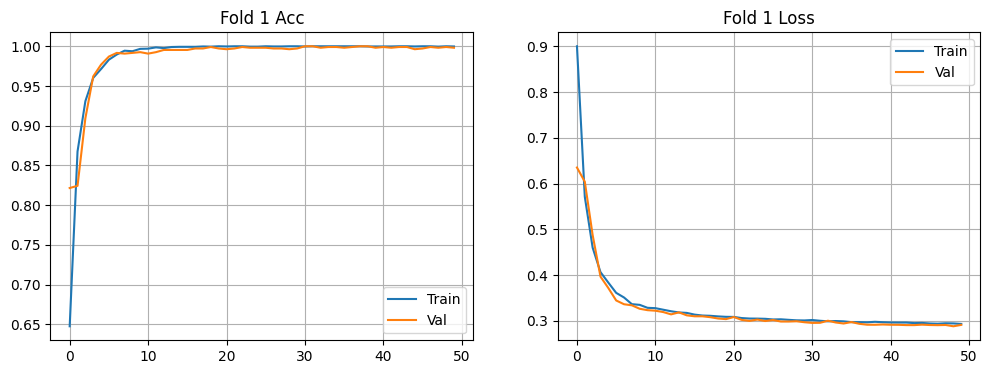

Fold 1 Val Acc: 0.9991 | Test Acc: 0.9967
*** YENİ EN İYİ 3'LÜ HYBRID FOLD: 1 (Acc: 0.9991) ***
3'lü Hybrid Model ve Metrikler Kaydedildi.

================ 3'LÜ HYBRID FOLD 2 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 294s 3s/step - accuracy: 0.5149 - loss: 1.0462 - val_accuracy: 0.7985 - val_loss: 0.6562 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.8328 - loss: 0.6199 - val_accuracy: 0.8364 - val_loss: 0.5813 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.9223 - loss: 0.4740 - val_accuracy: 0.9020 - val_loss: 0.4902 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 144ms/step - accuracy: 0.9529 - loss: 0.4216 - val_accuracy: 0.9640 - val_loss: 0.3920 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.9672 - loss: 0.3922 - val_accuracy: 0.9778 - val_loss: 0.3641 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━

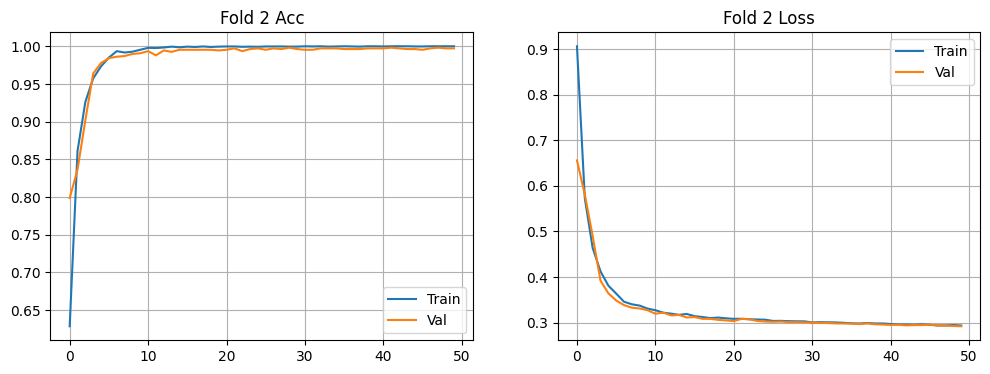

Fold 2 Val Acc: 0.9972 | Test Acc: 0.9934

================ 3'LÜ HYBRID FOLD 3 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 293s 3s/step - accuracy: 0.4840 - loss: 1.1696 - val_accuracy: 0.6793 - val_loss: 0.8178 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.8299 - loss: 0.6337 - val_accuracy: 0.7828 - val_loss: 0.7124 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.9281 - loss: 0.4658 - val_accuracy: 0.8521 - val_loss: 0.6030 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.9540 - loss: 0.4231 - val_accuracy: 0.9094 - val_loss: 0.5201 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.9740 - loss: 0.3760 - val_accuracy: 0.9640 - val_loss: 0.3955 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.9859 - loss: 0.3626 - val_accuracy: 0.9787 - val_loss

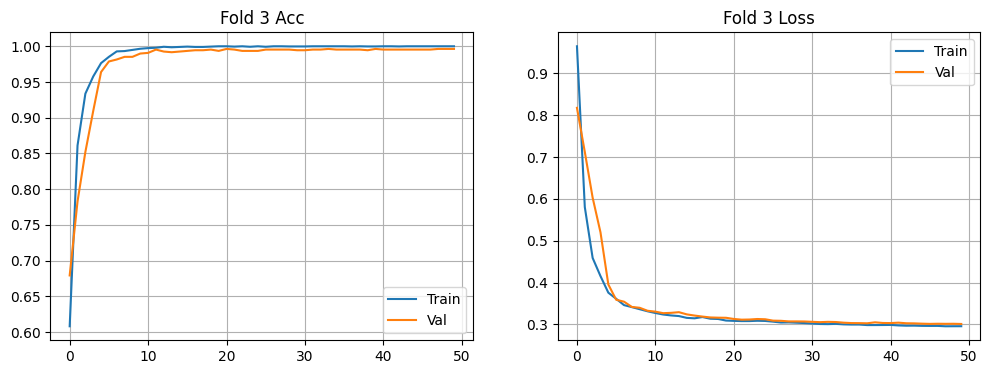

Fold 3 Val Acc: 0.9963 | Test Acc: 0.9950

================ 3'LÜ HYBRID FOLD 4 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 294s 3s/step - accuracy: 0.5001 - loss: 1.0850 - val_accuracy: 0.8346 - val_loss: 0.6326 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.8451 - loss: 0.6021 - val_accuracy: 0.9159 - val_loss: 0.4914 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.9133 - loss: 0.4800 - val_accuracy: 0.9538 - val_loss: 0.4233 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.9538 - loss: 0.4212 - val_accuracy: 0.9630 - val_loss: 0.3990 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.9723 - loss: 0.3875 - val_accuracy: 0.9741 - val_loss: 0.3714 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.9845 - loss: 0.3659 - val_accuracy: 0.9797 - val_loss

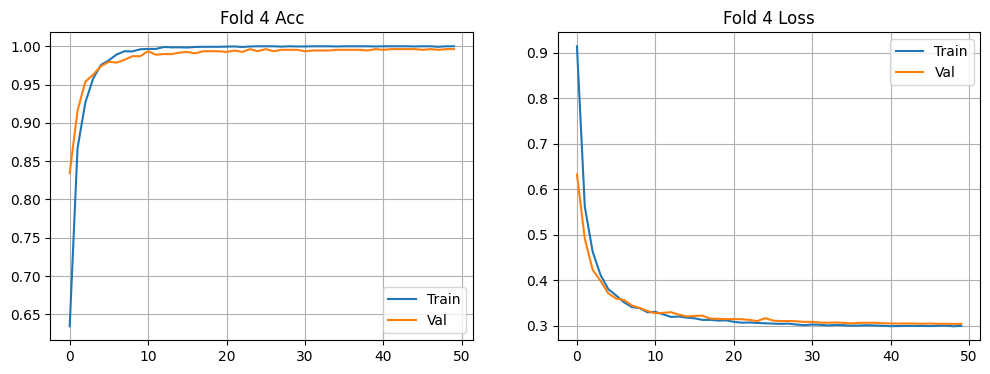

Fold 4 Val Acc: 0.9963 | Test Acc: 0.9900

================ 3'LÜ HYBRID FOLD 5 =================
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - accuracy: 0.4831 - loss: 1.1185 - val_accuracy: 0.6599 - val_loss: 0.8286 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.8301 - loss: 0.6220 - val_accuracy: 0.8623 - val_loss: 0.5733 - learning_rate: 2.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.9047 - loss: 0.4931 - val_accuracy: 0.9140 - val_loss: 0.4935 - learning_rate: 3.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.9509 - loss: 0.4265 - val_accuracy: 0.9473 - val_loss: 0.4271 - learning_rate: 3.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.9649 - loss: 0.3888 - val_accuracy: 0.9667 - val_loss: 0.3901 - learning_rate: 3.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.9825 - loss: 0.3659 - val_accuracy: 0.9778 - val_loss

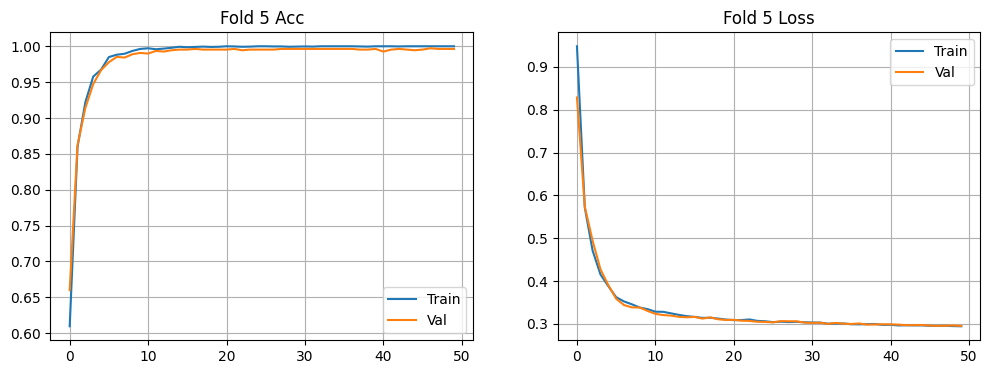

Fold 5 Val Acc: 0.9963 | Test Acc: 0.9867

>>> 3'LÜ HYBRID EĞİTİM TAMAMLANDI. En iyi fold: 1


In [ ]:
# =========================================================
# GOOGLE DRIVE BAĞLANTISI
# =========================================================
# Verilerimiz bulutta, bu yüzden Drive'ı sisteme bağlıyoruz.
from google.colab import drive
drive.mount('/content/drive')

# =========================================================
# GEREKLİ KÜTÜPHANELER
# =========================================================
# Standart veri bilimi kütüphaneleri.
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model değerlendirme ve veri bölme araçları.
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# Derin Öğrenme Kütüphaneleri (TensorFlow/Keras)
import tensorflow as tf
# --- 3 DEV MODEL ÇAĞRILIYOR ---
# DenseNet, Xception ve InceptionV3'ü aynı anda sahneye alıyoruz.
from tensorflow.keras.applications import DenseNet121, Xception, InceptionV3
# Rescaling katmanı burada hayati önem taşıyor, çünkü her modelin veri isteği farklı.
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input, Concatenate, Rescaling
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.keras import mixed_precision, regularizers

# =========================================================
# 🚀 MIXED PRECISION (A100 İÇİN HAYATİ ÖNEMLİ)
# =========================================================
# 3 modeli aynı anda belleğe sığdırmak zor iştir.
# Mixed Precision (float16) kullanarak bellek kullanımını yarıya indirip hızı artırıyoruz.
mixed_precision.set_global_policy("mixed_float16")

# İşlemci çekirdek ayarları.
tf.config.threading.set_intra_op_parallelism_threads(0)
tf.config.threading.set_inter_op_parallelism_threads(0)

# =========================================================
# AYARLAR VE KLASÖR YOLLARI
# =========================================================
DATASET_PATH = "/content/drive/MyDrive/Projeypy/Brain_Cancer_Clean"

# --- Kayıt Klasörü: 3'lü Hybrid ---
# Bu özel "Triple Threat" (Üçlü Tehdit) modelin sonuçları için ayrı klasör.
SAVE_DIR = "/content/drive/MyDrive/Projeypy/Sonuclar/Hybrid_Triple_Dense_Xcp_Inc_FineTuned"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"📂 Veri Seti Okunuyor: {DATASET_PATH}")
print(f"💾 Sonuçlar Kaydedilecek: {SAVE_DIR}")

IMG_SIZE = 224
BATCH_SIZE = 64 # A100 GPU'su bu yükü kaldırabilir (Bellek hatası alırsan 32'ye düşür).
EPOCHS = 50
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# SINIFLARI VE DOSYALARI LİSTELEME
# =========================================================
class_names = sorted(os.listdir(DATASET_PATH))
class_names = [c for c in class_names
               if os.path.isdir(os.path.join(DATASET_PATH, c))
               and "Sonuclar" not in c
               and not c.startswith('.')]

NUM_CLASSES = len(class_names)

# Resim yollarını topluyoruz.
image_paths, labels = [], []
for i, cls in enumerate(class_names):
    cls_path = os.path.join(DATASET_PATH, cls)
    if not os.path.exists(cls_path): continue
    for img in os.listdir(cls_path):
        if img.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(cls_path, img))
            labels.append(i)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Sınıflar:", class_names)
print("Toplam görüntü:", len(image_paths))

# =========================================================
# TRAIN / TEST BÖLME
# =========================================================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    image_paths, labels,
    test_size=0.10,
    stratify=labels,
    random_state=SEED
)

print("Train+Val:", len(X_trainval), "| Test:", len(X_test))

# =========================================================
# IMAGE LOADER (HAM 0-255 - STRATEJİK YAKLAŞIM)
# =========================================================
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    # DİKKAT: Veriyi burada normalleştirmeyip (bölmeyip) ham (0-255) bırakıyoruz.
    # Çünkü 3 modelin istekleri farklı. Dağıtımı modelin girişinde yapacağız.
    img = tf.cast(img, tf.float32)

    return img, tf.one_hot(label, NUM_CLASSES)

# =========================================================
# VERİ ÇOĞALTMA (AUGMENTATION)
# =========================================================
@tf.function
def augment(img, y):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    big = tf.image.resize(img, (IMG_SIZE + 12, IMG_SIZE + 12))
    img = tf.image.random_crop(big, [IMG_SIZE, IMG_SIZE, 3])
    return img, y

# =========================================================
# TEST VERİ SETİ
# =========================================================
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(load_image)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# =========================================================
# CALLBACKS (EĞİTİM YARDIMCILARI)
# =========================================================
class WarmUpLR(Callback):
    def __init__(self, base_lr=3e-5, warmup_epochs=3):
        super().__init__()
        self.base_lr = base_lr
        self.warmup_epochs = warmup_epochs
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
            self.model.optimizer.learning_rate.assign(lr)

class TimeHistory(Callback):
    def on_train_begin(self, logs={}): self.times = []
    def on_epoch_begin(self, batch, logs={}): self.epoch_time_start = time.time()
    def on_epoch_end(self, batch, logs={}): self.times.append(time.time() - self.epoch_time_start)

# =========================================================
# 🔥 3'LÜ HYBRID MODEL (TRIPLE THREAT) 🔥
# =========================================================
def build_hybrid_model():
    # Ortak Giriş Kapısı (0-255 arası ham piksel verisi).
    input_tensor = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # --- 1. DAL: DENSENET121 (0-1 Aralığı İster) ---

    # Girişi (x / 255.0) yaparak 0-1 aralığına sıkıştırıyoruz.
    x_dense = Rescaling(1./255)(input_tensor)

    base_dense = DenseNet121(weights="imagenet", include_top=False, input_tensor=x_dense)
    for layer in base_dense.layers: layer._name = "dense_" + layer.name

    # Fine-Tuning: Son 60 katman eğitilebilir.
    base_dense.trainable = True
    for layer in base_dense.layers[:-60]:
        layer.trainable = False

    out1 = GlobalAveragePooling2D(name="pool_dense")(base_dense.output)

    # --- 2. DAL: XCEPTION (-1 ile +1 Aralığı İster) ---

    # Girişi (x / 127.5) - 1.0 yaparak -1 ile +1 aralığına çekiyoruz.
    x_xcp = Rescaling(scale=1./127.5, offset=-1)(input_tensor)

    base_xcp = Xception(weights="imagenet", include_top=False, input_tensor=x_xcp)
    for layer in base_xcp.layers: layer._name = "xcp_" + layer.name

    # Fine-Tuning: Son 60 katman eğitilebilir.
    base_xcp.trainable = True
    for layer in base_xcp.layers[:-60]:
        layer.trainable = False

    out2 = GlobalAveragePooling2D(name="pool_xcp")(base_xcp.output)

    # --- 3. DAL: INCEPTIONV3 (-1 ile +1 Aralığı İster) ---

    # Girişi (x / 127.5) - 1.0 yaparak -1 ile +1 aralığına çekiyoruz.
    x_inc = Rescaling(scale=1./127.5, offset=-1)(input_tensor)

    base_inc = InceptionV3(weights="imagenet", include_top=False, input_tensor=x_inc)
    for layer in base_inc.layers: layer._name = "inc_" + layer.name

    # Fine-Tuning: Son 60 katman eğitilebilir.
    base_inc.trainable = True
    for layer in base_inc.layers[:-60]:
        layer.trainable = False

    out3 = GlobalAveragePooling2D(name="pool_inc")(base_inc.output)

    # --- BİRLEŞTİRME (3 MODELİN GÜCÜ) ---
    # 3 farklı modelden gelen zengin öznitelikleri (feature vectors) birleştiriyoruz.


[Image of ensemble learning architecture]

    merged = Concatenate(name="concat_triple")([out1, out2, out3])

    # --- KARAR MEKANİZMASI ---
    # Birleşmiş dev vektörü analiz edip son kararı veriyoruz.
    x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(merged)
    x = Dropout(0.5)(x) # Overfitting önlemi.
    output = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = Model(inputs=input_tensor, outputs=output, name="Triple_Hybrid_Model")

    # Modeli derliyoruz. Label Smoothing ile aşırı güveni engelliyoruz.
    model.compile(
        optimizer=Adam(3e-5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08),
        metrics=["accuracy"]
    )
    return model

# Grafik ve Metrik Kaydetme
def save_plot_metrics(history, y_true, y_pred, y_prob, fold, save_path):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history["accuracy"], label="Train"); plt.plot(history.history["val_accuracy"], label="Val"); plt.title(f"Accuracy ({fold})"); plt.legend(); plt.grid()
    plt.subplot(1, 2, 2); plt.plot(history.history["loss"], label="Train"); plt.plot(history.history["val_loss"], label="Val"); plt.title(f"Loss ({fold})"); plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_loss_acc.png")); plt.close()

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6)); sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Greens"); plt.title(f"CM ({fold})"); plt.savefig(os.path.join(save_path, "best_fold_confusion_matrix.png")); plt.close()

    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    plt.figure(figsize=(7, 6))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--"); plt.title(f"ROC ({fold})"); plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_roc_curve.png")); plt.close()

# =========================================================
# 5-FOLD CROSS VALIDATION
# =========================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
best_val_acc = 0.0
best_fold_index = 0

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    print(f"\n================ 3'LÜ HYBRID FOLD {fold} =================")
    X_tr, y_tr = X_trainval[tr_idx], y_trainval[tr_idx]
    X_val, y_val = X_trainval[val_idx], y_trainval[val_idx]

    cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(zip(np.unique(y_tr), cw))

    train_ds = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr)).shuffle(4096).map(load_image).map(augment).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
    val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val)).map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

    model = build_hybrid_model()
    time_callback = TimeHistory()

    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, class_weight=class_weights,
                        callbacks=[WarmUpLR(), EarlyStopping(patience=8, restore_best_weights=True), ReduceLROnPlateau(patience=4, factor=0.3), time_callback], verbose=1)

    # Grafikleri Göster
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history["accuracy"], label="Train"); plt.plot(history.history["val_accuracy"], label="Val"); plt.title(f"Fold {fold} Acc"); plt.legend(); plt.grid()
    plt.subplot(1, 2, 2); plt.plot(history.history["loss"], label="Train"); plt.plot(history.history["val_loss"], label="Val"); plt.title(f"Fold {fold} Loss"); plt.legend(); plt.grid()
    plt.show()

    # Tahminler
    val_prob = model.predict(val_ds, verbose=0)
    val_pred = np.argmax(val_prob, axis=1)
    val_true = np.concatenate([y for x, y in val_ds], axis=0)
    val_true = np.argmax(val_true, axis=1)

    test_prob = model.predict(test_ds, verbose=0)
    test_pred = np.argmax(test_prob, axis=1)

    val_acc = accuracy_score(val_true, val_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print(f"Fold {fold} Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")

    if val_acc > best_val_acc:
        print(f"*** YENİ EN İYİ 3'LÜ HYBRID FOLD: {fold} (Acc: {val_acc:.4f}) ***")
        best_val_acc = val_acc
        best_fold_index = fold

        model.save(os.path.join(SAVE_DIR, "best_triple_hybrid_model.h5"))
        save_plot_metrics(history, y_test, test_pred, test_prob, fold, SAVE_DIR)

        avg_epoch_time = np.mean(time_callback.times)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, test_pred, average='weighted')

        df = pd.DataFrame([{
            "Model": "Triple_Hybrid (Dense+Xcp+Inc)", "Best_Fold": fold,
            "Val_Accuracy": val_acc, "Test_Accuracy": test_acc,
            "Precision": precision, "Recall": recall, "F1_Score": f1,
            "Avg_Epoch_Time_Sec": avg_epoch_time
        }])
        df.to_csv(os.path.join(SAVE_DIR, "best_hybrid_metrics.csv"), index=False)
        print("3'lü Hybrid Model ve Metrikler Kaydedildi.")

print(f"\n>>> 3'LÜ HYBRID EĞİTİM TAMAMLANDI. En iyi fold: {best_fold_index}")

# **Custom CNN Model**

📂 Veri Seti: /content/drive/MyDrive/Projeypy/Brain_Cancer_Clean
💾 Kayıt Yeri: /content/drive/MyDrive/Projeypy/Sonuclar/Custom_ResAttNet_PLATINUM
Train+Val: 5410 | Test: 602

======== CUSTOM MODEL FOLD 1 (PLATINUM: STABLE & HIGH) =========
Epoch 1/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.6386 - loss: 0.8912 - val_accuracy: 0.3336 - val_loss: 8.8938 - learning_rate: 1.0500e-04
Epoch 2/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.8588 - loss: 0.5313 - val_accuracy: 0.3336 - val_loss: 9.0319 - learning_rate: 1.5750e-04
Epoch 3/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.8736 - loss: 0.5014 - val_accuracy: 0.3401 - val_loss: 3.1513 - learning_rate: 2.3625e-04
Epoch 4/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.9153 - loss: 0.4003 - val_accuracy: 0.4233 - val_loss: 2.0244 - learning_rate: 2.3625e-04
Epoch 5/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.9170 - loss: 0.3966 - val_accuracy: 0.4159 - val_loss: 2.3692 - le

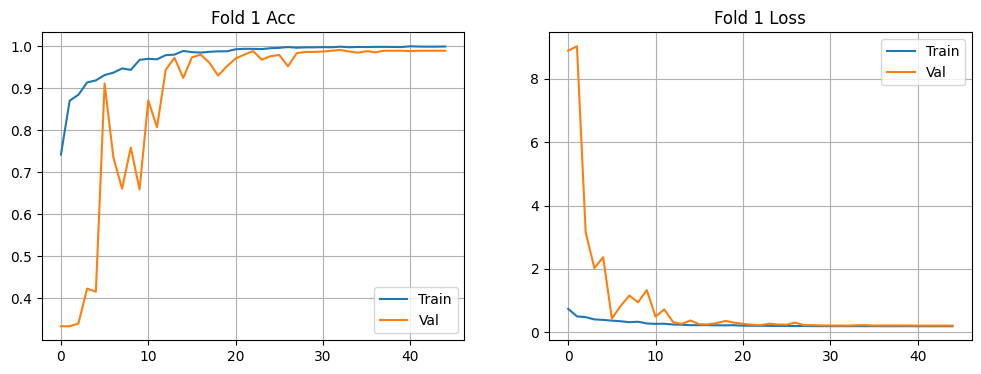

Fold 1 Val Acc: 0.9908 | Test Acc: 0.9834
*** YENİ REKOR! FOLD: 1 (Acc: 0.9908) -> KAYDEDİLİYOR... ***
Dosyalar güncellendi.

======== CUSTOM MODEL FOLD 2 (PLATINUM: STABLE & HIGH) =========
Epoch 1/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 99s 338ms/step - accuracy: 0.6385 - loss: 0.9149 - val_accuracy: 0.3336 - val_loss: 7.4548 - learning_rate: 1.0500e-04
Epoch 2/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.8498 - loss: 0.5460 - val_accuracy: 0.4020 - val_loss: 4.9643 - learning_rate: 1.5750e-04
Epoch 3/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.8963 - loss: 0.4457 - val_accuracy: 0.5213 - val_loss: 2.7022 - learning_rate: 2.3625e-04
Epoch 4/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.9170 - loss: 0.4062 - val_accuracy: 0.4510 - val_loss: 2.6533 - learning_rate: 2.3625e-04
Epoch 5/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.9276 - loss: 0.3750 - val_accuracy: 0.5342 - val_loss: 1.4793 - learning_rate: 2.3625e-04
Epoch 6/50
136/136 ━━━

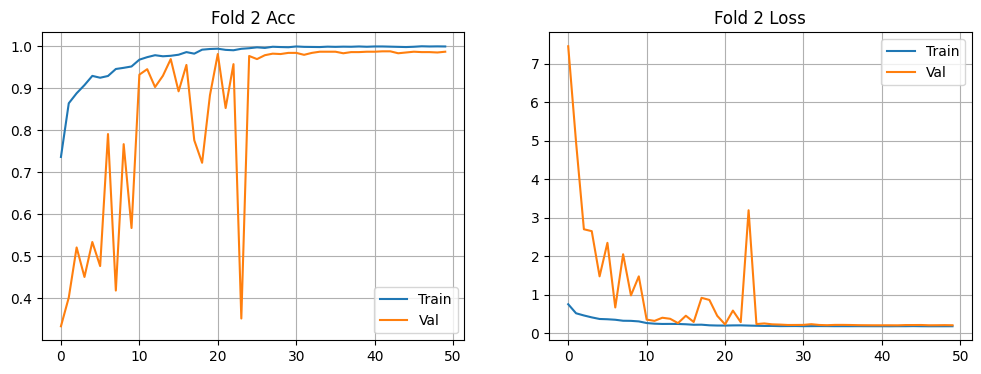

Fold 2 Val Acc: 0.9880 | Test Acc: 0.9867

======== CUSTOM MODEL FOLD 3 (PLATINUM: STABLE & HIGH) =========
Epoch 1/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 100s 340ms/step - accuracy: 0.6369 - loss: 0.9314 - val_accuracy: 0.5055 - val_loss: 1.2344 - learning_rate: 1.0500e-04
Epoch 2/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.8291 - loss: 0.5893 - val_accuracy: 0.4898 - val_loss: 2.9372 - learning_rate: 1.5750e-04
Epoch 3/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.8873 - loss: 0.4774 - val_accuracy: 0.3336 - val_loss: 5.7865 - learning_rate: 2.3625e-04
Epoch 4/50
135/136 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8969 - loss: 0.4445
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001181250045192428.
136/136 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.8969 - loss: 0.4445 - val_accuracy: 0.4048 - val_loss: 2.2159 - learning_rate: 2.3625e-04
Epoch 5/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - accuracy: 0.9242 - loss: 0.3718 - val_accuracy: 0.5684

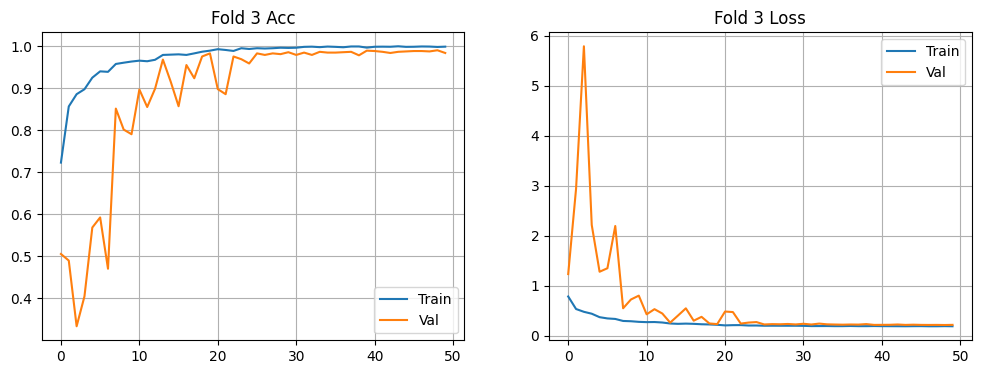

Fold 3 Val Acc: 0.9898 | Test Acc: 0.9734

======== CUSTOM MODEL FOLD 4 (PLATINUM: STABLE & HIGH) =========
Epoch 1/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 102s 351ms/step - accuracy: 0.6380 - loss: 0.9006 - val_accuracy: 0.3410 - val_loss: 4.3425 - learning_rate: 1.0500e-04
Epoch 2/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.8561 - loss: 0.5481 - val_accuracy: 0.3392 - val_loss: 10.8257 - learning_rate: 1.5750e-04
Epoch 3/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.8791 - loss: 0.4763 - val_accuracy: 0.4501 - val_loss: 3.3477 - learning_rate: 2.3625e-04
Epoch 4/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.9115 - loss: 0.4013 - val_accuracy: 0.8466 - val_loss: 0.6326 - learning_rate: 2.3625e-04
Epoch 5/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.9323 - loss: 0.3617 - val_accuracy: 0.5850 - val_loss: 1.7587 - learning_rate: 2.3625e-04
Epoch 6/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.9288 - loss: 0.3612 - val_accuracy: 

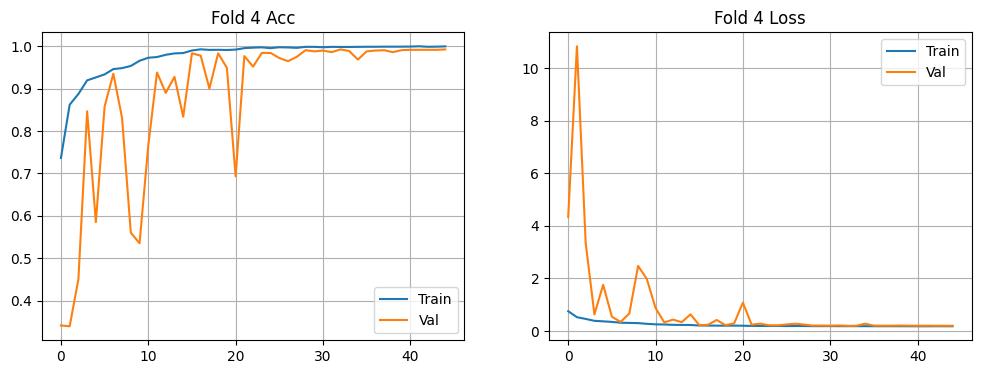

Fold 4 Val Acc: 0.9926 | Test Acc: 0.9900
*** YENİ REKOR! FOLD: 4 (Acc: 0.9926) -> KAYDEDİLİYOR... ***
Dosyalar güncellendi.

======== CUSTOM MODEL FOLD 5 (PLATINUM: STABLE & HIGH) =========
Epoch 1/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 100s 343ms/step - accuracy: 0.6680 - loss: 0.8787 - val_accuracy: 0.4945 - val_loss: 1.4563 - learning_rate: 1.0500e-04
Epoch 2/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.8658 - loss: 0.5230 - val_accuracy: 0.5444 - val_loss: 1.7298 - learning_rate: 1.5750e-04
Epoch 3/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.8840 - loss: 0.4738 - val_accuracy: 0.5323 - val_loss: 2.8598 - learning_rate: 2.3625e-04
Epoch 4/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9059 - loss: 0.4234
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001181250045192428.
136/136 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.9060 - loss: 0.4233 - val_accuracy: 0.3946 - val_loss: 1.8989 - learning_rate: 2.3625e-04
Epoch 5/50
136/136 ━━━━━━━

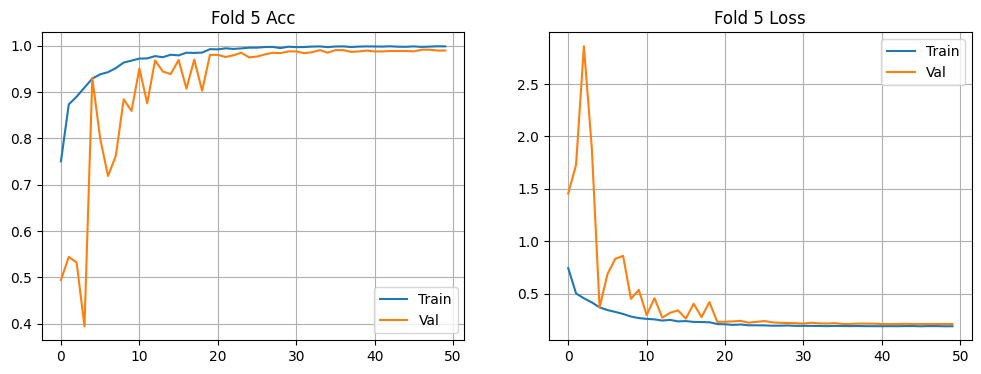

Fold 5 Val Acc: 0.9917 | Test Acc: 0.9834

>>> CUSTOM MODEL (PLATINUM) EĞİTİMİ TAMAMLANDI. Zirve: 4


In [ ]:
# =========================================================
# GOOGLE DRIVE BAĞLANTISI
# =========================================================
# Drive kontrolü yapıyoruz, bağlı değilse bağlıyoruz.
from google.colab import drive
import os
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# =========================================================
# GEREKLİ KÜTÜPHANELER
# =========================================================
# Veri bilimi ve derin öğrenme için gerekli kütüphaneler.
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn araçları (Veri bölme, Metrikler).
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow ve Keras Katmanları (Custom Model İçin).
import tensorflow as tf
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D, Input,
                                     Conv2D, BatchNormalization, Activation, Add,
                                     Multiply, Rescaling, MaxPooling2D, Reshape)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW # Adam'ın daha gelişmiş, weight decay özellikli hali.
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback, ModelCheckpoint
from tensorflow.keras import mixed_precision, regularizers

# =========================================================
# 🚀 MIXED PRECISION (PERFORMANS VE BELLEK OPTİMİZASYONU)
# =========================================================
# float16 kullanarak eğitimi hızlandırıyor ve bellek kullanımını azaltıyoruz.
mixed_precision.set_global_policy("mixed_float16")

# Veri yolları ve kayıt klasörü.
DATASET_PATH = "/content/drive/MyDrive/Projeypy/Brain_Cancer_Clean"
# --- Kayıt Klasörü: PLATINUM (Denge ve Güç) ---
SAVE_DIR = "/content/drive/MyDrive/Projeypy/Sonuclar/Custom_ResAttNet_PLATINUM"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"📂 Veri Seti: {DATASET_PATH}")
print(f"💾 Kayıt Yeri: {SAVE_DIR}")

# Parametreler
IMG_SIZE = 224
VAL_BATCH_SIZE = 64   # Validation sırasında gradient hesabı olmadığı için batch yüksek olabilir.
BATCH_SIZE = 32       # Train batch size (32 genelde en stabil gradienti verir).
EPOCHS = 50
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# VERİ YÜKLEME VE HAZIRLIK
# =========================================================
# Sınıf isimlerini klasörlerden alıyoruz.
class_names = sorted(os.listdir(DATASET_PATH))
class_names = [c for c in class_names
               if os.path.isdir(os.path.join(DATASET_PATH, c))
               and "Sonuclar" not in c
               and not c.startswith('.')]

NUM_CLASSES = len(class_names)

# Dosya yollarını topluyoruz.
image_paths, labels = [], []
for i, cls in enumerate(class_names):
    cls_path = os.path.join(DATASET_PATH, cls)
    if not os.path.exists(cls_path): continue
    for img in os.listdir(cls_path):
        if img.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(cls_path, img))
            labels.append(i)

image_paths = np.array(image_paths)
labels = np.array(labels)

# Train ve Final Test ayrımı (%10 Test).
X_trainval, X_test, y_trainval, y_test = train_test_split(
    image_paths, labels, test_size=0.10, stratify=labels, random_state=SEED
)

print("Train+Val:", len(X_trainval), "| Test:", len(X_test))

# =========================================================
# IMAGE LOADER
# =========================================================
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    # Custom modelin girişinde Rescaling katmanı var, burada float32'ye çevirip bırakıyoruz.
    img = tf.cast(img, tf.float32)
    return img, tf.one_hot(label, NUM_CLASSES)

# =========================================================
# 🛠️ AUGMENTATION (SADECE GEOMETRİK)
# =========================================================
# MRI görüntülerinde renk oynamak risklidir (doku bozulabilir).
# Sadece döndürme ve çevirme yaparak "Dataset Ezberlemeyi" engelliyoruz.
@tf.function
def augment(img, y):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    # Rotasyon: 90 derecelik rastgele dönüşler.
    img = tf.image.rot90(img, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))
    return img, y

# TEST DATASET PIPELINE
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(load_image)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Süre takibi için Callback
class TimeHistory(Callback):
    def on_train_begin(self, logs={}): self.times = []
    def on_epoch_begin(self, batch, logs={}): self.epoch_time_start = time.time()
    def on_epoch_end(self, batch, logs={}): self.times.append(time.time() - self.epoch_time_start)

# =========================================================
# VALIDATION DATASET - DETERMINISTIC AYAR
# =========================================================
# Validation sonuçlarının her seferinde aynı sırada gelmesi için deterministik ayar.
options = tf.data.Options()
options.experimental_deterministic = True

# =========================================================
# 🔥 EKSİK OLAN PARÇA: LR WARMUP FONKSİYONU 🔥
# =========================================================
# Kodda aşağıda çağrılmış ama tanımlanmamıştı. Buraya ekliyorum.
# Amaç: Eğitimin başında LR'yi yavaşça artırıp (ısınma), sonra düşürmek.
def lr_warmup(epoch, lr):
    if epoch < 3:
        return lr * 1.5 # İlk 3 epoch'ta LR'yi artır (Warmup)
    return lr # Sonrasında dokunma (ReduceLROnPlateau halleder)

# =========================================================
# 🔥 CUSTOM MODEL MİMARİSİ (PLATINUM SEVİYE)
# =========================================================
REG_RATE = 1e-5 # L2 Regularization katsayısı (Ağırlıkların sapmasını engeller).

# --- SQUEEZE-AND-EXCITATION (SE) BLOCK ---
# Bu blok, modelin "Hangi kanal (feature map) daha önemli?" sorusuna cevap vermesini sağlar.
# Önemsiz özellikleri bastırır, önemli olanları parlatır (Attention mekanizması).
#
def se_block(input_tensor, ratio=16):
    filters = input_tensor.shape[-1]
    se = GlobalAveragePooling2D()(input_tensor) # Squeeze: Bilgiyi sıkıştır.
    se = Reshape((1, 1, filters))(se)
    # Excitation: İlişkileri öğren.
    se = Dense(filters // ratio, activation='swish', kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)
    return Multiply()([input_tensor, se]) # Scale: Girişi, öğrenilen önem katsayısıyla çarp.

# --- RESIDUAL BLOCK (RESNET MANTIĞI) ---
# Bilginin kaybolmadan derinlere inmesini sağlayan "Skip Connection" yapısı.
#
def residual_block(x, filters, stride=1, dropout_rate=0.0):
    shortcut = x
    # Eğer boyut değişiyorsa, shortcut'ı da (kestirme yol) uydurmamız gerekir.
    if stride > 1 or x.shape[-1] != filters:
        shortcut = Conv2D(filters, (1, 1), strides=stride, padding="same",
                          kernel_initializer="he_normal",
                          kernel_regularizer=regularizers.l2(REG_RATE))(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # Ana yol (Convolution işlemleri)
    x = Conv2D(filters, (3, 3), strides=stride, padding="same",
               kernel_initializer="he_normal",
               kernel_regularizer=regularizers.l2(REG_RATE))(x)
    x = BatchNormalization()(x)
    x = Activation("swish")(x) # ReLU yerine Swish (Google'ın bulduğu daha akıcı aktivasyon).

    if dropout_rate > 0:
        x = Dropout(dropout_rate)(x)

    x = Conv2D(filters, (3, 3), padding="same",
               kernel_initializer="he_normal",
               kernel_regularizer=regularizers.l2(REG_RATE))(x)
    x = BatchNormalization()(x)

    # ÖNEMLİ DOKUNUŞ: Burada SE Block ekliyoruz.
    # Yani her ResNet bloğunun içine bir "Attention" yerleştiriyoruz.
    x = se_block(x)

    # Bilgiyi birleştiriyoruz (Residual Connection).
    x = Add()([x, shortcut])
    x = Activation("swish")(x)
    return x

def build_custom_model():
    input_tensor = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    # Modelin girişinde 0-1 normalizasyonunu yapıyoruz.
    x = Rescaling(1./255)(input_tensor)

    # Başlangıç (Stem) Katmanı
    x = Conv2D(64, (7, 7), strides=2, padding="same",
               kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(REG_RATE))(x)
    x = BatchNormalization()(x)
    x = Activation("swish")(x)
    x = MaxPooling2D((3, 3), strides=2, padding="same")(x)

    # Mimari Blokları (Giderek derinleşen ve genişleyen yapı)
    x = residual_block(x, 64, dropout_rate=0.0)
    x = residual_block(x, 64, dropout_rate=0.0)

    x = residual_block(x, 128, stride=2, dropout_rate=0.0)
    x = residual_block(x, 128, dropout_rate=0.0)

    # Derinlere indikçe Dropout ekliyoruz (Ezberlemeyi önlemek için).
    x = residual_block(x, 256, stride=2, dropout_rate=0.1)
    x = residual_block(x, 256, dropout_rate=0.1)
    x = residual_block(x, 256, dropout_rate=0.1)

    x = residual_block(x, 512, stride=2, dropout_rate=0.2)
    x = residual_block(x, 512, dropout_rate=0.2)

    # Kafa (Sınıflandırma) Kısmı
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="swish", kernel_regularizer=regularizers.l2(REG_RATE))(x)

    # PLATINUM DROPOUT: 0.25 (Çok agresif değil, tam dengeli).
    x = Dropout(0.25)(x)

    output = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = Model(inputs=input_tensor, outputs=output, name="Custom_ResAttNet_Platinum")

    # OPTIMIZER: AdamW
    # Standart Adam yerine "Weight Decay" özelliğine sahip AdamW kullanıyoruz.
    # Bu, modelin ağırlıklarının çok büyümesini engelleyerek daha stabil öğrenmesini sağlar.
    model.compile(
        optimizer=AdamW(learning_rate=7e-5, weight_decay=1e-4, clipnorm=0.5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02), # Label Smoothing (Overconfidence önleyici)
        metrics=["accuracy"]
    )
    return model

# =========================================================
# GRAFİK VE KAYIT FONKSİYONLARI
# =========================================================
def save_best_artifacts(history, y_true, y_pred, y_prob, fold, save_path):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history["accuracy"], label="Train"); plt.plot(history.history["val_accuracy"], label="Val"); plt.title(f"Best Fold ({fold}) Acc"); plt.legend(); plt.grid()
    plt.subplot(1, 2, 2); plt.plot(history.history["loss"], label="Train"); plt.plot(history.history["val_loss"], label="Val"); plt.title(f"Best Fold ({fold}) Loss"); plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_loss_acc.png")); plt.close()

    cm = confusion_matrix(y_true, y_pred)
    #
    plt.figure(figsize=(8,6)); sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Purples"); plt.title(f"Best Fold ({fold}) CM"); plt.savefig(os.path.join(save_path, "best_fold_confusion_matrix.png")); plt.close()

    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    plt.figure(figsize=(7, 6))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--"); plt.title(f"Best Fold ({fold}) ROC"); plt.legend(); plt.grid()
    plt.savefig(os.path.join(save_path, "best_fold_roc_curve.png")); plt.close()

# =========================================================
# 5-FOLD CROSS VALIDATION DÖNGÜSÜ
# =========================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
best_val_acc = 0.0
best_fold_index = 0

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    print(f"\n======== CUSTOM MODEL FOLD {fold} (PLATINUM: STABLE & HIGH) =========")
    X_tr, y_tr = X_trainval[tr_idx], y_trainval[tr_idx]
    X_val, y_val = X_trainval[val_idx], y_trainval[val_idx]

    cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(zip(np.unique(y_tr), cw))

    train_ds = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
                .shuffle(4096).map(load_image).map(augment).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
    val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .with_options(options)
    .map(load_image)
    .batch(VAL_BATCH_SIZE)
    .prefetch(1)
)

    model = build_custom_model()
    time_callback = TimeHistory()

    # CHECKPOINT: Eğitim sırasında anlık en iyi modeli kaydeder.
    checkpoint = ModelCheckpoint(
        os.path.join(SAVE_DIR, f"temp_best_fold_{fold}.keras"),
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=0
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights,
        callbacks=[
            # Burada eklediğimiz lr_warmup fonksiyonunu kullanıyor.
            tf.keras.callbacks.LearningRateScheduler(lr_warmup),
            EarlyStopping(patience=12, restore_best_weights=True),
            ReduceLROnPlateau(patience=3, factor=0.5, min_lr=1e-7, verbose=1),
            checkpoint,
            time_callback
        ],
        verbose=1
    )

    # --- 1. GRAFİKLERİ EKLE (TAKİP İÇİN) ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history["accuracy"], label="Train"); plt.plot(history.history["val_accuracy"], label="Val"); plt.title(f"Fold {fold} Acc"); plt.legend(); plt.grid()
    plt.subplot(1, 2, 2); plt.plot(history.history["loss"], label="Train"); plt.plot(history.history["val_loss"], label="Val"); plt.title(f"Fold {fold} Loss"); plt.legend(); plt.grid()
    plt.show()

    # --- 2. DEĞERLENDİRME ---
    # En iyi anın ağırlıklarını yüklüyoruz.
    model.load_weights(os.path.join(SAVE_DIR, f"temp_best_fold_{fold}.keras"))

    val_prob = model.predict(val_ds, verbose=0)
    val_pred = np.argmax(val_prob, axis=1)
    val_true = np.concatenate([y for x, y in val_ds], axis=0)
    val_true = np.argmax(val_true, axis=1)

    test_prob = model.predict(test_ds, verbose=0)
    test_pred = np.argmax(test_prob, axis=1)

    val_acc = accuracy_score(val_true, val_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print(f"Fold {fold} Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")

    # --- 3. REKOR VE KAYIT ---
    if val_acc > best_val_acc:
        print(f"*** YENİ REKOR! FOLD: {fold} (Acc: {val_acc:.4f}) -> KAYDEDİLİYOR... ***")
        best_val_acc = val_acc
        best_fold_index = fold

        model.save(os.path.join(SAVE_DIR, "best_custom_resatt_platinum.h5"))
        save_best_artifacts(history, y_test, test_pred, test_prob, fold, SAVE_DIR)

        avg_epoch_time = np.mean(time_callback.times)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, test_pred, average='weighted')

        df = pd.DataFrame([{
            "Model": "Custom_ResAttNet_Platinum", "Best_Fold": fold,
            "Val_Accuracy": val_acc, "Test_Accuracy": test_acc,
            "Precision": precision, "Recall": recall, "F1_Score": f1,
            "Avg_Epoch_Time_Sec": avg_epoch_time
        }])
        df.to_csv(os.path.join(SAVE_DIR, "best_custom_metrics.csv"), index=False)
        print("Dosyalar güncellendi.")

print(f"\n>>> CUSTOM MODEL (PLATINUM) EĞİTİMİ TAMAMLANDI. Zirve: {best_fold_index}")

# **TEST EVULETE HEPSİ ICIN YAPILAN KISIM**

In [ ]:
# =========================================================
# FİNAL DÜZELTME: İSİM EŞLEŞTİRME HATASI GİDERİLDİ
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, cohen_kappa_score, precision_recall_fscore_support, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from google.colab import drive

# 1. AYARLAR
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/Projeypy/Sonuclar"
FINAL_DIR = "/content/drive/MyDrive/Projeypy/Sonuclar/FINAL_PROJE_RAPORU"
DATASET_PATH = "/content/drive/MyDrive/Projeypy/Brain_Cancer_Clean"
os.makedirs(FINAL_DIR, exist_ok=True)
IMG_SIZE = 224
SEED = 42

# ---------------------------------------------------------
# ADIM 1: EĞİTİM GEÇMİŞİNİ TOPLA
# ---------------------------------------------------------
print("📊 ADIM 1: Eğitim kayıtları okunuyor...")
training_csv_paths = [
    os.path.join(BASE_DIR, "Xception_Sonuclar/best_model_metrics.csv"),
    os.path.join(BASE_DIR, "MobileNetV2_Sonuclar/best_model_metrics.csv"),
    os.path.join(BASE_DIR, "InceptionV3_Sonuclar/best_model_metrics.csv"),
    os.path.join(BASE_DIR, "DenseNet121_Sonuclar/best_model_metrics.csv"),
    os.path.join(BASE_DIR, "Hybrid_Inception_Xception_FineTuned/best_hybrid_metrics.csv"),
    os.path.join(BASE_DIR, "Hybrid_DenseNet_FineTuned_EfficientNet_Frozen/best_hybrid_metrics.csv"),
    os.path.join(BASE_DIR, "Hybrid_Xception_DenseNet121_FineTuned/best_hybrid_metrics.csv"),
    os.path.join(BASE_DIR, "Hybrid_DenseNet121_InceptionV3_FineTuned/best_hybrid_metrics.csv"),
    os.path.join(BASE_DIR, "Hybrid_Triple_Dense_Xcp_Inc_FineTuned/best_hybrid_metrics.csv"),
    os.path.join(BASE_DIR, "Custom_ResAttNet_PLATINUM/best_custom_metrics.csv")
]

df_list = []
for path in training_csv_paths:
    if os.path.exists(path):
        try:
            temp_df = pd.read_csv(path)
            cols = ['Model', 'Avg_Epoch_Time_Sec', 'Val_Accuracy', 'Best_Fold']
            temp_df = temp_df[[c for c in cols if c in temp_df.columns]]
            temp_df['Match_Key'] = temp_df['Model'].astype(str).str.lower().str.replace(" ", "").str.replace("_", "").str.replace("(", "").str.replace(")", "").str.replace("3'lü", "")
            df_list.append(temp_df)
        except: pass
df_train = pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()

# ---------------------------------------------------------
# ADIM 2: TEST VERİSİNİ HAZIRLA
# ---------------------------------------------------------
print("\n📥 ADIM 2: Test verisi hazırlanıyor...")
class_names = sorted([c for c in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, c)) and "Sonuclar" not in c and not c.startswith('.')])
NUM_CLASSES = len(class_names)
image_paths, labels = [], []
for i, cls in enumerate(class_names):
    cls_path = os.path.join(DATASET_PATH, cls)
    if not os.path.exists(cls_path): continue
    for img in os.listdir(cls_path):
        if img.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(cls_path, img))
            labels.append(i)
image_paths = np.array(image_paths); labels = np.array(labels)
_, X_test, _, y_test = train_test_split(image_paths, labels, test_size=0.10, stratify=labels, random_state=SEED)

def load_raw(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    return img, label

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).map(load_raw).batch(64)
X_test_np = np.concatenate([x.numpy() for x, _ in test_ds])
y_test_np = np.concatenate([y.numpy() for _, y in test_ds])

# ---------------------------------------------------------
# ADIM 3: MODELLERİ TEST ET (DÜZELTİLMİŞ MANTIK)
# ---------------------------------------------------------
print("\n🚀 ADIM 3: Modeller Test Ediliyor...")

model_paths = [
    ("/content/drive/MyDrive/Projeypy/Sonuclar/Hybrid_Inception_Xception_FineTuned/best_hybrid_inc_xcp_finetuned.h5", "Hybrid (Inc+Xcp)"),
    ("/content/drive/MyDrive/Projeypy/Sonuclar/Hybrid_Triple_Dense_Xcp_Inc_FineTuned/best_triple_hybrid_model.h5", "Triple_Hybrid"),
    ("/content/drive/MyDrive/Projeypy/Sonuclar/Hybrid_Xception_DenseNet121_FineTuned/best_hybrid_xcp_dense_finetuned.h5","Hybrid (Xcp+Dense)"),
    ("/content/drive/MyDrive/Projeypy/Sonuclar/Hybrid_DenseNet_FineTuned_EfficientNet_Frozen/best_hybrid_dense_eff.h5","Hybrid (Dense+Eff)"),
    ("/content/drive/MyDrive/Projeypy/Sonuclar/Hybrid_DenseNet121_InceptionV3_FineTuned/best_hybrid_dense_inception_finetuned.h5","Hybrid (Dense+Inc)"),
    ("/content/drive/MyDrive/Projeypy/Sonuclar/Custom_ResAttNet_PLATINUM/best_custom_resatt_platinum.h5", "Custom Platinum"),
    ("/content/drive/MyDrive/Projeypy/Sonuclar/Xception_Sonuclar/best_xception_model.h5","Xception"),
    ("/content/drive/MyDrive/Projeypy/Sonuclar/MobileNetV2_Sonuclar/best_mobilenetv2_model.h5","MobileNetV2"),
    ("/content/drive/MyDrive/Projeypy/Sonuclar/InceptionV3_Sonuclar/best_inceptionv3_model.h5","InceptionV3"),
    ("/content/drive/MyDrive/Projeypy/Sonuclar/DenseNet121_Sonuclar/best_densenet121_model.h5","DenseNet121"),
]

fresh_results = []

for path, name in model_paths:
    if not os.path.exists(path): continue
    print(f"   ⚙️  {name} işleniyor...", end="")
    try:
        model = tf.keras.models.load_model(path)
        name_lower = name.lower()

        # --- KESİN ÇÖZÜM: İSİM KONTROLÜ ---

        # 1. KURAL: Adında HEM "inc" HEM DE "xcp" geçen model -> (-1, 1) İster
        # Ayrıca "Hybrid" olmayan tekli Xception/MobileNet/Inception da -> (-1, 1) İster
        if (("inc" in name_lower and "xcp" in name_lower)) or \
           (("hybrid" not in name_lower) and ("xception" in name_lower or "mobilenet" in name_lower or "inception" in name_lower)):
             X_input = (X_test_np / 127.5) - 1.0
             print(" [Format: -1 ile 1]", end="")

        # 2. KURAL: Tekli DenseNet -> (0, 1) İster
        elif "densenet" in name_lower and "hybrid" not in name_lower:
             X_input = X_test_np / 255.0
             print(" [Format: 0 ile 1]", end="")

        # 3. KURAL: Geriye kalanlar (Triple Hybrid, Custom, Diğer Hybridler) -> Ham 0-255 İster
        else:
             X_input = X_test_np
             print(" [Format: Ham 0-255]", end="")

        X_input = tf.cast(X_input, tf.float32)

        # TAHMİN
        y_prob = model.predict(X_input, verbose=0)
        y_prob = np.nan_to_num(y_prob, nan=0.0)
        y_pred = np.argmax(y_prob, axis=1)

        # METRİKLER
        acc = accuracy_score(y_test_np, y_pred)
        kappa = cohen_kappa_score(y_test_np, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test_np, y_pred, average='weighted')

        print(f" -> ✅ (Kappa: {kappa:.4f})")

        # --- CONFUSION MATRIX ---
        cm = confusion_matrix(y_test_np, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        plt.title(f"{name} CM\nKappa: {kappa:.4f}")
        plt.tight_layout()
        plt.savefig(os.path.join(FINAL_DIR, f"{name}_CM.png"))
        plt.close()

        # --- ROC CURVE ---
        y_true_bin = label_binarize(y_test_np, classes=range(NUM_CLASSES))
        plt.figure(figsize=(6, 5))
        for i in range(NUM_CLASSES):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC={roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.title(f"{name} ROC")
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.savefig(os.path.join(FINAL_DIR, f"{name}_ROC.png"))
        plt.close()

        fresh_results.append({
            "Model": name,
            "Kappa": kappa,
            "Test_Accuracy": acc,
            "F1_Score": f1,
            "Precision": precision,
            "Recall": recall,
            "Match_Key": name.lower().replace(" ", "").replace("_", "").replace("(", "").replace(")", "").replace("3'lü", "")
        })
        tf.keras.backend.clear_session()
        del model
    except Exception as e: print(f" -> ❌ HATA: {e}")

df_fresh = pd.DataFrame(fresh_results)

# ---------------------------------------------------------
# ADIM 4: BİRLEŞTİR VE KAYDET
# ---------------------------------------------------------
print("\n🔗 ADIM 4: Excel oluşturuluyor...")
if not df_train.empty and not df_fresh.empty:
    df_train.loc[df_train['Match_Key'].str.contains('custom'), 'Match_Key'] = 'custom_fix'
    df_fresh.loc[df_fresh['Match_Key'].str.contains('custom'), 'Match_Key'] = 'custom_fix'

    master_df = pd.merge(df_fresh, df_train, on='Match_Key', how='left', suffixes=('', '_old'))
    cols = ['Model', 'Kappa', 'Test_Accuracy', 'F1_Score', 'Precision', 'Recall', 'Val_Accuracy', 'Avg_Epoch_Time_Sec', 'Best_Fold']
    master_df = master_df[[c for c in cols if c in master_df.columns]].sort_values(by="Kappa", ascending=False)

    save_path = os.path.join(FINAL_DIR, "FINAL_MASTER_TABLO_FULL.xlsx")
    master_df.to_excel(save_path, index=False)

    print("\n" + "="*80)
    print(f"🎉 İŞLEM TAMAM! (Hata Giderildi)")
    print(f"📂 Excel: {save_path}")
    print("="*80)
    print(master_df[['Model', 'Kappa', 'Test_Accuracy']].head())
else:
    print("❌ Hata oluştu.")

📊 ADIM 1: Eğitim kayıtları okunuyor...

📥 ADIM 2: Test verisi hazırlanıyor...

🚀 ADIM 3: Modeller Test Ediliyor...
   ⚙️  Hybrid (Inc+Xcp) işleniyor...

 [Format: -1 ile 1] -> ✅ (Kappa: 0.9925)
   ⚙️  Triple_Hybrid işleniyor...

 [Format: Ham 0-255] -> ✅ (Kappa: 0.9950)
   ⚙️  Hybrid (Xcp+Dense) işleniyor...

 [Format: Ham 0-255] -> ✅ (Kappa: 0.9900)
   ⚙️  Hybrid (Dense+Eff) işleniyor...

 [Format: Ham 0-255] -> ✅ (Kappa: 0.9875)
   ⚙️  Hybrid (Dense+Inc) işleniyor...

...

 [Format: Ham 0-255] -> ✅ (Kappa: 0.9850)
   ⚙️  Xception işleniyor...

 [Format: -1 ile 1] -> ✅ (Kappa: 0.9925)
   ⚙️  MobileNetV2 işleniyor...

 [Format: -1 ile 1] -> ✅ (Kappa: 0.9850)
   ⚙️  InceptionV3 işleniyor...

 [Format: -1 ile 1] -> ✅ (Kappa: 0.9826)
   ⚙️  DenseNet121 işleniyor...

 [Format: 0 ile 1] -> ✅ (Kappa: 0.9826)

🔗 ADIM 4: Excel oluşturuluyor...

🎉 İŞLEM TAMAM! (Hata Giderildi)
📂 Excel: /content/drive/MyDrive/Projeypy/Sonuclar/FINAL_PROJE_RAPORU/FINAL_MASTER_TABLO_FULL.xlsx
                Model     Kappa  Test_Accuracy
1       Triple_Hybrid  0.995017       0.996678
0    Hybrid (Inc+Xcp)  0.992525       0.995017
6            Xception  0.992525       0.995017
2  Hybrid (Xcp+Dense)  0.990033       0.993355
3  Hybrid (Dense+Eff)  0.987541       0.991694


# Gormedığı fotograflar uzerınden **deneme**

TEKLİ DENEME

⏳ Model yükleniyor, lütfen bekleyin...
✅ Model başarıyla yüklendi!

⬇️ Lütfen masaüstünden test etmek istediğin fotoğrafı seç: ⬇️


Saving brain_glioma_0001.jpg to brain_glioma_0001.jpg

📸 İşleniyor: brain_glioma_0001.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 33s 33s/step


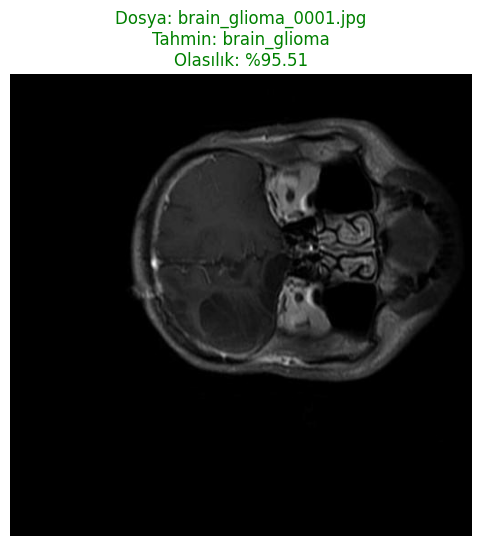


🔍 brain_glioma_0001.jpg için Detaylı Sonuçlar:
--------------------------
Tahmin Edilen: brain_glioma
Güven Oranı: %95.51

Tüm Sınıf Olasılıkları:
brain_glioma: %95.51
brain_menin: %2.31
brain_tumor: %2.18
--------------------------



In [15]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files # Dosya yükleme aracı
import io
from PIL import Image

# ==========================================
# 1. AYARLAR
# ==========================================
# Kaydettiğin modelin tam yolu (Drive bağlı olmalı)
MODEL_PATH = "/content/drive/MyDrive/Projeypy/Sonuclar/Hybrid_Triple_Dense_Xcp_Inc_FineTuned/best_triple_hybrid_model.h5"

# SENİN BELİRTTİĞİN SINIF İSİMLERİ
CLASS_NAMES = ['brain_glioma', 'brain_menin', 'brain_tumor']

IMG_SIZE = 224

# ==========================================
# 2. MODELİ YÜKLEME
# ==========================================
print("⏳ Model yükleniyor, lütfen bekleyin...")
# compile=False: Sadece tahmin yapacağız, hata fonksiyonuna ihtiyacımız yok.
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("✅ Model başarıyla yüklendi!")

# ==========================================
# 3. YÜKLENEN RESMİ TAHMİN ETME FONKSİYONU
# ==========================================
def predict_uploaded_image(filename, content):
    # Bilgisayardan gelen veriyi (byte) resme çeviriyoruz
    img = Image.open(io.BytesIO(content)).convert('RGB')

    # Modelin istediği boyuta (224x224) getiriyoruz
    img_resized = img.resize((IMG_SIZE, IMG_SIZE))

    # Diziye çevir
    img_array = image.img_to_array(img_resized)

    # --- KRİTİK NOKTA ---
    # Normalizasyon (/255) YAPMIYORUZ. Modelin girişinde Rescaling var.

    # Batch boyutu ekle: (1, 224, 224, 3)
    img_batch = np.expand_dims(img_array, axis=0)

    # Tahmin yap
    predictions = model.predict(img_batch)

    predicted_class_idx = np.argmax(predictions)
    predicted_label = CLASS_NAMES[predicted_class_idx]
    confidence = np.max(predictions) * 100

    # --- SONUCU GÖRSELLEŞTİR ---
    plt.figure(figsize=(6, 6))
    plt.imshow(img) # Orijinal resmi göster
    plt.axis("off")
    plt.title(f"Dosya: {filename}\nTahmin: {predicted_label}\nOlasılık: %{confidence:.2f}",
              color="green" if confidence > 80 else "red")
    plt.show()

    print(f"\n🔍 {filename} için Detaylı Sonuçlar:")
    print(f"--------------------------")
    print(f"Tahmin Edilen: {predicted_label}")
    print(f"Güven Oranı: %{confidence:.2f}")

    print("\nTüm Sınıf Olasılıkları:")
    for i, prob in enumerate(predictions[0]):
        print(f"{CLASS_NAMES[i]}: %{prob*100:.2f}")
    print("--------------------------\n")

# ==========================================
# 4. DOSYA SEÇME BUTONU (BURASI ÇALIŞACAK)
# ==========================================
print("\n⬇️ Lütfen masaüstünden test etmek istediğin fotoğrafı seç: ⬇️")

# Bu satır çalışınca ekranda "Dosyaları Seç" butonu çıkacak
uploaded = files.upload()

# Seçtiğin her dosya için tahmin fonksiyonunu çağır
if not uploaded:
    print("Hiçbir dosya seçilmedi.")
else:
    for filename, content in uploaded.items():
        print(f"\n📸 İşleniyor: {filename}")
        predict_uploaded_image(filename, content)

COKLU DENEME

⏳ Model yükleniyor, lütfen bekleyin...
✅ Model başarıyla yüklendi!

⬇️ LÜTFEN MASAÜSTÜNDEN FOTOĞRAFLARI SEÇİN ⬇️
👉 İpucu: Birden fazla dosya seçmek için CTRL veya SHIFT tuşuna basılı tutun.



Saving Braın_glioma_TEST_INT.jpg to Braın_glioma_TEST_INT.jpg
Saving Braın_menin_TEST_INT.jpg to Braın_menin_TEST_INT.jpg
Saving Braın_Tumor_TEST_INT.jpg to Braın_Tumor_TEST_INT.jpg

✅ Toplam 3 dosya yüklendi. Tahminler yapılıyor...



--> Braın_glioma_TEST_INT.jpg işlendi: brain_glioma (%94.1)
--> Braın_menin_TEST_INT.jpg işlendi: brain_menin (%81.8)
--> Braın_Tumor_TEST_INT.jpg işlendi: brain_tumor (%92.1)


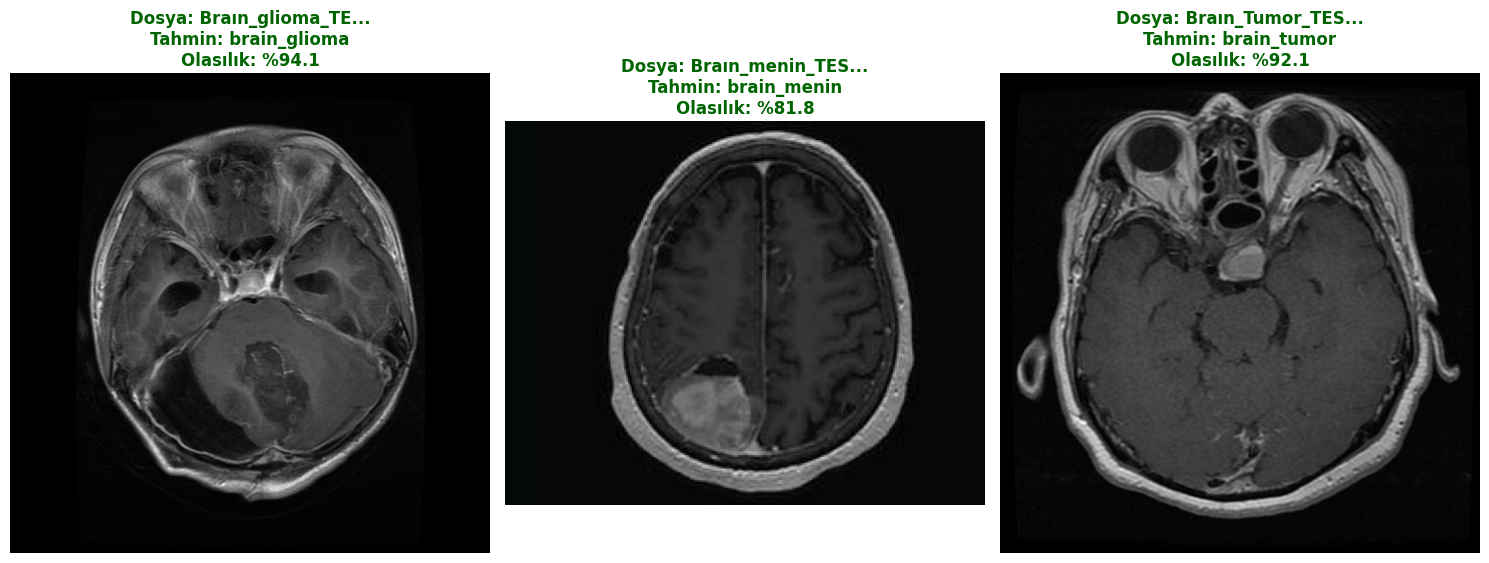

In [5]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files
import io
from PIL import Image
import math

# ==========================================
# 1. AYARLAR VE MODEL YÜKLEME
# ==========================================
# Kaydettiğin modelin tam yolu
MODEL_PATH = "/content/drive/MyDrive/Projeypy/Sonuclar/Hybrid_Triple_Dense_Xcp_Inc_FineTuned/best_triple_hybrid_model.h5"

# SENİN BELİRTTİĞİN SINIF İSİMLERİ (ALFABETİK SIRA)
CLASS_NAMES = ['brain_glioma', 'brain_menin', 'brain_tumor']

IMG_SIZE = 224

print("⏳ Model yükleniyor, lütfen bekleyin...")
# compile=False: Sadece tahmin yapacağız.
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("✅ Model başarıyla yüklendi!")

# ==========================================
# 2. GÖRÜNTÜ İŞLEME VE TAHMİN YARDIMCISI
# ==========================================
def process_and_predict(content):
    # Byte verisini resme çevir
    img_pil = Image.open(io.BytesIO(content)).convert('RGB')
    # Model için boyutlandır
    img_resized = img_pil.resize((IMG_SIZE, IMG_SIZE))
    # Diziye çevir
    img_array = image.img_to_array(img_resized)
    # Batch boyutu ekle (1, 224, 224, 3)
    img_batch = np.expand_dims(img_array, axis=0)

    # Tahmin (Normalizasyon yok, model içinde hallediyor)
    predictions = model.predict(img_batch, verbose=0)

    predicted_idx = np.argmax(predictions)
    predicted_label = CLASS_NAMES[predicted_idx]
    confidence = np.max(predictions) * 100

    return img_pil, predicted_label, confidence

# ==========================================
# 3. ÇOKLU DOSYA YÜKLEME VE GÖSTERME
# ==========================================
print("\n" + "="*50)
print("⬇️ LÜTFEN MASAÜSTÜNDEN FOTOĞRAFLARI SEÇİN ⬇️")
print("👉 İpucu: Birden fazla dosya seçmek için CTRL veya SHIFT tuşuna basılı tutun.")
print("="*50 + "\n")

# BUTON BURADA ÇIKACAK
uploaded = files.upload()

num_files = len(uploaded)

if num_files == 0:
    print("❌ Hiçbir dosya seçilmedi.")
else:
    print(f"\n✅ Toplam {num_files} dosya yüklendi. Tahminler yapılıyor...\n")

    # --- GRAFİK YERLEŞİMİ AYARLA (Yan Yana Göstermek İçin) ---
    # En fazla 3 sütun olsun, satır sayısı ona göre artsın.
    cols = min(num_files, 3)
    rows = math.ceil(num_files / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*5.5))
    # Eğer tek resim varsa veya birden fazla satır/sütun varsa eksenleri düzleştir
    if num_files > 1:
        axes = axes.flatten()
    else:
        axes = [axes]

    # Yüklenen her dosyayı döngüye al
    for i, (filename, content) in enumerate(uploaded.items()):
        # Tahmin fonksiyonunu çağır
        img_org, label, conf = process_and_predict(content)

        # Renk belirle (Güven yüksekse yeşil, düşükse kırmızı)
        color = "darkgreen" if conf > 80 else "darkred"
        title_text = f"Dosya: {filename[:15]}...\nTahmin: {label}\nOlasılık: %{conf:.1f}"

        # Grafiğe çiz
        axes[i].imshow(img_org)
        axes[i].axis('off')
        axes[i].set_title(title_text, color=color, fontsize=12, fontweight='bold')
        print(f"--> {filename} işlendi: {label} (%{conf:.1f})")

    # Eğer boş kalan grafik alanı varsa onları gizle
    for j in range(num_files, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()